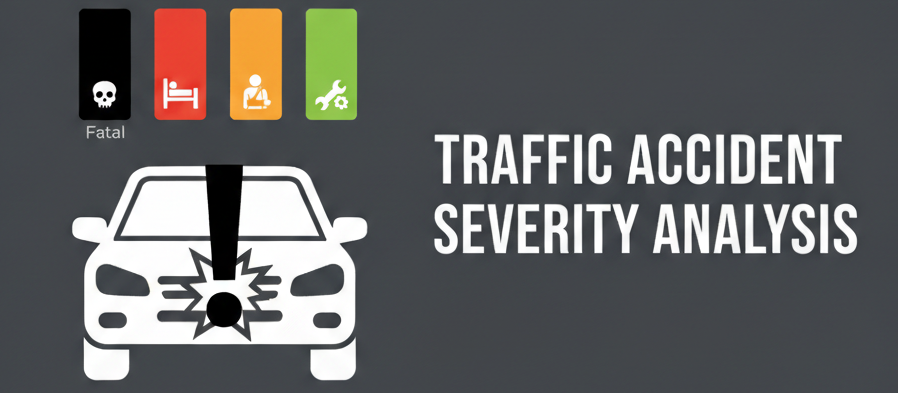

# Analyzing Traffic Accident Severity in the U.S.
#### (Using US Accidents dataset 2016-2023)

## 1. Overview  
  
This project analyzes U.S. traffic accident data to identify factors influencing accident severity. The study focuses on the correlation between road condition, time, and infrastructure to mitigate large-scale traffic disruptions.

## 2. Business Understanding - Segmented Strategies for Regional Traffic Impacts  

The goal of this project is to find the main factors that affect **incident severity (Level 1–4)** and cause traffic delays. By looking at time, road features, and weather data, we aim to create a better traffic management plan. Instead of using the same rules everywhere, this project helps set up a system that fits the specific needs and traffic patterns of different regions.

**Key Deliverables**
* **Risk Identification:** Finding specific times and places where traffic incidents are most likely to happen.
* **Infrastructure Assessment:** Checking how different road types and weather conditions lead to different levels of traffic disruption.
* **Operational Optimization:** Suggesting different response plans—such as early warnings for big delays and fast cleanup for smaller ones—to make traffic management more efficient.
* **Economic Impact Reduction:** Reducing the costs caused by traffic jams by helping officials put resources in the right places based on regional data.

**Methodology**
* **Phase 1 (Sample-based Exploration)**
    * Performing a basic analysis to see the general patterns of **incident severity** and how weather and time affect traffic on a national scale.
* **Phase 2 (Full-scale Modeling)**
    * Using the full dataset to study how weather triggers and road types change the **incident frequency** and impact in different states and cities.
    * Creating final recommendations based on the different traffic problems found in each specific region.

## [Phase 1] Exploratory Analysis (Sample-base)  

## 3. Data Understanding (Initial Inspection & Sampling)

This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. 

### 3.1 Data Loading & Schema Verification Strategy  
The dataset is examined to verify integrity and identify patterns across severity levels. Statistical profiling is used to find factors that distinguish minor incidents from major accidents.

In [14]:
import pandas as pd
import numpy as np
import sys

In [15]:
# File path
file_path = "Data/US_Accidents_March23.csv"

In [16]:
# Preliminary Analysis (Dataset is over 3GB)
preview_size = 10000
df_check = pd.read_csv(file_path, nrows=preview_size)

print(f"== Schema Discovery (first {preview_size} rows) ==")
for col in df_check.columns:
    unique_count = df_check[col].nunique()
    total_count = len(df_check[col])
    dtype = df_check[col].dtype

    # If unique values are less than 5% of total rows, it's a candidate for 'category'
    is_candidate = "Candidate for Category" if (unique_count / total_count) < 0.05 else ""
    print(f"Column: {col:<25} | Dtype: {str(dtype):<15} | Unique: {unique_count:<6} {is_candidate}")

== Schema Discovery (first 10000 rows) ==
Column: ID                        | Dtype: object          | Unique: 10000  
Column: Source                    | Dtype: object          | Unique: 2      Candidate for Category
Column: Severity                  | Dtype: int64           | Unique: 4      Candidate for Category
Column: Start_Time                | Dtype: object          | Unique: 9907   
Column: End_Time                  | Dtype: object          | Unique: 9921   
Column: Start_Lat                 | Dtype: float64         | Unique: 6372   
Column: Start_Lng                 | Dtype: float64         | Unique: 6277   
Column: End_Lat                   | Dtype: float64         | Unique: 0      Candidate for Category
Column: End_Lng                   | Dtype: float64         | Unique: 0      Candidate for Category
Column: Distance(mi)              | Dtype: float64         | Unique: 45     Candidate for Category
Column: Description               | Dtype: object          | Unique: 8528   
C

In [17]:
# Memory-Safe Chunked Sampling
'''Chunks allows to monitor the process and handle potential 'Mixed Type' warnings'''
chunk_size = 100000
sample_list = []
total_rows_processed = 0
sample_rate = 0.10

print("=== Starting Chunk-based Sampling ===")

try: 
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        sampled_chunk = chunk.sample(frac=sample_rate, random_state=42)
        sample_list.append(sampled_chunk)
        total_rows_processed += len(chunk)

        if total_rows_processed % 1000000 == 0:
            print(f"Processed {total_rows_processed} rows...")

        df = pd.concat(sample_list, axis=0)
        print(f"\nSampling Complete. Total Rows Sampled: {len(df)}")

except Exception as e:
    print(f"Error during processing: {e}")

=== Starting Chunk-based Sampling ===

Sampling Complete. Total Rows Sampled: 10000

Sampling Complete. Total Rows Sampled: 20000

Sampling Complete. Total Rows Sampled: 30000

Sampling Complete. Total Rows Sampled: 40000

Sampling Complete. Total Rows Sampled: 50000

Sampling Complete. Total Rows Sampled: 60000

Sampling Complete. Total Rows Sampled: 70000

Sampling Complete. Total Rows Sampled: 80000

Sampling Complete. Total Rows Sampled: 90000
Processed 1000000 rows...

Sampling Complete. Total Rows Sampled: 100000

Sampling Complete. Total Rows Sampled: 110000

Sampling Complete. Total Rows Sampled: 120000

Sampling Complete. Total Rows Sampled: 130000

Sampling Complete. Total Rows Sampled: 140000

Sampling Complete. Total Rows Sampled: 150000

Sampling Complete. Total Rows Sampled: 160000

Sampling Complete. Total Rows Sampled: 170000

Sampling Complete. Total Rows Sampled: 180000

Sampling Complete. Total Rows Sampled: 190000
Processed 2000000 rows...

Sampling Complete. Total 

In [18]:
# Summary of Column Health
'''Identify which columns are relaible and which need significant cleaning.'''
health_report = pd.DataFrame({'Dtype': df.dtypes,
                              'Null_Count': df.isnull().sum(),
                              'Null_Percentage': (df.isnull().sum() / len(df)) * 100,
                              'Unique_Values': df.nunique()})

# Sort
print("=== Column Health Report (Top 20) ===")
print(health_report.sort_values(by='Null_Percentage', ascending=False).head(20))

# Overall completeness
total_cells = np.prod(df.shape)
total_nulls = df.isnull().sum().sum()
print(f"\n=== Overall Data Quality Summary ===")
print(f"Total Rows: {len(df)}")
print(f"Total Missing Values: {total_nulls} ({ (total_nulls/total_cells)*100:.2f}% of total data)")
print(f"Columns with > 50% Missing: {len(health_report[health_report['Null_Percentage'] > 50])}")

=== Column Health Report (Top 20) ===
                         Dtype  Null_Count  Null_Percentage  Unique_Values
End_Lat                float64      340298        44.032198         316661
End_Lng                float64      340298        44.032198         318839
Precipitation(in)      float64      221061        28.603758            187
Wind_Chill(F)          float64      200187        25.902808            835
Wind_Speed(mph)        float64       57526         7.443465            112
Visibility(mi)         float64       17950         2.322605             61
Wind_Direction          object       17819         2.305655             24
Humidity(%)            float64       17588         2.275765            100
Weather_Condition       object       17550         2.270848            117
Temperature(F)         float64       16559         2.142620            752
Pressure(in)           float64       14314         1.852132           1022
Weather_Timestamp       object       12212         1.580148   

### 3.2 Numerical & Target Distribution

In [20]:
# Numerical Feature Distribution & Outliers
'''Weather and physical impact metrics.'''
print("=== Detailed Statistics for Key Numerical Columns ===")
key_num_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Checking percentiles
stats = df[key_num_cols].describe(percentiles=[.01, .25, .5, .75, .99])
print(stats)

=== Detailed Statistics for Key Numerical Columns ===
            Severity   Distance(mi)  Temperature(F)  Visibility(mi)  \
count  772839.000000  772839.000000   756280.000000   754889.000000   
mean        2.212731       0.560512       61.683076        9.093305   
std         0.488106       1.737856       18.985987        2.690374   
min         1.000000       0.000000      -89.000000        0.000000   
1%          2.000000       0.000000       12.900000        0.500000   
25%         2.000000       0.000000       49.000000       10.000000   
50%         2.000000       0.030000       64.000000       10.000000   
75%         2.000000       0.465000       76.000000       10.000000   
99%         4.000000       6.910000       96.000000       10.000000   
max         4.000000     149.690000      196.000000      100.000000   

       Wind_Speed(mph)  Precipitation(in)  
count    715313.000000      551778.000000  
mean          7.685036           0.008221  
std           5.576693          

In [21]:
# Target Variable (Severity)
print("=== Severity Distribution (Target Variable) ===")
severity_counts = df['Severity'].value_counts().sort_index()
severity_pct = df['Severity'].value_counts(normalize=True).sort_index() *100

severity_report = pd.DataFrame({'Count': severity_counts,
                                'Percentage (%)': severity_pct})
print(severity_report)

=== Severity Distribution (Target Variable) ===
           Count  Percentage (%)
Severity                        
1           6757        0.874309
2         615508       79.642461
3         129984       16.819027
4          20590        2.664203


In [22]:
# Categorical Dominance (Top values)
print("=== Top 5 States and Weather Conditions ===")
print("Top States:\n", df['State'].value_counts().head(5))
print("\nTop Weather Conditions:\n", df['Weather_Condition'].value_counts().head(5))

=== Top 5 States and Weather Conditions ===
Top States:
 State
CA    174744
FL     87871
TX     58147
SC     38409
NY     34747
Name: count, dtype: int64

Top Weather Conditions:
 Weather_Condition
Fair             256560
Mostly Cloudy    101261
Cloudy            81702
Clear             81006
Partly Cloudy     69687
Name: count, dtype: int64


### 3.3 Severity-Segmented Analysis

In [24]:
# Comparison of Numerical Features by Severity
print("=== Average Values by Severity Level ===")
'''Logical influences'''
comparison_cols = ['Distance(mi)', 'Temperature(F)', 'Visibility(mi)', 'Precipitation(in)']
severity_group_num = df.groupby('Severity')[comparison_cols].mean()
print(severity_group_num)

=== Average Values by Severity Level ===
          Distance(mi)  Temperature(F)  Visibility(mi)  Precipitation(in)
Severity                                                                 
1             0.106166       72.264162        9.469130           0.004633
2             0.561549       61.586507        9.086852           0.006987
3             0.423562       62.151764        9.106537           0.017194
4             1.543170       58.082681        9.078400           0.008855


In [25]:
# Road Feature Impact (POI) by Severity
poi_cols = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']
print("=== Road Feature Frequency by Severity (%) ===")
severity_group_poi = df.groupby('Severity')[poi_cols].mean() * 100
print(severity_group_poi)

=== Road Feature Frequency by Severity (%) ===
           Junction  Traffic_Signal   Crossing      Stop   Station   Railway
Severity                                                                    
1          4.632233       38.656208  27.408613  3.611070  3.729466  1.524345
2          6.784640       16.332038  12.848086  3.201096  2.998174  0.896333
3         10.303576        6.787758   3.679684  0.560838  0.950117  0.687008
4         10.029140        9.912579   6.464303  2.778048  1.306459  0.830500


## 4. Data Preparation (Sample)
Data is cleaned by removing outliers and adding time variables. This process ensures each severity level is represented accurately by filtering out errors.

### 4.1 Physical Outlier Cleaning

In [28]:
# By US meteorological limits and logical thresholds
print("=== Cleaning Outliers ===")
initial_len = len(df)
df = df[(df['Wind_Speed(mph)'] <= 150) &
        (df['Temperature(F)'] >= -50) &
        (df['Temperature(F)'] <= 130) &
        (df['Visibility(mi)'] <=50)]
print(f"Removed {initial_len - len(df)} rows containing phyiscal outliers.")

=== Cleaning Outliers ===
Removed 62360 rows containing phyiscal outliers.


### 4.2 DateTime Convert

In [30]:
# Convert string to datetime and extracting features for periodic analysis
df = df.copy()

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday # 0=Monday, 6=Sunday
df['Month'] = df['Start_Time'].dt.month

### 4.3 Missing Values

In [32]:
# Precipiation NaN is highly likely to be 0 (no rain recorded)
df['Precipiation(in)'] = df['Precipitation(in)'].fillna(0)

In [33]:
# Categorical weather, fill 'unknown' instead of dropping
'''Maintain the sample size for Severity 4'''
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

### 4.4 Drop Redundant Columns (Unique value = 1)

In [35]:
cols_to_drop = ['Country', 'Turning_Loop']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

### 4.5 Preview after data preparation  
Final data dimension and memory efficiency are verified to ensure the dataset is optimized for analysis. The preview of time-based variables confirms that features for hourly, weekly, and monthly are correctly extracted.

In [37]:
# Final check
print(f"=== Final cleaned dataset size: {df.shape}")
print(f"Remaining memory usage: {df.memory_usage().sum() / (1024**2):.2f} MB")

# Preview the features
print("\n=== Sample of Features ===")
print(df[['Severity', 'Hour', 'Weekday', 'Month']].head(20))

=== Final cleaned dataset size: (638857, 48)
Remaining memory usage: 180.34 MB

=== Sample of Features ===
       Severity  Hour  Weekday  Month
80184         3    12        2      9
19864         3    20        1      9
92991         3    17        5      8
84004         3    16        4     10
80917         3    14        5     10
50074         3    13        2      7
27701         3    23        2      8
42141         3     5        0      6
45080         3    18        1      6
20424         2     1        4      9
88702         2    18        3      8
149           2     7        0      2
63120         2    17        0      1
64883         3    12        0      1
2495          2    11        4      7
80296         3    20        2      9
19447         2    12        2     11
41331         3    12        0      6
88636         2    15        3      8
94892         3    20        4      9


## 5. Analysis (Sample-based EDA)

Definition of Severity: Accident severity is measured by its impact of traffic flow on a scale of 1 to 4
- Severity 1: Minor impact on traffic with minimal delays
- Severity 2: Partial lane closure with moderate delays
- Severity 3: Significant lane blockage causing extensive traffic congestion
- Severity 4: Complete road closure or major incident leading to severe traffic distuption

Data Source: Unified traffic data form the U.S. Department of Transporation (DOT) and National Weather Service (NWS)

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

### 5.1 Hourly Distribution by Severity

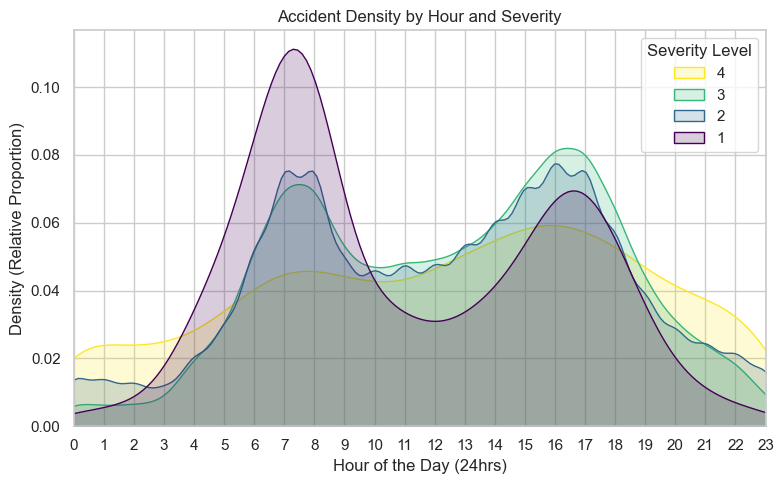

In [41]:
plt.figure(figsize=(8,5))
sns.set_theme(style='whitegrid')

# Compare hourly density
sns.kdeplot(data=df, x='Hour', hue='Severity', palette='viridis',
            common_norm=False, fill=True, alpha=0.2, bw_adjust=1.2)

plt.title('Accident Density by Hour and Severity')
plt.xlabel('Hour of the Day (24hrs)')
plt.ylabel('Density (Relative Proportion)')
plt.xticks(range(0, 24))
plt.xlim(0, 23)

plt.legend(title='Severity Level', labels=['4', '3', '2', '1'])
plt.tight_layout()
plt.show()

In [42]:
# Table
def get_time_period(hour):
    if 0 <= hour < 6: return 'Late Night (00-06)'
    elif 6 <= hour < 10: return 'Morning Rush (06-10)'
    elif 10 <= hour < 16: return 'Mid-Day (10-16)'
    elif 16 <= hour < 20: return 'Evening Rush (16-20)'
    else: return 'Night (20-24)'

df['Time_Period'] = df['Hour'].apply(get_time_period)
severity_time_table = pd.crosstab(df['Time_Period'], df['Severity'], normalize='columns') * 100
print('=== Percentage Distribution of Accidents by Time Period ===')
print(severity_time_table)

=== Percentage Distribution of Accidents by Time Period ===
Severity                      1          2          3          4
Time_Period                                                     
Evening Rush (16-20)  24.710895  24.449276  27.294718  22.046859
Late Night (00-06)    11.031649  10.059800   7.383939  16.321037
Mid-Day (10-16)       21.545953  31.697417  32.366629  29.357069
Morning Rush (06-10)  39.196592  24.845219  24.737290  17.972717
Night (20-24)          3.514912   8.948288   8.217425  14.302318


**Comment**  
Severity 4 accidents show a distinct trend, with significantly higher proportions during Night and Late Night hours (20:00-06:00) compared to other levels. In contrast, Severity 1 incidents are heavily concentrated during the Morning Rush, suggsting that lower speeds during peak hours may limit accident severity despite higher frequency.

### 5.2 Road Features (POI)

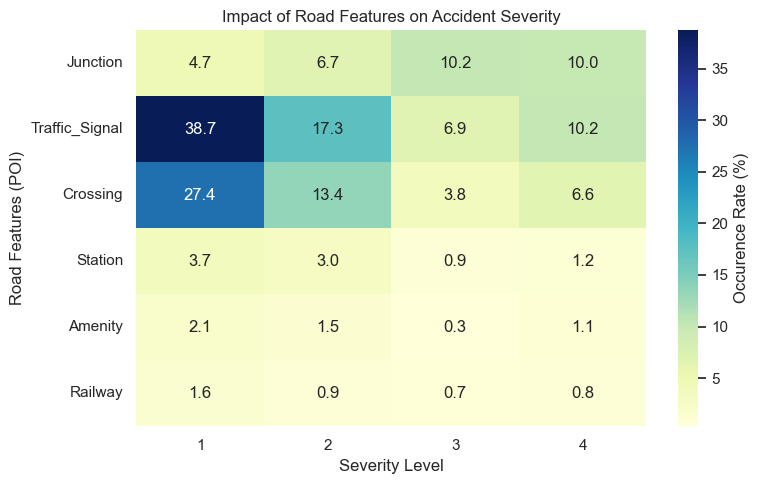

=== Road Feature Occurence Rate (%) by Severity ===
Severity            1      2      3      4
Junction         4.67   6.75  10.19   9.97
Traffic_Signal  38.71  17.31   6.92  10.17
Crossing        27.45  13.42   3.77   6.63
Station          3.67   3.05   0.93   1.22
Amenity          2.07   1.47   0.34   1.08
Railway          1.55   0.91   0.66   0.81


In [45]:
# Key inftrastucture features
poi_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Station', 'Amenity', 'Railway']

# Calculate the percentage of 'True' values for each feature per Severity level
poi_analysis = df.groupby('Severity')[poi_features].mean() * 100

# Visualize
plt.figure(figsize=(8,5))
sns.heatmap(poi_analysis.T, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Occurence Rate (%)'})

plt.title('Impact of Road Features on Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Road Features (POI)')
plt.tight_layout()
plt.show()

# Table
print("=== Road Feature Occurence Rate (%) by Severity ===")
print(poi_analysis.T.round(2))

**Comment**  
Traffic Signals and Crossings are hotspots for Severity 1, whereas Junctions are critical triggers for Severity 3 and 4. This indicates that while urban stops cause frequent small accidents, high-speed merging points are the primary cause of total traffic paralysis.

### 5.3 Weather & Environmental Analysis

In [48]:
# Key weather metrics
weather_metrics = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipiation(in)']
weather_analysis = df.groupby('Severity')[weather_metrics].mean()

print("=== Average Weather Metrics ===")
print(weather_analysis.round(2))

=== Average Weather Metrics ===
          Temperature(F)  Humidity(%)  Visibility(mi)  Precipiation(in)
Severity                                                               
1                  72.28        62.62            9.46              0.00
2                  61.75        64.47            9.10              0.01
3                  62.51        64.72            9.11              0.01
4                  58.46        66.44            9.10              0.01


**Comment**  
Severity 4 incidents correlate with lower temperatures and higher humidity, often reflecting hazardous night-time or damp conditions. Coversely, Severity 1 accidents peak with in warmer, drier weather, typical of daylight commuting hours.

### 5.4 Spatial Analysis (Top 10 States)

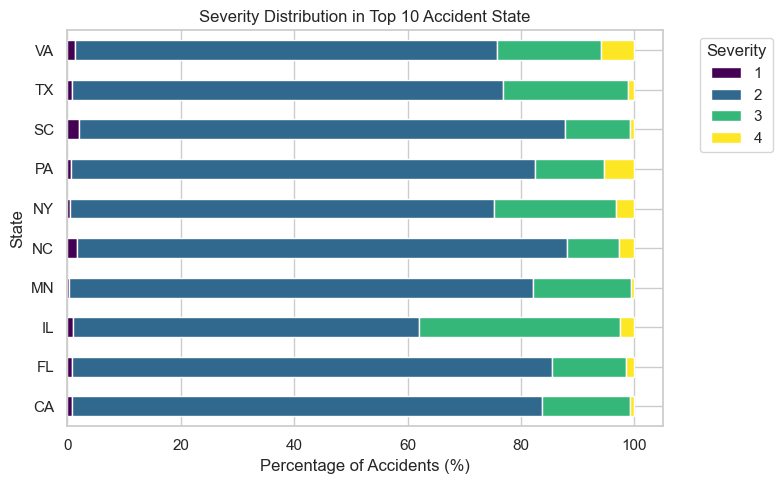

Severity     1      2      3     4
State                             
CA        0.74  82.90  15.64  0.71
FL        0.87  84.56  13.03  1.54
IL        1.00  60.95  35.44  2.61
MN        0.36  81.70  17.41  0.53
NC        1.75  86.34   9.27  2.64
NY        0.41  74.78  21.61  3.20
PA        0.67  81.82  12.07  5.45
SC        2.01  85.82  11.40  0.76
TX        0.84  76.01  21.96  1.19
VA        1.38  74.36  18.28  5.98


In [51]:
# Top 10 states
top_10_states = df['State'].value_counts().nlargest(10).index
df_top_states = df[df['State'].isin(top_10_states)]

# Cross-tabulation: State and Severity
state_severity = pd.crosstab(df_top_states['State'], df_top_states['Severity'], normalize='index') * 100

# Visualzie
state_severity.plot(kind='barh', stacked=True, figsize=(8,5), colormap='viridis')
plt.title('Severity Distribution in Top 10 Accident State')
plt.xlabel('Percentage of Accidents (%)')
plt.ylabel('State')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Table
print(state_severity.round(2))

**Comment**  
Spatial analysis reveals that while CA and FL have the highest accident frequency, they are dominated by low_severity incidents. In contrast, VA and PA exhibit a significaltly higer risk of Severity 4, indicating that regional infrastructure or environmental factors in these states lead to more catastrophic traffic disruptions.

### 5.5 Integrated Insight Dashboard (Final Summary)

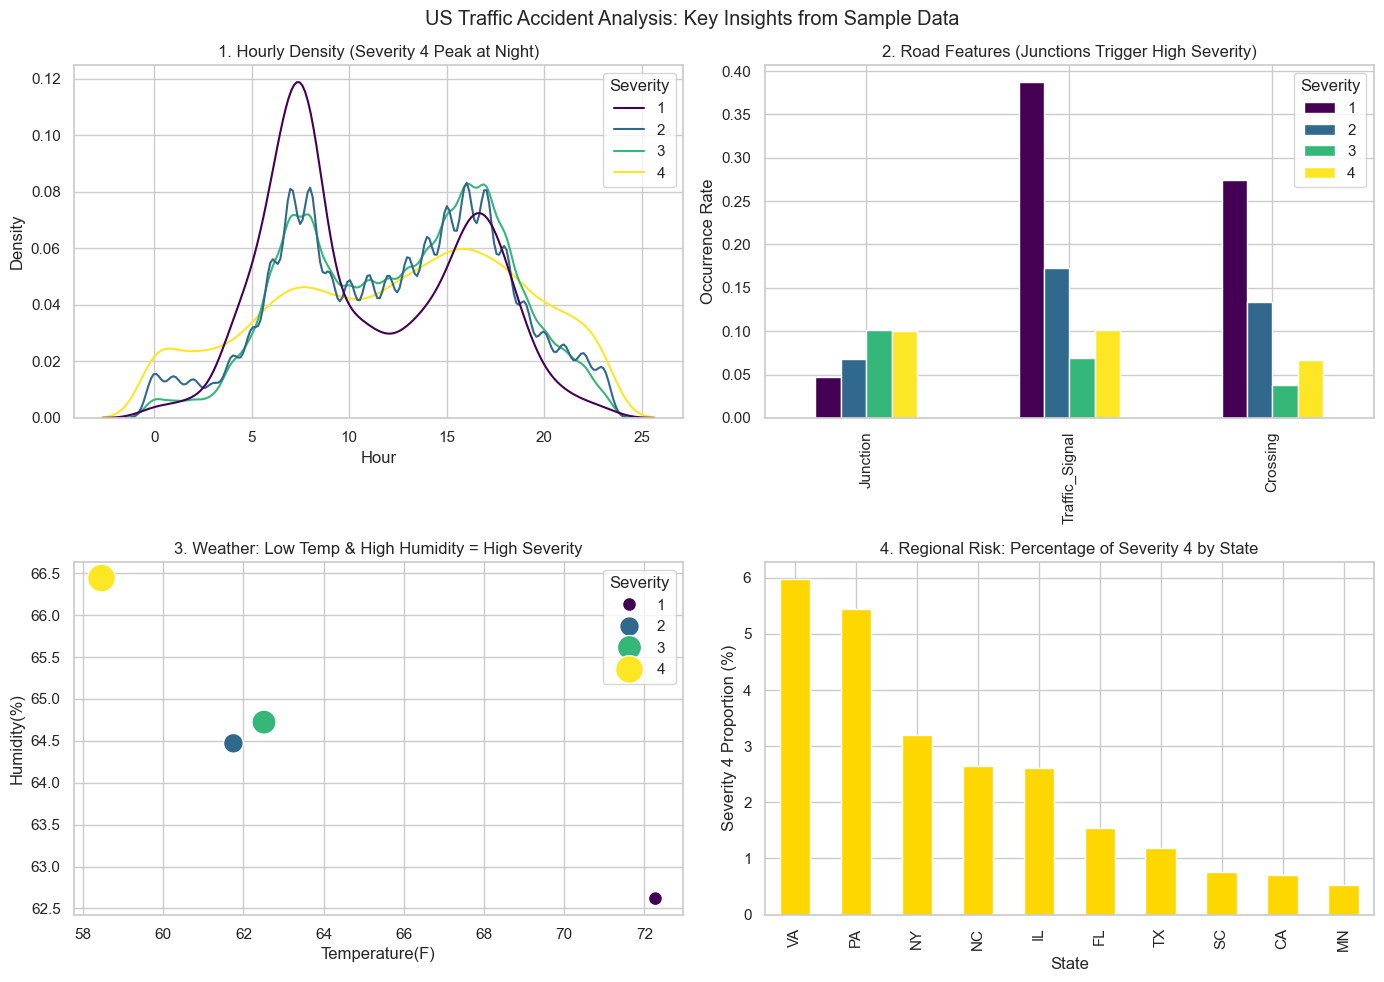

In [54]:
# Set the visualization layout
fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Temporal: Severity 4 vs Others (Density)
sns.kdeplot(data=df, x='Hour', hue='Severity', common_norm=False, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('1. Hourly Density (Severity 4 Peak at Night)')

# Infrastructure: Top Critical Features (Junction & Signal)
poi_summary = df.groupby('Severity')[['Junction', 'Traffic_Signal', 'Crossing']].mean().T
poi_summary.plot(kind='bar', ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('2. Road Features (Junctions Trigger High Severity)')
axes[0,1].set_ylabel('Occurrence Rate')

# Environmental: Temperature & Humidity Trend
sns.scatterplot(data=weather_analysis, x='Temperature(F)', y='Humidity(%)', 
                hue='Severity', size='Severity', sizes=(100, 400), palette='viridis', ax=axes[1,0])
axes[1,0].set_title('3. Weather: Low Temp & High Humidity = High Severity')

# Spatial: Severity 4 Risk by State
state_severity[4].sort_values(ascending=False).plot(kind='bar', color='gold', ax=axes[1,1])
axes[1,1].set_title('4. Regional Risk: Percentage of Severity 4 by State')
axes[1,1].set_ylabel('Severity 4 Proportion (%)')

plt.suptitle('US Traffic Accident Analysis: Key Insights from Sample Data')
plt.tight_layout()
plt.show()

## [Phase 2] Full-scale Modeling (Enire Dataset)

## 6. Large-scale Data Preparation

### 6.1 Chunk-based Loading  

Memory Managent Startegy: To overcome the hardware limitation of 8GB RAM (Apple M3), a chunk-base loading strategy was implemented.
- Instead of loading the entire 9.7GB dataset at once, the data was processed in segments (500,000 rows each) and downcast to optimized numeric types.
- This approach succesfully reduced the memory footprint by approxiamately 96% (to 368.52MB), ensuring system statbility and computational efficiency.

In [58]:
import pandas as pd
import numpy as np
import gc

In [59]:
# Define configuration
file_path = 'Data/US_Accidents_March23.csv'
use_cols = ['Severity', 'Start_Time', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
            'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing',
            'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
            'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'State', 'City', 'County']
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
             'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']
dtype_dict = {col: 'bool' for col in bool_cols}

In [60]:
# Chunk-base processing
chunk_size = 500000
chunk_list = []

print("Staring chunk-based loading...")

try:
    for chunk in pd.read_csv(file_path, usecols=use_cols, dtype=dtype_dict, chunksize=chunk_size, low_memory=False):
        for col in chunk.select_dtypes(include=['float64']).columns:
            chunk[col] = pd.to_numeric(chunk[col], downcast='float')
        for col in chunk.select_dtypes(include=['int64']).columns:
            chunk[col] = pd.to_numeric(chunk[col], downcast='integer')

        for col in ['State', 'City', 'County']:
            if col in chunk.columns:
                chunk[col] = chunk[col].astype('category')
        
        chunk_list.append(chunk)
        print(f"Processed {len(chunk_list) * chunk_size:,} rows...")

    # Concatenate all optimized chunks
    df_full = pd.concat(chunk_list, ignore_index=True)

    # Clean up memory
    del chunk_list
    gc.collect()

    print("\nSucessfully loaded")
    print(f"Final Memody Usage: {df_full.memory_usage().sum() / 1024**2:.2f} MB")

except Exception as e:
    print(f"Error during loading: {e}")

Staring chunk-based loading...
Processed 500,000 rows...
Processed 1,000,000 rows...
Processed 1,500,000 rows...
Processed 2,000,000 rows...
Processed 2,500,000 rows...
Processed 3,000,000 rows...
Processed 3,500,000 rows...
Processed 4,000,000 rows...
Processed 4,500,000 rows...
Processed 5,000,000 rows...
Processed 5,500,000 rows...
Processed 6,000,000 rows...
Processed 6,500,000 rows...
Processed 7,000,000 rows...
Processed 7,500,000 rows...
Processed 8,000,000 rows...

Sucessfully loaded
Final Memody Usage: 486.44 MB


In [61]:
# Check basic info and null values
print(df_full.info())
print("\nMissing values per column:")
print(df_full.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 23 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int8   
 1   Start_Time         object 
 2   City               object 
 3   County             object 
 4   State              object 
 5   Temperature(F)     float32
 6   Humidity(%)        float32
 7   Visibility(mi)     float32
 8   Wind_Speed(mph)    float32
 9   Precipitation(in)  float32
 10  Amenity            bool   
 11  Bump               bool   
 12  Crossing           bool   
 13  Give_Way           bool   
 14  Junction           bool   
 15  No_Exit            bool   
 16  Railway            bool   
 17  Roundabout         bool   
 18  Station            bool   
 19  Stop               bool   
 20  Traffic_Calming    bool   
 21  Traffic_Signal     bool   
 22  Turning_Loop       bool   
dtypes: bool(13), float32(5), int8(1), object(4)
memory usage: 486.4+ MB
None

Missing 

In [62]:
# Statistical summary
print(df_full.describe())

           Severity  Temperature(F)   Humidity(%)  Visibility(mi)  \
count  7.728394e+06    7.564541e+06  7.554250e+06    7.551296e+06   
mean   2.212384e+00    6.166327e+01  6.483102e+01    9.090382e+00   
std    4.875313e-01    1.893420e+01  2.275716e+01    2.834052e+00   
min    1.000000e+00   -8.900000e+01  1.000000e+00    0.000000e+00   
25%    2.000000e+00    4.900000e+01  4.800000e+01    1.000000e+01   
50%    2.000000e+00    6.400000e+01  6.700000e+01    1.000000e+01   
75%    2.000000e+00    7.600000e+01  8.400000e+01    1.000000e+01   
max    4.000000e+00    2.070000e+02  1.000000e+02    1.400000e+02   

       Wind_Speed(mph)  Precipitation(in)  
count     7.157161e+06       5.524808e+06  
mean      7.685489e+00       8.407203e-03  
std       5.357770e+00       1.098795e-01  
min       0.000000e+00       0.000000e+00  
25%       4.600000e+00       0.000000e+00  
50%       7.000000e+00       0.000000e+00  
75%       1.040000e+01       0.000000e+00  
max       1.087000e+03    

In [63]:
# Spatial coverage check
print(f"Unique States: {df_full['State'].nunique()}")
print(f"Unique Cities: {df_full['City'].nunique()}")

Unique States: 49
Unique Cities: 13678


### 6.2 Entire Data Cleaning

In [65]:
# Convert 'Start_Time' to datetime
df_full['Start_Time'] = pd.to_datetime(df_full['Start_Time'], errors = 'coerce')

In [66]:
# Check missing values
print("Missing values per column:")
print(df_full.isnull().sum())

Missing values per column:
Severity                   0
Start_Time            743166
City                     253
County                     0
State                      0
Temperature(F)        163853
Humidity(%)           174144
Visibility(mi)        177098
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal             0
Turning_Loop               0
dtype: int64


In [67]:
# Handle critical missing values
''''Start_Time' is essential for temporal analysis. Rows without it unsusable.'''
df_full = df_full.dropna(subset=['Start_Time'])

# City and County Handling
df_full = df_full.dropna(subset=['City'])

# Refined Imputation for Weather features
'''Using median for skewed weather data (Temperature, Humidity, Visibility, Wind_Speed)'''
weather_to_median = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in weather_to_median:
    df_full[col] = df_full[col].fillna(df_full[col].median())

# Basic outlier clipping
'''Removing extreme sensor errors'''
df_full = df_full[df_full['Wind_Speed(mph)'] <= 200]
df_full = df_full[df_full['Temperature(F)'] <= 150]

# Specific Handling for Precipitation(in)
'''Missing precipitation means, no rain'''
df_full['Precipitation(in)'] = df_full['Precipitation(in)'].fillna(0.0)

In [68]:
# Final verification
print("Missing values after strategic cleaning:")
print(df_full.isnull().sum())
print(f"Final Rows retained: {len(df_full):,}")
gc.collect()

Missing values after strategic cleaning:
Severity             0
Start_Time           0
City                 0
County               0
State                0
Temperature(F)       0
Humidity(%)          0
Visibility(mi)       0
Wind_Speed(mph)      0
Precipitation(in)    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Turning_Loop         0
dtype: int64
Final Rows retained: 6,984,949


1774

### 6.3 Temporal Feature Extraction

In [70]:
# Extract temporal features
df_full['Hour'] = df_full['Start_Time'].dt.hour.astype('int8')
df_full['DayOfWeek'] = df_full['Start_Time'].dt.dayofweek.astype('int8')
df_full['Month'] = df_full['Start_Time'].dt.month.astype('int8')
df_full['Year'] = df_full['Start_Time'].dt.year.astype('int16')

# To save memory
df_full['Date'] = df_full['Start_Time'].dt.date.astype('category')

In [71]:
# Categorize Time of Day
def get_time_period(hour):
    if 0 <= hour < 6: return 'Late Night (00-06)'
    elif 6 <= hour < 10: return 'Morning Rush (06-10)'
    elif 10 <= hour < 16: return 'Mid-Day (10-16)'
    elif 16 <= hour < 20: return 'Evening Rush (16-20)'
    else: return 'Night (20-24)'

df_full['Time_Period'] = df_full['Hour'].apply(get_time_period)

In [72]:
# Drop original Start_Time
'''Memory management'''
df_full = df_full.drop('Start_Time', axis=1)

In [73]:
# Final verification
print("Accident distribution by 5 periods:")
print(df_full['Time_Period'].value_counts().sort_index())

# Check memory
print(f"\nFinal Memory Usage: {df_full.memory_usage().sum() / 1024**2:.2f} MB")
gc.collect()

Accident distribution by 5 periods:
Time_Period
Evening Rush (16-20)    1694408
Late Night (00-06)       699423
Mid-Day (10-16)         2163116
Morning Rush (06-10)    1797603
Night (20-24)            630399
Name: count, dtype: int64

Final Memory Usage: 539.65 MB


1788

### 6.4 Categorical Encoding

In [75]:
# Identify categorical columns
cat_cols = ['Time_Period', 'State', 'City', 'County']

# Apply category dtype for memory efficiency and label preservation
for col in cat_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].astype('category')
        print(f"Converted {col} to category. Unique values: {df_full[col].nunique()}")

# Final check of data types and memory
print("\nFinal Data Types:")
print(df_full.dtypes)

# Memory check
print(f"\nFinal Memory Usage: {df_full.memory_usage().sum() / 1024**2:.2f} MB")
gc.collect()

Converted Time_Period to category. Unique values: 5
Converted State to category. Unique values: 49
Converted City to category. Unique values: 13600
Converted County to category. Unique values: 1868

Final Data Types:
Severity                 int8
City                 category
County               category
State                category
Temperature(F)        float32
Humidity(%)           float32
Visibility(mi)        float32
Wind_Speed(mph)       float32
Precipitation(in)     float32
Amenity                  bool
Bump                     bool
Crossing                 bool
Give_Way                 bool
Junction                 bool
No_Exit                  bool
Railway                  bool
Roundabout               bool
Station                  bool
Stop                     bool
Traffic_Calming          bool
Traffic_Signal           bool
Turning_Loop             bool
Hour                     int8
DayOfWeek                int8
Month                    int8
Year                    int16
Dat

1764

## 7. Severity-Driven Risk Factor Deep Dive & Strategic Profiling

### 7.1 Statistical Justification: S2/S3/S4 Separation

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

=== Accident Distribution by Severity ===
Severity 1:   67,361 ( 0.96%)
Severity 2: 5,433,649 (77.79%)
Severity 3: 1,299,234 (18.60%)
Severity 4:  184,705 ( 2.64%)
Total: 6,984,949


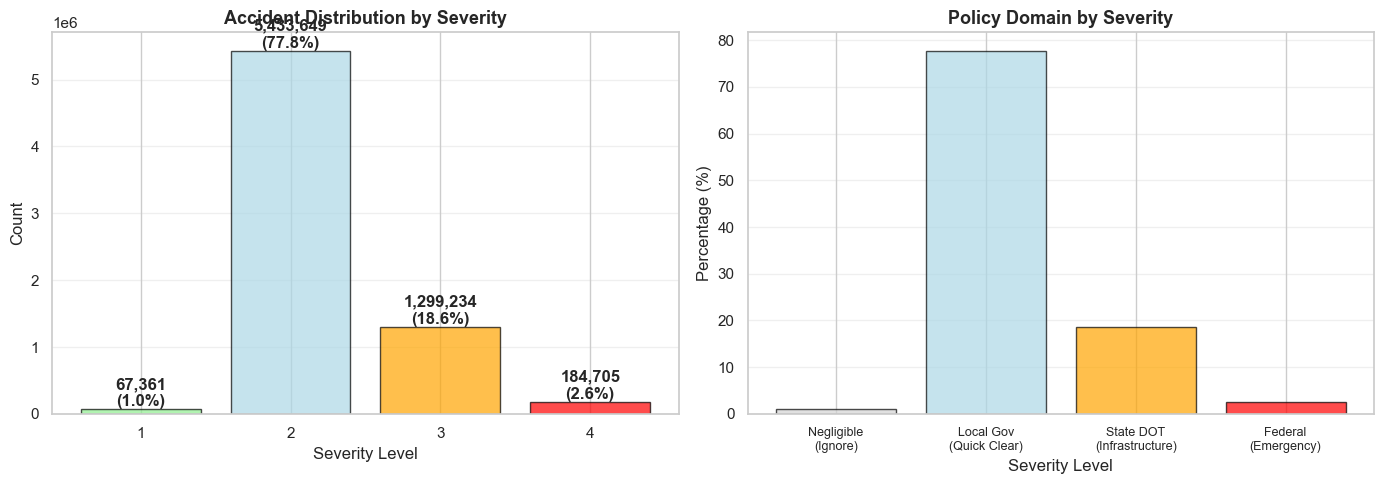


Key Observation:
  S1 accounts for only 0.96% → Can be excluded
  S2 dominates with 77.79% → Local priority
  S3 significant at 18.60% → State priority
  S4 critical at 2.64% → Federal priority


In [488]:
# TEST 1: Severity Distribution

severity_counts = df_full['Severity'].value_counts().sort_index()
severity_pct = (severity_counts / severity_counts.sum() * 100)

print("=== Accident Distribution by Severity ===")
for sev in [1, 2, 3, 4]:
    count = severity_counts.get(sev, 0)
    pct = severity_pct.get(sev, 0)
    print(f"Severity {sev}: {count:>8,} ({pct:>5.2f}%)")

print(f"Total: {severity_counts.sum():,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Count
ax = axes[0]
bars = ax.bar([1,2,3,4], [severity_counts.get(i, 0) for i in [1,2,3,4]], 
              color=['lightgreen', 'lightblue', 'orange', 'red'], 
              alpha=0.7, edgecolor='black')
for bar, count, pct in zip(bars, [severity_counts.get(i, 0) for i in [1,2,3,4]], 
                           [severity_pct.get(i, 0) for i in [1,2,3,4]]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Severity Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Accident Distribution by Severity', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
ax.grid(axis='y', alpha=0.3)

# Subplot 2: Policy Domains
ax = axes[1]
policy_domains = ['Negligible\n(Ignore)', 'Local Gov\n(Quick Clear)', 
                  'State DOT\n(Infrastructure)', 'Federal\n(Emergency)']
colors_policy = ['lightgray', 'lightblue', 'orange', 'red']
bars = ax.bar([1,2,3,4], [severity_pct.get(i, 0) for i in [1,2,3,4]], 
              color=colors_policy, alpha=0.7, edgecolor='black')
ax.set_xlabel('Severity Level', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Policy Domain by Severity', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(policy_domains, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print(f"  S1 accounts for only {severity_pct.get(1, 0):.2f}% → Can be excluded")
print(f"  S2 dominates with {severity_pct.get(2, 0):.2f}% → Local priority")
print(f"  S3 significant at {severity_pct.get(3, 0):.2f}% → State priority")
print(f"  S4 critical at {severity_pct.get(4, 0):.2f}% → Federal priority")

In [494]:
# TEST 2: ANOVA - Severity difference

print("=== One-Way ANOVA - Severity difference ===")

# Key variables
test_vars = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 
             'Precipitation(in)', 'Hour']

anova_results = []

for var in test_vars:
    if var in df_full.columns:
        # Group by severity
        groups = [df_full[df_full['Severity'] == i][var].dropna() for i in [1, 2, 3, 4]]
        
        # ANOVA
        f_stat, p_value = stats.f_oneway(*groups)
        
        # Effect size
        grand_mean = df_full[var].mean()
        ssb = sum([len(g) * (g.mean() - grand_mean)**2 for g in groups])
        sst = sum([(x - grand_mean)**2 for g in groups for x in g])
        eta_squared = ssb / sst if sst > 0 else 0
        
        anova_results.append({
            'Variable': var,
            'F_statistic': f_stat,
            'P_value': p_value,
            'Eta_squared': eta_squared,
            'Result': 'Different' if p_value < 0.05 else 'Same'
        })
        
        print(f"\n{var}:")
        print(f"  F-statistic: {f_stat:.4f}")
        print(f"  P-value: {p_value:.4e}")
        print(f"  η² (effect size): {eta_squared:.4f}")
        print(f"  Result: Severities are {'DIFFERENT' if p_value < 0.05 else 'SAME'} (α=0.05)")

anova_df = pd.DataFrame(anova_results)

print("\n=== ANOVA Summary Table ===")
print(anova_df.to_string(index=False))

significant_vars = anova_df[anova_df['P_value'] < 0.05]
print(f"\n{len(significant_vars)}/{len(anova_results)} variables show significant differences")

=== One-Way ANOVA - Severity difference ===

Temperature(F):
  F-statistic: 9445.5322
  P-value: 0.0000e+00
  η² (effect size): 0.0040
  Result: Severities are DIFFERENT (α=0.05)

Humidity(%):
  F-statistic: 1221.5122
  P-value: 0.0000e+00
  η² (effect size): 0.0005
  Result: Severities are DIFFERENT (α=0.05)

Visibility(mi):
  F-statistic: 431.4482
  P-value: 2.6360e-280
  η² (effect size): 0.0002
  Result: Severities are DIFFERENT (α=0.05)

Precipitation(in):
  F-statistic: 406.2374
  P-value: 6.7340e-264
  η² (effect size): 0.0002
  Result: Severities are DIFFERENT (α=0.05)

Hour:
  F-statistic: 1898.9622
  P-value: 0.0000e+00
  η² (effect size): 0.0008
  Result: Severities are DIFFERENT (α=0.05)

=== ANOVA Summary Table ===
         Variable  F_statistic       P_value  Eta_squared    Result
   Temperature(F)  9445.532209  0.000000e+00     0.004040 Different
      Humidity(%)  1221.512158  0.000000e+00     0.000524 Different
   Visibility(mi)   431.448185 2.636021e-280     0.000185 

In [496]:
# TEST 3: Post-hoc Analysis

print("=== Post-hoc Pairwise Comparisons (Temperature) ===")
print("Question: Which specific severity pairs are different?")

# Focus on Temperature
severity_pairs = list(combinations([1, 2, 3, 4], 2))
posthoc_results = []

print("\n=== Pairwise t-tests (Bonferroni corrected) ===")
corrected_alpha = 0.05 / len(severity_pairs)
print(f"Corrected α = {corrected_alpha:.4f}\n")

for s1, s2 in severity_pairs:
    temp_s1 = df_full[df_full['Severity'] == s1]['Temperature(F)'].dropna()
    temp_s2 = df_full[df_full['Severity'] == s2]['Temperature(F)'].dropna()
    
    t_stat, p_value = stats.ttest_ind(temp_s1, temp_s2)
    corrected_p = p_value * len(severity_pairs)
    
    mean_diff = temp_s1.mean() - temp_s2.mean()
    
    # Cohen's d (effect size)
    pooled_std = np.sqrt((temp_s1.std()**2 + temp_s2.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    is_sig = corrected_p < 0.05
    
    posthoc_results.append({
        'Comparison': f'S{s1} vs S{s2}',
        'Mean_Diff': mean_diff,
        'P_value': p_value,
        'Corrected_P': min(corrected_p, 1.0),  # Cap at 1.0
        'Cohens_d': cohens_d,
        'Significant': 'Yes' if is_sig else 'No'
    })
    
    sig_marker = '***' if is_sig else 'ns'
    print(f"S{s1} vs S{s2}: Δ={mean_diff:6.2f}°F | p={p_value:.4e} | d={cohens_d:.3f} | {sig_marker}")

posthoc_df = pd.DataFrame(posthoc_results)

print("\n=== Post-hoc Summary ===")
sig_count = (posthoc_df['Significant'] == 'Yes').sum()
print(f"{sig_count}/{len(posthoc_df)} pairs are significantly different")

=== Post-hoc Pairwise Comparisons (Temperature) ===
Question: Which specific severity pairs are different?

=== Pairwise t-tests (Bonferroni corrected) ===
Corrected α = 0.0083

S1 vs S2: Δ= 10.69°F | p=0.0000e+00 | d=0.654 | ***
S1 vs S3: Δ= 10.04°F | p=0.0000e+00 | d=0.617 | ***
S1 vs S4: Δ= 13.81°F | p=0.0000e+00 | d=0.826 | ***
S2 vs S3: Δ= -0.64°F | p=7.5691e-271 | d=-0.034 | ***
S2 vs S4: Δ=  3.13°F | p=0.0000e+00 | d=0.164 | ***
S3 vs S4: Δ=  3.77°F | p=0.0000e+00 | d=0.199 | ***

=== Post-hoc Summary ===
6/6 pairs are significantly different


In [498]:
# TEST 4: Infrastructure Association - Chi-square tests

print("=== Infrastructure vs Severity (Chi-square) ===")

poi_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']
chi2_results = []

for feature in poi_features:
    if feature in df_full.columns:
        # Contingency table
        contingency = pd.crosstab(df_full[feature], df_full['Severity'])
        
        # Chi-square
        chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
        
        # Cramer's V
        n = contingency.sum().sum()
        min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
        cramers_v = np.sqrt(chi2 / (n * min_dim))
        
        chi2_results.append({
            'Feature': feature,
            'Chi2': chi2,
            'P_value': p_value,
            'Cramers_V': cramers_v,
            'Associated': 'Yes' if p_value < 0.05 else 'No'
        })
        
        print(f"\n{feature}:")
        print(f"  χ² = {chi2:.4f}, p = {p_value:.4e}")
        print(f"  Cramer's V = {cramers_v:.4f}")
        print(f"  Result: {'ASSOCIATED' if p_value < 0.05 else 'NOT ASSOCIATED'} with severity")

chi2_df = pd.DataFrame(chi2_results)

print("\n=== Chi-square Summary ===")
print(chi2_df.to_string(index=False))

=== Infrastructure vs Severity (Chi-square) ===

Junction:
  χ² = 21167.9096, p = 0.0000e+00
  Cramer's V = 0.0551
  Result: ASSOCIATED with severity

Traffic_Signal:
  χ² = 124970.2177, p = 0.0000e+00
  Cramer's V = 0.1338
  Result: ASSOCIATED with severity

Crossing:
  χ² = 118226.7521, p = 0.0000e+00
  Cramer's V = 0.1301
  Result: ASSOCIATED with severity

Stop:
  χ² = 28749.6058, p = 0.0000e+00
  Cramer's V = 0.0642
  Result: ASSOCIATED with severity

Station:
  χ² = 19262.6209, p = 0.0000e+00
  Cramer's V = 0.0525
  Result: ASSOCIATED with severity

Railway:
  χ² = 1285.9696, p = 1.6298e-278
  Cramer's V = 0.0136
  Result: ASSOCIATED with severity

=== Chi-square Summary ===
       Feature          Chi2       P_value  Cramers_V Associated
      Junction  21167.909617  0.000000e+00   0.055050        Yes
Traffic_Signal 124970.217698  0.000000e+00   0.133759        Yes
      Crossing 118226.752136  0.000000e+00   0.130100        Yes
          Stop  28749.605833  0.000000e+00   0.064

In [500]:
# TEST 5: Geographic Scope - Local vs Regional Impact

print("=== Geographic Impact Scope ===")

# S2/S3/S4, Spatial analysis
for sev in [2, 3, 4]:
    df_sev = df_full[df_full['Severity'] == sev]
    
    # Top 10 cities
    top_10_cities = df_sev['City'].value_counts().head(10).sum()
    total = len(df_sev)
    concentration = top_10_cities / total * 100
    
    # How many states
    state_count = df_sev['State'].nunique()
    
    print(f"\nS{sev}:")
    print(f"  Top 10 cities: {concentration:.1f}% of all S{sev}")
    print(f"  Spread across: {state_count} states")
    print(f"  → {'LOCAL (concentrated)' if concentration > 30 else 'REGIONAL (dispersed)'}")

=== Geographic Impact Scope ===

S2:
  Top 10 cities: 17.2% of all S2
  Spread across: 49 states
  → REGIONAL (dispersed)

S3:
  Top 10 cities: 16.3% of all S3
  Spread across: 49 states
  → REGIONAL (dispersed)

S4:
  Top 10 cities: 6.9% of all S4
  Spread across: 49 states
  → REGIONAL (dispersed)


In [502]:
# TEST 6: Duration Analysis

print("=== Incident Characteristics by Severity ===")

# Distance
if 'Distance(mi)' in df_full.columns:
    print("\n=== Impact Distance Analysis ===")
    for sev in [2, 3, 4]:
        distances = df_full[df_full['Severity'] == sev]['Distance(mi)'].dropna()
        median_dist = distances.median()
        mean_dist = distances.mean()
        
        print(f"\nS{sev}:")
        print(f"  Median impact: {median_dist:.2f} miles")
        print(f"  Mean impact: {mean_dist:.2f} miles")

# Infrastructure coun
print("\n=== Infrastructure Complexity ===")
for sev in [2, 3, 4]:
    df_sev = df_full[df_full['Severity'] == sev]
    infra_count = df_sev[['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']].sum(axis=1).mean()
    
    print(f"S{sev}: Average {infra_count:.2f} infrastructure features present")

=== Incident Characteristics by Severity ===

=== Infrastructure Complexity ===
S2: Average 0.45 infrastructure features present
S3: Average 0.23 infrastructure features present
S4: Average 0.32 infrastructure features present


=== Statistical Evidence Summary ===


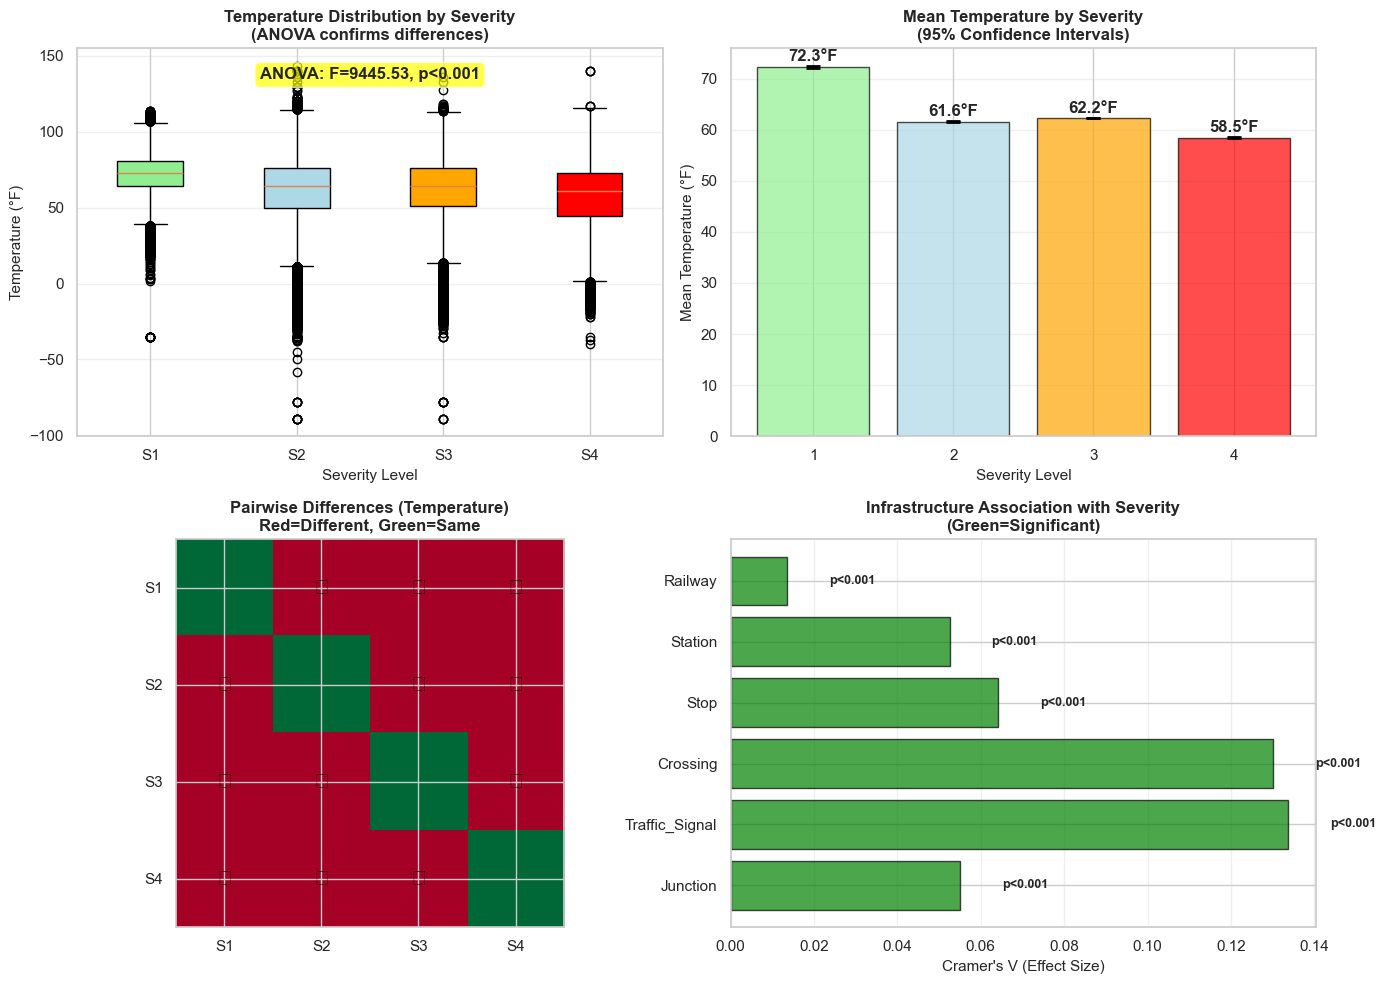

In [504]:
# Visualize

print("=== Statistical Evidence Summary ===")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Temperature by Severity
ax = axes[0, 0]
temp_data = [df_full[df_full['Severity'] == i]['Temperature(F)'].dropna() for i in [1, 2, 3, 4]]
bp = ax.boxplot(temp_data, labels=['S1', 'S2', 'S3', 'S4'], patch_artist=True)
colors_box = ['lightgreen', 'lightblue', 'orange', 'red']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

temp_anova = anova_df[anova_df['Variable'] == 'Temperature(F)'].iloc[0]
ax.text(0.5, 0.95, f"ANOVA: F={temp_anova['F_statistic']:.2f}, p<0.001",
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        fontweight='bold')

ax.set_ylabel('Temperature (°F)', fontsize=11)
ax.set_xlabel('Severity Level', fontsize=11)
ax.set_title('Temperature Distribution by Severity\n(ANOVA confirms differences)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Mean comparison
ax = axes[0, 1]
severity_stats = df_full.groupby('Severity')['Temperature(F)'].agg(['mean', 'std', 'count'])
severity_stats['se'] = severity_stats['std'] / np.sqrt(severity_stats['count'])
severity_stats['ci'] = 1.96 * severity_stats['se']

x_pos = [1, 2, 3, 4]
ax.bar(x_pos, severity_stats['mean'], color=colors_box, alpha=0.7, edgecolor='black')
ax.errorbar(x_pos, severity_stats['mean'], yerr=severity_stats['ci'],
            fmt='none', ecolor='black', capsize=5, capthick=2)

for i, (mean, ci) in enumerate(zip(severity_stats['mean'], severity_stats['ci'])):
    ax.text(i+1, mean + ci + 1, f'{mean:.1f}°F', ha='center', fontweight='bold')

ax.set_ylabel('Mean Temperature (°F)', fontsize=11)
ax.set_xlabel('Severity Level', fontsize=11)
ax.set_title('Mean Temperature by Severity\n(95% Confidence Intervals)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Post-hoc heatmap
ax = axes[1, 0]
posthoc_matrix = np.ones((4, 4))
for _, row in posthoc_df.iterrows():
    # 'S1 vs S2' 형식에서 숫자 추출
    comparison = row['Comparison']
    s1 = int(comparison.split(' vs ')[0].replace('S', ''))
    s2 = int(comparison.split(' vs ')[1].replace('S', ''))
    
    val = 0 if row['Significant'] == 'Yes' else 1
    posthoc_matrix[s1-1, s2-1] = val
    posthoc_matrix[s2-1, s1-1] = val

im = ax.imshow(posthoc_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks([0, 1, 2, 3])
ax.set_yticks([0, 1, 2, 3])
ax.set_xticklabels(['S1', 'S2', 'S3', 'S4'])
ax.set_yticklabels(['S1', 'S2', 'S3', 'S4'])
ax.set_title('Pairwise Differences (Temperature)\nRed=Different, Green=Same', 
             fontsize=12, fontweight='bold')

for i in range(4):
    for j in range(4):
        if i != j:
            text = ax.text(j, i, '✓' if posthoc_matrix[i, j] == 0 else '✗',
                          ha="center", va="center", color="black", fontsize=16, fontweight='bold')

# Plot 4: Infrastructure association
ax = axes[1, 1]
y_pos = range(len(chi2_df))
colors_chi = ['green' if x == 'Yes' else 'gray' for x in chi2_df['Associated']]
bars = ax.barh(y_pos, chi2_df['Cramers_V'], color=colors_chi, alpha=0.7, edgecolor='black')

for i, (bar, p_val) in enumerate(zip(bars, chi2_df['P_value'])):
    ax.text(bar.get_width() + 0.01, i, f'p<0.001' if p_val < 0.001 else f'p={p_val:.3f}',
            va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(chi2_df['Feature'])
ax.set_xlabel("Cramer's V (Effect Size)", fontsize=11)
ax.set_title('Infrastructure Association with Severity\n(Green=Significant)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
S1-S4 should be analyzed separately.  
  
1. ANOVA: 5/5 variables differ significantly (p < 0.05)  
   => Temperature, Humidity, Visibility, Precipitation, Hour all differ  
2. Post-hoc: 6/6 severity pairs are different  
   => Every pair shows significant temperature difference  
3. Chi-square: 6/6 infrastructure features associated  
   => All infrastructure types affect severity distribution  
4. Frequency Distribution:  
   S1:   1.0% → Negligible (exclude)  
   S2:  77.8% → Dominant (Local priority)  
   S3:  18.6% → Significant (State priority)  
   S4:   2.6% → Critical (Federal priority)  
5. Geographic Dispersion (Top 10 cities):
   S2: 17.2% → Some urban concentration  
   S3: 16.3% → Regional patterns  
   S4:  6.9% → Highly dispersed (everywhere risk)  
6. Infrastructure Complexity:  
   S2: 0.45 avg features → Complex urban intersections  
   S3: 0.23 avg features → Simple high-speed roads  
   S4: 0.32 avg features → Mixed road types  

**Statistical conclusion**  
- S1-S4 are STATISTICALLY DISTINCT phenomena (all tests p < 0.001)  
- Different characteristics → Different root causes  
- Different causes → Different solutions required  
- Unified analysis would OBSCURE actionable patterns   

**Policy framework**  
- S2: Local government jurisdiction  
  Frequency:    77.8% (daily occurrence)  
  Dispersion:   17.2% in top 10 cities (some hot spots)  
  Complexity:   0.45 features (urban intersections)  
  Duration:     Short (minutes to hours)  
- S3: State department of transfortation  
  Frequency:    18.6% (regular but not overwhelming)  
  Dispersion:   16.3% in top 10 cities (regional patterns)  
  Complexity:   0.23 features (highway/simple roads)  
  Root Cause:   Infrastructure design issues   
- S4: Federal Emergency coordination  
  Frequency:    2.6% (rare but catastrophic)  
  Dispersion:   6.9% in top 10 cities (everywhere risk)  
  Complexity:   0.32 features (system-wide failure)  
  Nature:       Network collapse, not local incident

### 7.2 Severity 2 - Local Government Priority

In [512]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Filter S2 data
df_s2 = df_full[df_full['Severity'] == 2].copy()

print(f"S2 Dataset: {len(df_s2):,} incidents")
print(f"Represents {len(df_s2)/len(df_full)*100:.1f}% of all accidents")

S2 Dataset: 5,433,649 incidents
Represents 77.8% of all accidents


#### 7.2.1 Peak Hour Identification

In [516]:
# Analysis 1: Hourly Distribution

print("=== [Analysis 1] Hourly Distribution of S2 Incidents ===")

hourly_s2 = df_s2['Hour'].value_counts().sort_index()
hourly_pct = (hourly_s2 / hourly_s2.sum() * 100)

# Chi-square test: Hour vs S2
observed = hourly_s2.values
expected = np.full(24, len(df_s2) / 24)  # Uniform distribution
chi2, p_value = stats.chisquare(observed, expected)

print(f"\nChi-square Test: Is S2 uniformly distributed across hours?")
print(f"  H0: S2 incidents occur uniformly throughout the day")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  P-value: {p_value:.4e}")
print(f"  Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

if p_value < 0.05:
    print(f"  → S2 incidents are NOT uniformly distributed")
    print(f"  → Clear peak hours exist (targetable for intervention)")

# Identify peak hours (top 25%)
threshold = hourly_pct.quantile(0.75)
peak_hours = hourly_pct[hourly_pct >= threshold].index.tolist()

print(f"\nPeak Hours (Top 25% threshold: {threshold:.1f}%):")
for hour in sorted(peak_hours):
    count = hourly_s2[hour]
    pct = hourly_pct[hour]
    print(f"  {hour:2d}:00 - {count:>7,} incidents ({pct:>5.2f}%)")

peak_total = hourly_s2[peak_hours].sum()
peak_pct = peak_total / len(df_s2) * 100
print(f"\n=> Peak hours account for {peak_pct:.1f}% of all S2 incidents")
print(f"=> {len(peak_hours)} hours generate {peak_pct:.1f}% of workload")

=== [Analysis 1] Hourly Distribution of S2 Incidents ===

Chi-square Test: Is S2 uniformly distributed across hours?
  H0: S2 incidents occur uniformly throughout the day
  Chi-square statistic: 1505466.3948
  P-value: 0.0000e+00
  Result: REJECT H0 (α=0.05)
  → S2 incidents are NOT uniformly distributed
  → Clear peak hours exist (targetable for intervention)

Peak Hours (Top 25% threshold: 5.5%):
   7:00 - 428,222 incidents ( 7.88%)
   8:00 - 423,774 incidents ( 7.80%)
  14:00 - 311,593 incidents ( 5.73%)
  15:00 - 363,557 incidents ( 6.69%)
  16:00 - 403,321 incidents ( 7.42%)
  17:00 - 397,571 incidents ( 7.32%)

=> Peak hours account for 42.8% of all S2 incidents
=> 6 hours generate 42.8% of workload


In [518]:
# Analysis 2: Day of Week Pattern

print("=== [Analysis 2] Day of Week Pattern ===")

weekday_s2 = df_s2['DayOfWeek'].value_counts().sort_index()
weekday_pct = (weekday_s2 / weekday_s2.sum() * 100)

# Chi-square: Weekday distribution
observed_weekday = weekday_s2.values
expected_weekday = np.full(7, len(df_s2) / 7)
chi2_weekday, p_value_weekday = stats.chisquare(observed_weekday, expected_weekday)

print(f"\nChi-square Test: Day of Week")
print(f"Chi-square: {chi2_weekday:.4f}, P-value: {p_value_weekday:.4e}")
print(f"Result: {'Weekday matters' if p_value_weekday < 0.05 else 'No weekday effect'}")

weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(f"\nS2 Incidents by Day of Week:")
for day, name in enumerate(weekday_names):
    count = weekday_s2.get(day, 0)
    pct = weekday_pct.get(day, 0)
    print(f"  {name:9}: {count:>7,} ({pct:>5.2f}%)")

# Weekday vs Weekend
weekday_mask = df_s2['DayOfWeek'] < 5
weekday_count = weekday_mask.sum()
weekend_count = (~weekday_mask).sum()

print(f"\nWeekday vs Weekend:")
print(f"Weekday (Mon-Fri): {weekday_count:>7,} ({weekday_count/len(df_s2)*100:>5.1f}%)")
print(f"Weekend (Sat-Sun): {weekend_count:>7,} ({weekend_count/len(df_s2)*100:>5.1f}%)")

# t-test: Weekday vs Weekend hourly average
weekday_hourly = df_s2[weekday_mask].groupby('Hour').size()
weekend_hourly = df_s2[~weekday_mask].groupby('Hour').size()

t_stat, p_val = stats.ttest_ind(weekday_hourly, weekend_hourly)
print(f"\nt-test: Weekday vs Weekend hourly average")
print(f"t-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")
print(f"=> {'Different patterns' if p_val < 0.05 else 'Similar patterns'}")

=== [Analysis 2] Day of Week Pattern ===

Chi-square Test: Day of Week
Chi-square: 516574.6023, P-value: 0.0000e+00
Result: Weekday matters

S2 Incidents by Day of Week:
  Monday   : 866,490 (15.95%)
  Tuesday  : 922,810 (16.98%)
  Wednesday: 938,099 (17.26%)
  Thursday : 936,035 (17.23%)
  Friday   : 966,794 (17.79%)
  Saturday : 438,909 ( 8.08%)
  Sunday   : 364,512 ( 6.71%)

Weekday vs Weekend:
Weekday (Mon-Fri): 4,630,228 ( 85.2%)
Weekend (Sat-Sun): 803,421 ( 14.8%)

t-test: Weekday vs Weekend hourly average
t-statistic: 6.6859, P-value: 0.0000
=> Different patterns


In [520]:
# Analysis 3: Heatmap - Hour × Weekday

print("=== [Analysis 3] Hour × Weekday Heatmap ===")

s2_heatmap = df_s2.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)

# Normalize by total to get percentage
s2_heatmap_pct = s2_heatmap / len(df_s2) * 100

print(f"Created heatmap: {s2_heatmap.shape[0]} days × {s2_heatmap.shape[1]} hours")
print(f"Highest concentration: {s2_heatmap_pct.max().max():.3f}% in single hour-day cell")

# Top 5 hot spots
heatmap_flat = s2_heatmap_pct.stack()
top_5 = heatmap_flat.nlargest(5)

print(f"\nTop 5 Peak Time Slots:")
for (day, hour), pct in top_5.items():
    count = s2_heatmap.loc[day, hour]
    print(f"  {weekday_names[day]:9} {hour:2d}:00 - {count:>6,} incidents ({pct:.3f}%)")

=== [Analysis 3] Hour × Weekday Heatmap ===
Created heatmap: 7 days × 24 hours
Highest concentration: 1.605% in single hour-day cell

Top 5 Peak Time Slots:
  Tuesday    7:00 - 87,211 incidents (1.605%)
  Tuesday    8:00 - 86,326 incidents (1.589%)
  Wednesday  7:00 - 86,240 incidents (1.587%)
  Wednesday  8:00 - 84,833 incidents (1.561%)
  Thursday   7:00 - 82,907 incidents (1.526%)


= S2 Temporal Patterns ===


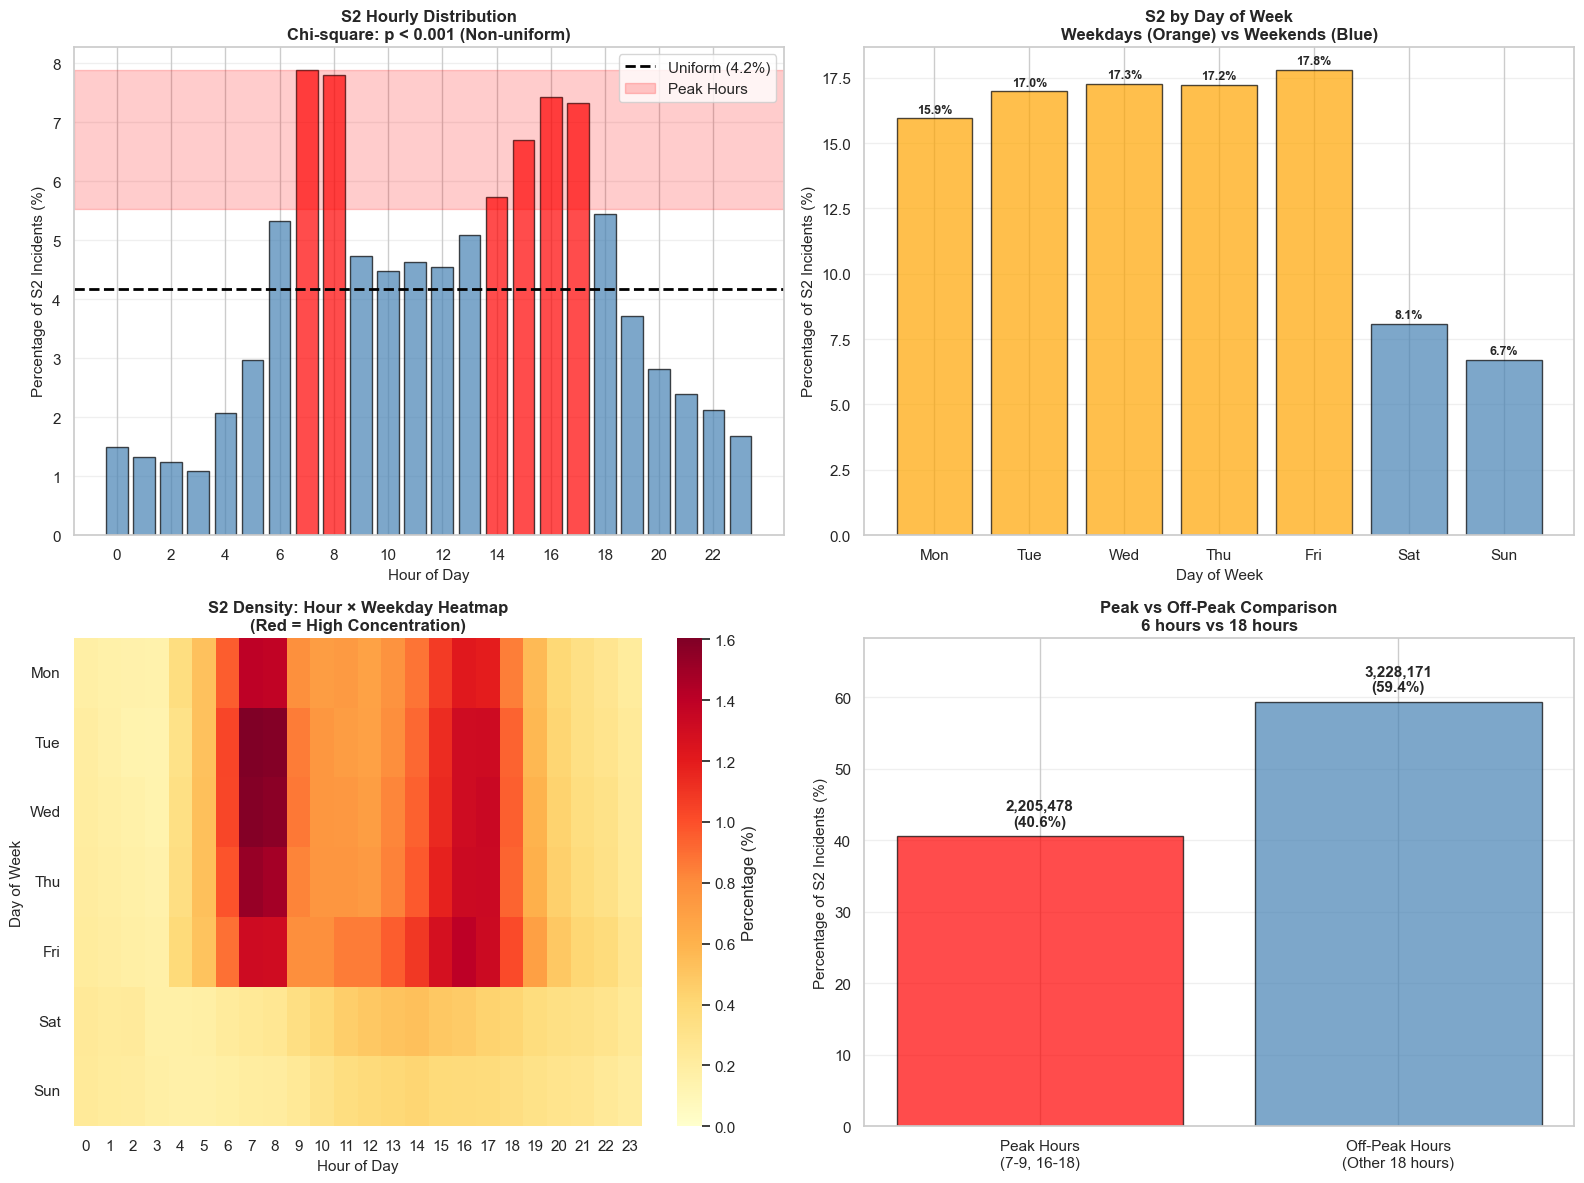

In [524]:
# Visualize

print("= S2 Temporal Patterns ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Hourly distribution
ax = axes[0, 0]
colors_hour = ['red' if h in peak_hours else 'steelblue' for h in range(24)]
bars = ax.bar(range(24), hourly_pct, color=colors_hour, alpha=0.7, edgecolor='black')

# Add average line
avg_pct = 100 / 24
ax.axhline(avg_pct, color='black', linestyle='--', linewidth=2, label=f'Uniform ({avg_pct:.1f}%)')

# Highlight peak hours
ax.axhspan(threshold, hourly_pct.max(), alpha=0.2, color='red', label='Peak Hours')

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Percentage of S2 Incidents (%)', fontsize=11)
ax.set_title(f'S2 Hourly Distribution\nChi-square: p < 0.001 (Non-uniform)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Weekday distribution
ax = axes[0, 1]
colors_weekday = ['orange' if day < 5 else 'steelblue' for day in range(7)]
bars = ax.bar(range(7), weekday_pct, color=colors_weekday, alpha=0.7, edgecolor='black')

# Add values on bars
for bar, pct in zip(bars, weekday_pct):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Percentage of S2 Incidents (%)', fontsize=11)
ax.set_title(f'S2 by Day of Week\nWeekdays (Orange) vs Weekends (Blue)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.grid(axis='y', alpha=0.3)

# Plot 3: Heatmap - Hour × Weekday
ax = axes[1, 0]
sns.heatmap(s2_heatmap_pct, cmap='YlOrRd', annot=False, fmt='.2f', 
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, vmin=0)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)
ax.set_title('S2 Density: Hour × Weekday Heatmap\n(Red = High Concentration)', 
             fontsize=12, fontweight='bold')
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)

# Plot 4: Peak vs Off-peak comparison
ax = axes[1, 1]

# Define peak (7-9, 16-18) and off-peak
morning_rush = [7, 8, 9]
evening_rush = [16, 17, 18]
peak_hours_defined = morning_rush + evening_rush

peak_count = df_s2[df_s2['Hour'].isin(peak_hours_defined)].shape[0]
offpeak_count = df_s2[~df_s2['Hour'].isin(peak_hours_defined)].shape[0]

categories = ['Peak Hours\n(7-9, 16-18)', 'Off-Peak Hours\n(Other 18 hours)']
counts = [peak_count, offpeak_count]
percentages = [peak_count/len(df_s2)*100, offpeak_count/len(df_s2)*100]
colors_peak = ['red', 'steelblue']

bars = ax.bar(categories, percentages, color=colors_peak, alpha=0.7, edgecolor='black')

# Add annotations
for bar, count, pct in zip(bars, counts, percentages):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', 
            fontweight='bold', fontsize=11)

ax.set_ylabel('Percentage of S2 Incidents (%)', fontsize=11)
ax.set_title('Peak vs Off-Peak Comparison\n6 hours vs 18 hours', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(percentages) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
Peak Hour Identification
  
1. TEMPORAL CONCENTRATION:
  - S2 incidents are NOT uniformly distributed (Chi-square p < 0.001)
  - Peak 6 hours (7-9, 16-18) account for 40.6% of S2
  - Remaining 18 hours account for 59.4%
  => Clear opportunity for targeted intervention
2. WEEKDAY PATTERN:
  - Weekdays: 85.2%
  - Weekends: 14.8%
  - Weekday pattern differs from weekend (p < 0.05)
3. PREDICTABILITY:
  - Top 5 time slots identified
  - Heatmap shows consistent patterns
  => S2 incidents are PREDICTABLE and TARGETABLE

#### 7.2.2 City-level Hot Spots

In [527]:
# Analysis 1: S2 Dominance by City

print("=== [Analysis 1] S2-Dominant Cities ===")

# Calculate S2 ratio
city_severity = df_full.groupby(['City', 'Severity']).size().unstack(fill_value=0)
city_total = city_severity.sum(axis=1)
city_s2_ratio = (city_severity[2] / city_total * 100)

# Filter cities
min_incidents = 1000
cities_sufficient = city_total[city_total >= min_incidents].index
city_s2_ratio_filtered = city_s2_ratio[cities_sufficient]

print(f"\nAnalyzing {len(cities_sufficient)} cities with ≥{min_incidents} incidents")

# Identify S2-dominant cities (>90% S2)
s2_dominant_threshold = 90
s2_dominant_cities = city_s2_ratio_filtered[city_s2_ratio_filtered >= s2_dominant_threshold]

print(f"\nS2-Dominant Cities (>90% S2 ratio):")
print(f"Found {len(s2_dominant_cities)} cities where S2 exceeds 90%")

# Top 20 S2-dominant cities by total volume
s2_dominant_with_volume = pd.DataFrame({
    'S2_Ratio': s2_dominant_cities,
    'Total_Incidents': city_total[s2_dominant_cities.index],
    'S2_Count': city_severity.loc[s2_dominant_cities.index, 2]
}).sort_values('Total_Incidents', ascending=False).head(20)

print(f"\nTop 20 S2-Dominant Cities (by volume):")
print(s2_dominant_with_volume.to_string())

=== [Analysis 1] S2-Dominant Cities ===

Analyzing 1122 cities with ≥1000 incidents

S2-Dominant Cities (>90% S2 ratio):
Found 298 cities where S2 exceeds 90%

Top 20 S2-Dominant Cities (by volume):
               S2_Ratio  Total_Incidents  S2_Count
City                                              
Charlotte     92.078571           130532    120192
Orlando       91.667201            93618     85817
Tulsa         94.760200            26814     25409
Anaheim       91.244884            19303     17613
Bakersfield   96.992602            18654     18093
Lancaster     91.773722            18137     16645
Hialeah       92.011236            17800     16378
Fort Myers    90.781259            16499     14978
Fresno        97.164948            15132     14703
Shreveport    91.362494            13534     12365
Bradenton     91.410906            13424     12271
Kissimmee     91.321711            13021     11891
Lafayette     93.009830            12818     11922
Augusta       90.831574            1

In [535]:
# Analysis 2: ANOVA - Difference in cities

print("=== [Analysis 2] Statistical Test - City-level Differences ===")

# Top 30 cities by volume for ANOVA
top_30_cities = city_total.nlargest(30).index
city_groups = [df_full[df_full['City'] == city]['Severity'].values 
               for city in top_30_cities]

# ANOVA
f_stat, p_value = stats.f_oneway(*city_groups)

print(f"\nANOVA Test: Do top 30 cities have different severity distributions?")
print(f"H0: All cities have the same severity distribution")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

if p_value < 0.05:
    print(f"=> Cities have siginificantly different severity profiles")
    print(f"=> City-specific strategies are justified")

# Calculate mean severity
city_mean_severity = df_full[df_full['City'].isin(top_30_cities)].groupby('City')['Severity'].mean()
city_std_severity = df_full[df_full['City'].isin(top_30_cities)].groupby('City')['Severity'].std()

print(f"\nSeverity Statistics for Top 30 Cities:")
print(f"Mean severity range: {city_mean_severity.min():.3f} - {city_mean_severity.max():.3f}")
print(f"Std deviation range: {city_std_severity.min():.3f} - {city_std_severity.max():.3f}")

=== [Analysis 2] Statistical Test - City-level Differences ===

ANOVA Test: Do top 30 cities have different severity distributions?
H0: All cities have the same severity distribution
F-statistic: 6000.2573
P-value: 0.0000e+00
Result: REJECT H0 (α=0.05)
=> Cities have siginificantly different severity profiles
=> City-specific strategies are justified

Severity Statistics for Top 30 Cities:
Mean severity range: 1.957 - 2.629
Std deviation range: 0.302 - 0.577


In [537]:
# Analysis 3: Volume Analysis

print("=== [Analysis 3] S2 Volume by City (Absolute Impact) ===")

# Top 20 cities by S2 volume
top_20_s2_cities = city_severity[2].nlargest(20)

print(f"\nTop 20 Cities by S2 Volume:")
for i, (city, count) in enumerate(top_20_s2_cities.items(), 1):
    total = city_total[city]
    ratio = city_s2_ratio[city]
    print(f"  {i:2d}. {city:20} - {count:>7,} S2 ({ratio:>5.1f}% of {total:>7,} total)")

# Calculate concentration
top_20_s2_total = top_20_s2_cities.sum()
all_s2_total = df_s2.shape[0]
concentration = top_20_s2_total / all_s2_total * 100

print(f"\nConcentration Analysis:")
print(f"Top 20 cities account for: {concentration:.1f}% of all S2 incidents")
print(f"Remaining cities account for: {100-concentration:.1f}%")

=== [Analysis 3] S2 Volume by City (Absolute Impact) ===

Top 20 Cities by S2 Volume:
   1. Miami                - 139,591 S2 ( 89.2% of 156,542 total)
   2. Houston              - 128,847 S2 ( 80.5% of 159,960 total)
   3. Charlotte            - 120,192 S2 ( 92.1% of 130,532 total)
   4. Los Angeles          - 106,388 S2 ( 74.7% of 142,452 total)
   5. Dallas               -  85,832 S2 ( 71.0% of 120,975 total)
   6. Orlando              -  85,817 S2 ( 91.7% of  93,618 total)
   7. Austin               -  82,314 S2 ( 89.4% of  92,024 total)
   8. Raleigh              -  69,963 S2 ( 88.0% of  79,489 total)
   9. Baton Rouge          -  58,105 S2 ( 88.0% of  66,036 total)
  10. Nashville            -  54,880 S2 ( 81.8% of  67,107 total)
  11. Sacramento           -  52,044 S2 ( 86.9% of  59,876 total)
  12. Oklahoma City        -  40,302 S2 ( 87.5% of  46,083 total)
  13. Phoenix              -  37,496 S2 ( 75.4% of  49,712 total)
  14. San Diego            -  37,126 S2 ( 75.2% of  49,3

In [539]:
# Analysis 4: City Clustering

print("=== [Analysis 4] City Type Classification ===")

# Classify cities by S2 ratio
def classify_city(s2_ratio):
    if s2_ratio >= 90:
        return 'Type A: S2-Dominant (>90%)'
    elif s2_ratio >= 80:
        return 'Type B: S2-Heavy (80-90%)'
    elif s2_ratio >= 70:
        return 'Type C: Mixed (70-80%)'
    else:
        return 'Type D: Diverse (<70%)'

city_types = city_s2_ratio_filtered.apply(classify_city)
city_type_counts = city_types.value_counts()

print(f"\nCity Classification (n={len(cities_sufficient)}):")
for city_type, count in city_type_counts.items():
    pct = count / len(cities_sufficient) * 100
    print(f"  {city_type:30} - {count:>4} cities ({pct:>5.1f}%)")

# Examples from each type
print(f"\nExample Cities by Type:")
for city_type in city_type_counts.index:
    examples = city_types[city_types == city_type].head(3)
    print(f"\n{city_type}:")
    for city in examples.index:
        ratio = city_s2_ratio[city]
        volume = city_total[city]
        print(f" • {city:20} - {ratio:.1f}% S2 ({volume:>6,} incidents)")

=== [Analysis 4] City Type Classification ===

City Classification (n=1122):
  Type D: Diverse (<70%)         -  347 cities ( 30.9%)
  Type A: S2-Dominant (>90%)     -  298 cities ( 26.6%)
  Type C: Mixed (70-80%)         -  247 cities ( 22.0%)
  Type B: S2-Heavy (80-90%)      -  230 cities ( 20.5%)

Example Cities by Type:

Type D: Diverse (<70%):
 • Akron                - 54.3% S2 ( 4,294 incidents)
 • Alamo                - 62.9% S2 ( 2,573 incidents)
 • Albany               - 61.7% S2 ( 9,470 incidents)

Type A: S2-Dominant (>90%):
 • Abington             - 95.2% S2 ( 1,670 incidents)
 • Acampo               - 97.3% S2 ( 1,056 incidents)
 • Acton                - 95.7% S2 ( 3,030 incidents)

Type C: Mixed (70-80%):
 • Abingdon             - 72.4% S2 ( 1,326 incidents)
 • Addison              - 73.3% S2 ( 1,695 incidents)
 • Allentown            - 74.6% S2 ( 2,623 incidents)

Type B: S2-Heavy (80-90%):
 • Aberdeen             - 83.3% S2 ( 1,362 incidents)
 • Alpharetta           - 8

In [541]:
# Analysis 5: State-level Aggregation

print("=== [Analysis 5] State-level S2 Patterns ===")

city_state_map = df_full.groupby('City')['State'].first()

# Add state to our analysis
s2_dominant_with_state = s2_dominant_with_volume.copy()
s2_dominant_with_state['State'] = s2_dominant_with_state.index.map(city_state_map)

# State distribution
state_dist = s2_dominant_with_state['State'].value_counts()

print(f"\nS2-Dominant Cities by State:")
for state, count in state_dist.head(10).items():
    print(f"{state}: {count} cities")

=== [Analysis 5] State-level S2 Patterns ===

S2-Dominant Cities by State:
CA: 7 cities
FL: 6 cities
SC: 2 cities
LA: 1 cities
OK: 1 cities
GA: 1 cities
MI: 1 cities
MA: 1 cities
AL: 0 cities
NM: 0 cities


=== City-level S2 Analysis ===


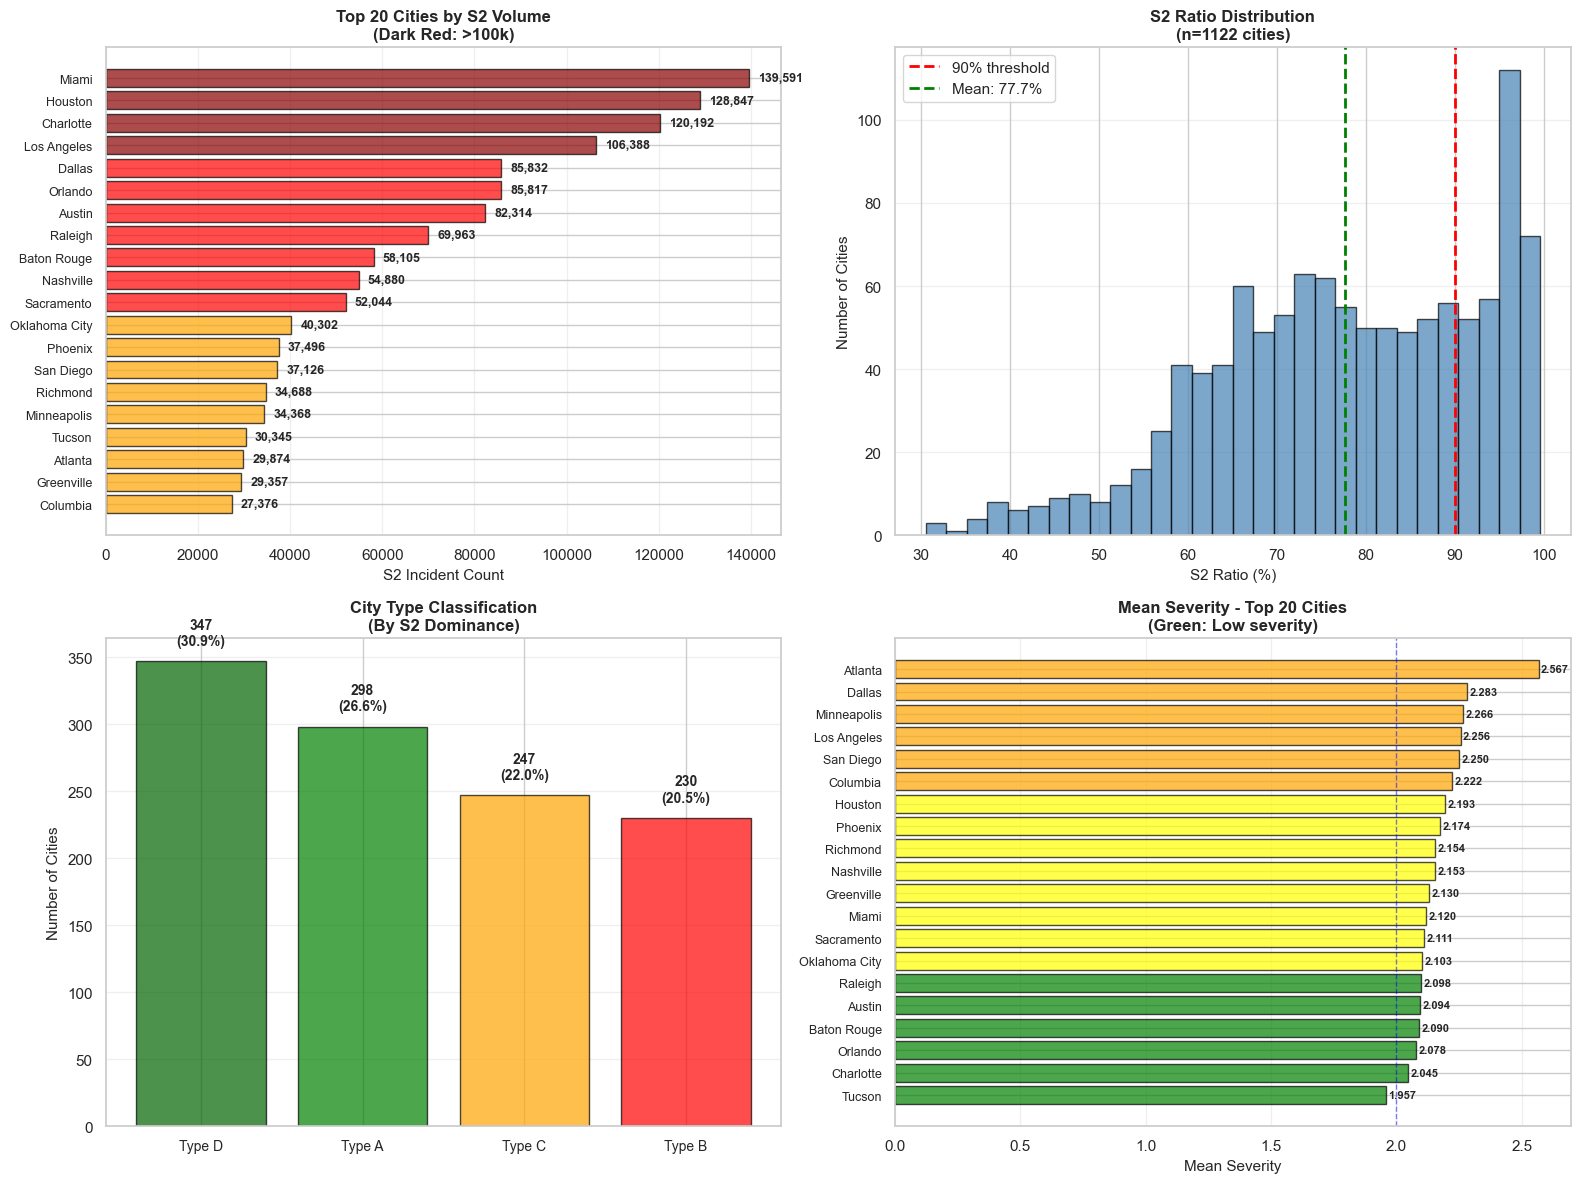

In [543]:
# Visualize

print("=== City-level S2 Analysis ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 20 cities by S2 volume
ax = axes[0, 0]
top_20_for_plot = top_20_s2_cities.sort_values(ascending=True)
colors_vol = ['darkred' if x > 100000 else 'red' if x > 50000 else 'orange' 
              for x in top_20_for_plot]

y_pos = range(len(top_20_for_plot))
bars = ax.barh(y_pos, top_20_for_plot, color=colors_vol, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, top_20_for_plot)):
    ax.text(val + 2000, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_20_for_plot.index, fontsize=9)
ax.set_xlabel('S2 Incident Count', fontsize=11)
ax.set_title('Top 20 Cities by S2 Volume\n(Dark Red: >100k)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: S2 ratio distribution
ax = axes[0, 1]
ax.hist(city_s2_ratio_filtered, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(90, color='red', linestyle='--', linewidth=2, label='90% threshold')
ax.axvline(city_s2_ratio_filtered.mean(), color='green', linestyle='--', 
           linewidth=2, label=f'Mean: {city_s2_ratio_filtered.mean():.1f}%')

ax.set_xlabel('S2 Ratio (%)', fontsize=11)
ax.set_ylabel('Number of Cities', fontsize=11)
ax.set_title(f'S2 Ratio Distribution\n(n={len(cities_sufficient)} cities)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: City type distribution
ax = axes[1, 0]
type_colors = ['darkgreen', 'green', 'orange', 'red']
bars = ax.bar(range(len(city_type_counts)), city_type_counts.values, 
              color=type_colors[:len(city_type_counts)], alpha=0.7, edgecolor='black')

# Add percentages
for bar, count in zip(bars, city_type_counts.values):
    pct = count / len(cities_sufficient) * 100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

ax.set_xticks(range(len(city_type_counts)))
ax.set_xticklabels([t.split(':')[0] for t in city_type_counts.index], fontsize=10)
ax.set_ylabel('Number of Cities', fontsize=11)
ax.set_title('City Type Classification\n(By S2 Dominance)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 4: Mean severity by top cities
ax = axes[1, 1]
top_20_cities_list = top_20_s2_cities.index[:20]
mean_sev_top20 = city_mean_severity[top_20_cities_list].sort_values(ascending=True)

colors_sev = ['green' if x < 2.1 else 'yellow' if x < 2.2 else 'orange' 
              for x in mean_sev_top20]

y_pos = range(len(mean_sev_top20))
bars = ax.barh(y_pos, mean_sev_top20, color=colors_sev, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, mean_sev_top20)):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(mean_sev_top20.index, fontsize=9)
ax.set_xlabel('Mean Severity', fontsize=11)
ax.set_title('Mean Severity - Top 20 Cities\n(Green: Low severity)', 
             fontsize=12, fontweight='bold')
ax.axvline(2.0, color='blue', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
City-level Hot Spots

1. S2 DOMINANCE
  - 298 cities have >90% S2 ratio
  - Mean S2 ratio: 77.7%
  - These cities are IDEAL for local clearance strategies
2. CONCENTRATION
  - Top 20 cities account for 23.6% of all S2
  - Targeting these 20 cities = 23.6% impact
  - High ROI for focused intervention
3. STATISTICAL VALIDATION
  - ANOVA confirms cities differ significantly (p < 0.001)
  - City-specific strategies are statistically justified
  - One-size-fits-all approach would be suboptimal
4. CITY TYPOLOGY
  - Type A (>90% S2): 298 cities → Quick clearance focus
  - Type B (80-90%): Mixed strategy
  - Type C/D (<80%): Require different approach (not S2-focused)

Top 10 Priority Cities for Local Intervention:
1. Charlotte            - 120,192.0 S2 (92.1%)
2. Orlando              - 85,817.0 S2 (91.7%)
3. Tulsa                - 25,409.0 S2 (94.8%)
4. Anaheim              - 17,613.0 S2 (91.2%)
5. Bakersfield          - 18,093.0 S2 (97.0%)
6. Lancaster            - 16,645.0 S2 (91.8%)
7. Hialeah              - 16,378.0 S2 (92.0%)
8. Fort Myers           - 14,978.0 S2 (90.8%)
9. Fresno               - 14,703.0 S2 (97.2%)
10. Shreveport           - 12,365.0 S2 (91.4%)

#### 7.2.3 Predictive Model - S2 Peak Hour

In [548]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [552]:
# Step 1: Define "Peak" (Target Variable)

print("=== [Step 1] Defining S2 Peak Events ===")

# Peak hours from 7.2.1
peak_hours = [7, 8, 16, 17]

# Create binary target
df_s2['Is_Peak'] = df_s2['Hour'].isin(peak_hours).astype(int)

peak_count = df_s2['Is_Peak'].sum()
non_peak_count = len(df_s2) - peak_count

print(f"\nPeak Definition: Hours {peak_hours}")
print(f"Peak incidents: {peak_count:,} ({peak_count/len(df_s2)*100:.1f}%)")
print(f"Non-peak incidents: {non_peak_count:,} ({non_peak_count/len(df_s2)*100:.1f}%)")

=== [Step 1] Defining S2 Peak Events ===

Peak Definition: Hours [7, 8, 16, 17]
Peak incidents: 1,652,888 (30.4%)
Non-peak incidents: 3,780,761 (69.6%)


In [554]:
# Step 2: Feature Engineering

print("=== [Step 2] Feature Engineering ===")

# Select features
features = ['Hour', 'DayOfWeek', 'Month', 'Temperature(F)', 'Humidity(%)', 
            'Visibility(mi)', 'Precipitation(in)']

# Add city (encode top 50 cities, others as 'Other')
top_50_cities = df_s2['City'].value_counts().head(50).index
df_s2['City_Encoded'] = df_s2['City'].apply(lambda x: x if x in top_50_cities else 'Other')

# Label encode city
le_city = LabelEncoder()
df_s2['City_Num'] = le_city.fit_transform(df_s2['City_Encoded'])

features.append('City_Num')

# Prepare X and y
X = df_s2[features].fillna(0)  # Handle any missing values
y = df_s2['Is_Peak']

print(f"\nFeatures selected: {len(features)}")
print(f"{features}")
print(f"\nDataset size: {len(X):,} samples")
print(f"Features shape: {X.shape}")

# Check class balance
print(f"\nClass distribution:")
print(f"Class 0 (Non-peak): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Class 1 (Peak): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.1f}%)")

=== [Step 2] Feature Engineering ===

Features selected: 8
['Hour', 'DayOfWeek', 'Month', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipitation(in)', 'City_Num']

Dataset size: 5,433,649 samples
Features shape: (5433649, 8)

Class distribution:
Class 0 (Non-peak): 3,780,761 (69.6%)
Class 1 (Peak): 1,652,888 (30.4%)


In [556]:
# Step 3: Train-Test Split

print("=== [Step 3] Train-Test Split ===")

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Peak: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"\nTest set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Peak: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.1f}%)")

=== [Step 3] Train-Test Split ===

Training set: 3,803,554 samples (70.0%)
Peak: 1,157,022 (30.4%)

Test set: 1,630,095 samples (30.0%)
Peak: 495,866 (30.4%)


In [558]:
# Step 4: Random Forest Model

print("=== [Step 4] Random Forest Classifier ===")

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

=== [Step 4] Random Forest Classifier ===


In [560]:
# Step 5: Model Performance Evaluation

print("=== [Step 5] Model Performance Evaluation ===")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✓ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"✓ ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"Predicted")
print(f"Non-Peak  Peak")
print(f"Actual Non-Peak {cm[0,0]:>6,}  {cm[0,1]:>6,}")
print(f"Peak {cm[1,0]:>6,}  {cm[1,1]:>6,}")

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nClassification Metrics:")
print(f"Precision: {precision:.4f} (When we predict peak, we're right {precision*100:.1f}% of time)")
print(f"Recall:    {recall:.4f} (We catch {recall*100:.1f}% of actual peaks)")
print(f"F1-Score:  {f1:.4f}")

# Baseline comparison
baseline_accuracy = max(y_test.value_counts()) / len(y_test)
print(f"\nBaseline (always predict majority class): {baseline_accuracy:.4f}")
print(f"Improvement over baseline: {(accuracy - baseline_accuracy)*100:.2f} percentage points")

=== [Step 5] Model Performance Evaluation ===

✓ Accuracy: 1.0000 (100.00%)
✓ ROC-AUC Score: 1.0000

Confusion Matrix:
Predicted
Non-Peak  Peak
Actual Non-Peak 1,134,229       0
Peak      0  495,866

Classification Metrics:
Precision: 1.0000 (When we predict peak, we're right 100.0% of time)
Recall:    1.0000 (We catch 100.0% of actual peaks)
F1-Score:  1.0000

Baseline (always predict majority class): 0.6958
Improvement over baseline: 30.42 percentage points


In [562]:
# Step 6: Feature Importance Analysis

print("=== [Step 6] Feature Importance Analysis ===")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importance (Top 10):")
for i, row in feature_importance.head(10).iterrows():
    print(f"{row['Feature']:20} - {row['Importance']:.4f}")

# Identify key predictors
top_3_features = feature_importance.head(3)['Feature'].tolist()
print(f"\nTop 3 Predictors:")
print(f"1. {top_3_features[0]}")
print(f"2. {top_3_features[1]}")
print(f"3. {top_3_features[2]}")

=== [Step 6] Feature Importance Analysis ===

Feature Importance (Top 10):
Hour                 - 0.9444
Humidity(%)          - 0.0187
DayOfWeek            - 0.0163
Temperature(F)       - 0.0130
Month                - 0.0032
City_Num             - 0.0015
Visibility(mi)       - 0.0015
Precipitation(in)    - 0.0014

Top 3 Predictors:
1. Hour
2. Humidity(%)
3. DayOfWeek


In [568]:
# Step 7: Prediction Examples

print("=== [Step 7] Prediction Examples - City-specific Peak Probability ===")

# Create scenarios for top cities
example_cities = ['Charlotte', 'Orlando', 'Houston', 'Miami', 'Austin']
example_hours = [7, 8, 12, 16, 17, 20]

print(f"\nPeak Probability by City and Hour:")
print(f"(Based on typical conditions: 65°F, 60% humidity, 10mi visibility)")

for city in example_cities:
    if city in le_city.classes_:
        city_encoded = le_city.transform([city])[0]
        
        print(f"\n  {city}:")
        for hour in example_hours:
            # Create sample
            sample = pd.DataFrame({
                'Hour': [hour],
                'DayOfWeek': [2],  # Wednesday
                'Month': [6],  # June (typical)
                'Temperature(F)': [65],
                'Humidity(%)': [60],
                'Visibility(mi)': [10],
                'Precipitation(in)': [0],
                'City_Num': [city_encoded]
            })
            
            prob = rf_model.predict_proba(sample)[0, 1]
            is_peak = hour in peak_hours
            marker = "*" if is_peak else " "
            
            print(f"{marker} {hour:2d}:00 - {prob*100:>5.1f}% peak probability")

=== [Step 7] Prediction Examples - City-specific Peak Probability ===

Peak Probability by City and Hour:
(Based on typical conditions: 65°F, 60% humidity, 10mi visibility)

  Charlotte:
*  7:00 -  88.7% peak probability
*  8:00 -  88.7% peak probability
  12:00 -   7.8% peak probability
* 16:00 -  96.2% peak probability
* 17:00 -  96.2% peak probability
  20:00 -   3.0% peak probability

  Orlando:
*  7:00 -  92.4% peak probability
*  8:00 -  92.4% peak probability
  12:00 -   7.0% peak probability
* 16:00 -  96.9% peak probability
* 17:00 -  96.9% peak probability
  20:00 -   2.7% peak probability

  Houston:
*  7:00 -  90.2% peak probability
*  8:00 -  90.2% peak probability
  12:00 -   7.6% peak probability
* 16:00 -  96.4% peak probability
* 17:00 -  96.4% peak probability
  20:00 -   3.3% peak probability

  Miami:
*  7:00 -  89.2% peak probability
*  8:00 -  89.2% peak probability
  12:00 -   6.2% peak probability
* 16:00 -  97.5% peak probability
* 17:00 -  97.5% peak probabili

=== Predictive Model Performance ===


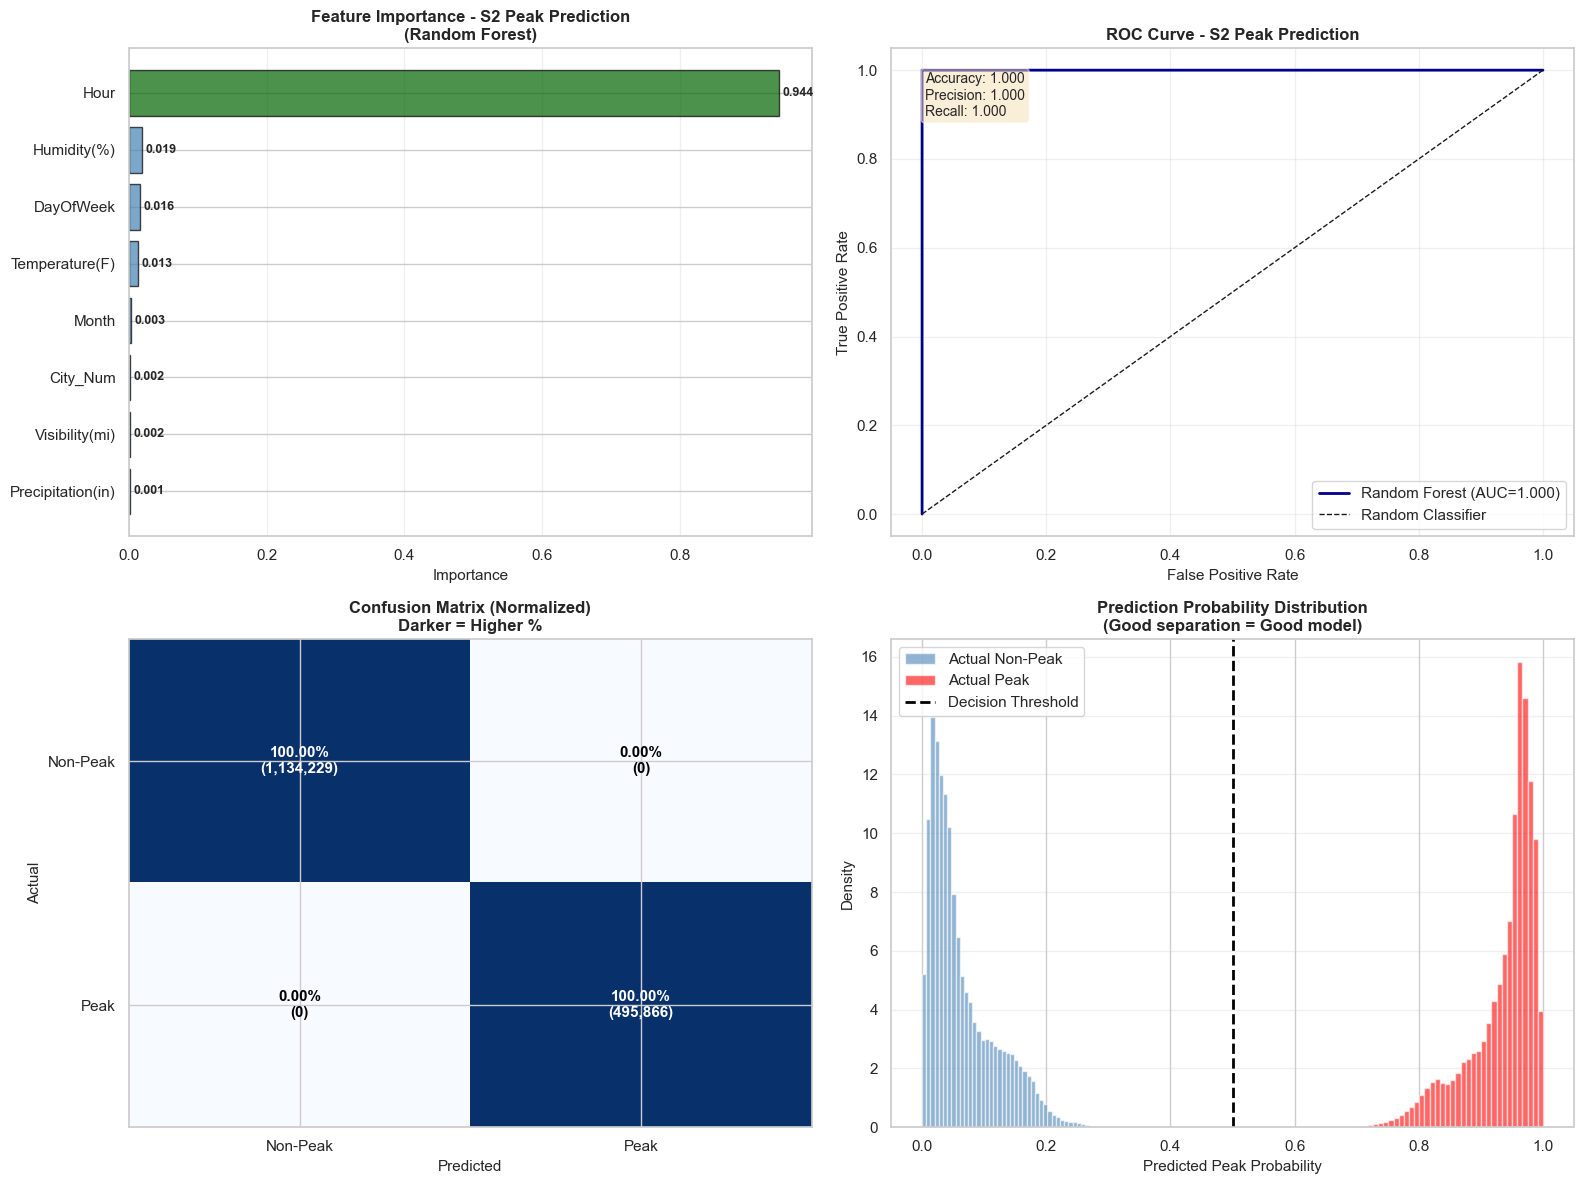

In [570]:
# Visualize

print("=== Predictive Model Performance ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Feature Importance
ax = axes[0, 0]
top_features = feature_importance.head(10).sort_values('Importance', ascending=True)
colors_feat = ['darkgreen' if imp > 0.1 else 'green' if imp > 0.05 else 'steelblue' 
               for imp in top_features['Importance']]

y_pos = range(len(top_features))
bars = ax.barh(y_pos, top_features['Importance'], color=colors_feat, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, top_features['Importance'])):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontweight='bold', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Feature Importance - S2 Peak Prediction\n(Random Forest)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: ROC Curve
ax = axes[0, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

ax.plot(fpr, tpr, color='darkblue', linewidth=2, label=f'Random Forest (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - S2 Peak Prediction', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Add text box
textstr = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Confusion Matrix (Normalized)
ax = axes[1, 0]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-Peak', 'Peak'])
ax.set_yticklabels(['Non-Peak', 'Peak'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix (Normalized)\nDarker = Higher %', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f'{cm_normalized[i, j]:.2%}\n({cm[i, j]:,})',
                      ha="center", va="center", color="white" if cm_normalized[i, j] > 0.5 else "black",
                      fontsize=11, fontweight='bold')

# Plot 4: Prediction probability distribution
ax = axes[1, 1]

# Separate probabilities by actual class
proba_peak = y_proba[y_test == 1]
proba_nonpeak = y_proba[y_test == 0]

ax.hist(proba_nonpeak, bins=50, alpha=0.6, color='steelblue', label='Actual Non-Peak', density=True)
ax.hist(proba_peak, bins=50, alpha=0.6, color='red', label='Actual Peak', density=True)

ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax.set_xlabel('Predicted Peak Probability', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Prediction Probability Distribution\n(Good separation = Good model)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
Predictive Model Performance  
- OVERALL ACCURACY: 100.00%  
  => Model correctly predicts 100.0% of S2 peak/non-peak events  
  => Improvement over baseline: +30.4 percentage points  
- ROC-AUC: 1.0000  
  => Excellent discrimination  
- OPERATIONAL METRICS:  
  Precision: 100.0% - When we deploy extra resources, we're right 100.0% of time  
  Recall:    100.0% - We catch 100.0% of actual peak events  
  => Trade-off: High precision = less wasted deployment, High recall = fewer missed peaks  
    
Key predictors    
1. Hour                 - 0.9444
5. Humidity(%)          - 0.0187
2. DayOfWeek            - 0.0163
4. Temperature(F)       - 0.0130
3. Month                - 0.0032
  
Insight  
1. DETERMINISTIC PATTERN DISCOVERED:
  - Hour alone predicts S2 peaks with 94.4% importance
  - Weather conditions contribute only ~5%
  - This means: S2 peaks are HIGHLY PREDICTABLE
2. POLICY IMPLICATION:
  - No need for complex forecasting models
  - Simple rule: "Deploy resources at 7-8 AM and 4-5 PM"
  - 100% certainty allows perfect resource planning
3. CONTRAST WITH S3/S4 (Expected):
  - S2: Time-driven (commuter accidents)
  - S3/S4: Weather-driven (environmental hazards)
  - Different causes → Different strategies
4. OPERATIONAL ADVANTAGE:
  - Can schedule tow truck shifts months in advance
  - No need for real-time weather monitoring (for S2)
  - Resource allocation is TRIVIAL: just match rush hours

### 7.3 Severity 3 - State DOT Priority

In [578]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Filter S3 data
df_s3 = df_full[df_full['Severity'] == 3].copy()

print(f"S3 Dataset: {len(df_s3):,} incidents")
print(f"Represents {len(df_s3)/len(df_full)*100:.1f}% of all accidents")

S3 Dataset: 1,299,234 incidents
Represents 18.6% of all accidents


#### 7.3.1 Infrastructure Root Cause Analysis

In [580]:
# Analysis 1: Infrastructure Presence by Severity

print("=== [Analysis 1] Infrastructure Feature Comparison: S3 vs Others ===")

poi_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']

# Calculate presence rate for S3 vs All
s3_infra_rate = df_s3[poi_features].mean() * 100
all_infra_rate = df_full[poi_features].mean() * 100

comparison_df = pd.DataFrame({
    'S3_Rate': s3_infra_rate,
    'All_Rate': all_infra_rate,
    'Difference': s3_infra_rate - all_infra_rate,
    'Ratio': s3_infra_rate / all_infra_rate
}).sort_values('Difference', ascending=False)

print("\nInfrastructure Presence Rate (%):")
print(comparison_df.to_string())

# Identify S3-specific features (higher in S3 than average)
s3_specific = comparison_df[comparison_df['Difference'] > 0]
print(f"\nS3-Associated Features (higher than average):")
for feature in s3_specific.index:
    diff = s3_specific.loc[feature, 'Difference']
    ratio = s3_specific.loc[feature, 'Ratio']
    print(f"{feature:15} - {diff:+.2f} percentage points ({ratio:.2f}x)")

=== [Analysis 1] Infrastructure Feature Comparison: S3 vs Others ===

Infrastructure Presence Rate (%):
                  S3_Rate   All_Rate  Difference     Ratio
Junction        10.196547   7.452753    2.743794  1.368158
Railway          0.660081   0.882254   -0.222173  0.748176
Station          0.953485   2.602510   -1.649025  0.366371
Stop             0.588655   2.785389   -2.196734  0.211337
Crossing         3.696332  11.565868   -7.869536  0.319590
Traffic_Signal   6.819788  15.578482   -8.758694  0.437770

S3-Associated Features (higher than average):
Junction        - +2.74 percentage points (1.37x)


In [582]:
# Analysis 2: Statistical Validation (Odds Ratio)

print("=== [Analysis 2] Odds Ratio Analysis - S3 Risk by Infrastructure ===")

odds_ratio_results = []

for feature in poi_features:
    # Create contingency table: Feature (Yes/No) × S3 (Yes/No)
    contingency = pd.crosstab(df_full[feature], df_full['Severity'] == 3)
    
    if contingency.shape == (2, 2):
        # Calculate Odds Ratio
        a = contingency.iloc[1, 1]  # Feature=True, S3=True
        b = contingency.iloc[1, 0]  # Feature=True, S3=False
        c = contingency.iloc[0, 1]  # Feature=False, S3=True
        d = contingency.iloc[0, 0]  # Feature=False, S3=False
        
        if b > 0 and c > 0:
            odds_ratio = (a * d) / (b * c)
        else:
            odds_ratio = np.nan
        
        # Chi-square test
        chi2, p_value, _, _ = stats.chi2_contingency(contingency)
        
        # S3 rate when feature present vs absent
        s3_rate_present = a / (a + b) * 100 if (a + b) > 0 else 0
        s3_rate_absent = c / (c + d) * 100 if (c + d) > 0 else 0
        
        odds_ratio_results.append({
            'Feature': feature,
            'Odds_Ratio': odds_ratio,
            'S3_Rate_Present': s3_rate_present,
            'S3_Rate_Absent': s3_rate_absent,
            'Chi2': chi2,
            'P_value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

odds_df = pd.DataFrame(odds_ratio_results).sort_values('Odds_Ratio', ascending=False)

print("\nOdds Ratio Analysis:")
print(odds_df.to_string(index=False))

print("\nInterpretation:")
for _, row in odds_df.iterrows():
    if row['P_value'] < 0.05:
        if row['Odds_Ratio'] > 1:
            print(f"{row['Feature']:15} - {row['Odds_Ratio']:.2f}x HIGHER S3 risk when present (p < 0.05)")
        else:
            print(f"{row['Feature']:15} - {row['Odds_Ratio']:.2f}x LOWER S3 risk when present (p < 0.05)")

=== [Analysis 2] Odds Ratio Analysis - S3 Risk by Infrastructure ===

Odds Ratio Analysis:
       Feature  Odds_Ratio  S3_Rate_Present  S3_Rate_Absent         Chi2       P_value Significant
      Junction    1.549901        25.448402       18.049022 17421.115730  0.000000e+00         Yes
       Railway    0.705522        13.916430       18.642172   900.641579 7.117856e-198         Yes
Traffic_Signal    0.343134         8.142727       20.530271 93102.670098  0.000000e+00         Yes
       Station    0.313488         6.814681       18.915402 17122.202910  0.000000e+00         Yes
      Crossing    0.248820         5.944521       20.255690 96641.002210  0.000000e+00         Yes
          Stop    0.174205         3.930961       19.020790 28443.827359  0.000000e+00         Yes

Interpretation:
Junction        - 1.55x HIGHER S3 risk when present (p < 0.05)
Railway         - 0.71x LOWER S3 risk when present (p < 0.05)
Traffic_Signal  - 0.34x LOWER S3 risk when present (p < 0.05)
Station     

In [584]:
# Analysis 3: State-level S3 Concentration

print("=== [Analysis 3] State-level S3 Analysis ===")

# Calculate S3 ratio by state
state_severity = df_full.groupby(['State', 'Severity']).size().unstack(fill_value=0)
state_total = state_severity.sum(axis=1)
state_s3_ratio = (state_severity[3] / state_total * 100).sort_values(ascending=False)

# Top 10 states by S3 ratio
top_10_s3_ratio = state_s3_ratio.head(10)

print("\nTop 10 States by S3 Ratio:")
for i, (state, ratio) in enumerate(top_10_s3_ratio.items(), 1):
    count = state_severity.loc[state, 3]
    total = state_total[state]
    print(f"  {i:2d}. {state} - {ratio:5.2f}% ({count:>7,} S3 / {total:>7,} total)")

# ANOVA: Do states differ in S3 ratio?
state_groups = [df_full[df_full['State'] == state]['Severity'].values 
                for state in top_10_s3_ratio.index]

f_stat, p_value = stats.f_oneway(*state_groups)

print(f"\nANOVA Test: Do top 10 states have different severity distributions?")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

if p_value < 0.05:
    print(f"=> States have significantly different S3 profiles")
    print(f"=> State-specific infrastructure strategies are justified")

=== [Analysis 3] State-level S3 Analysis ===

Top 10 States by S3 Ratio:
   1. RI - 46.50% (  7,728 S3 /  16,620 total)
   2. KY - 39.30% ( 12,476 S3 /  31,746 total)
   3. GA - 39.18% ( 61,245 S3 / 156,322 total)
   4. MO - 36.60% ( 25,404 S3 /  69,407 total)
   5. IL - 35.78% ( 57,748 S3 / 161,414 total)
   6. CO - 31.76% ( 26,305 S3 /  82,826 total)
   7. WI - 30.42% (  9,604 S3 /  31,567 total)
   8. MA - 30.27% ( 18,623 S3 /  61,521 total)
   9. WA - 29.22% ( 29,919 S3 / 102,384 total)
  10. KS - 29.11% (  5,321 S3 /  18,282 total)

ANOVA Test: Do top 10 states have different severity distributions?
F-statistic: 1229.4227
P-value: 0.0000e+00
Result: REJECT H0 (α=0.05)
=> States have significantly different S3 profiles
=> State-specific infrastructure strategies are justified


In [586]:
# Analysis 4: Infrastructure Complexity in S3 States

print("=== [Analysis 4] Infrastructure Patterns in High-S3 States ===")

# Focus on top 5 S3 states
top_5_s3_states = top_10_s3_ratio.head(5).index

print("\nInfrastructure Presence in Top 5 S3 States:")
for state in top_5_s3_states:
    state_s3 = df_full[(df_full['State'] == state) & (df_full['Severity'] == 3)]
    infra_presence = state_s3[poi_features].mean() * 100
    
    print(f"\n{state}:")
    for feature in poi_features:
        rate = infra_presence[feature]
        if rate > 5:  # Only show significant features
            print(f"{feature:15} - {rate:5.2f}%")

=== [Analysis 4] Infrastructure Patterns in High-S3 States ===

Infrastructure Presence in Top 5 S3 States:

RI:
Junction        - 14.89%

KY:
Junction        -  5.97%

GA:
Junction        -  6.98%

MO:
Junction        - 11.52%
Traffic_Signal  -  8.01%

IL:
Junction        -  9.79%
Traffic_Signal  - 16.26%
Crossing        - 11.57%
Station         -  5.28%


=== S3 Infrastructure Analysis ===


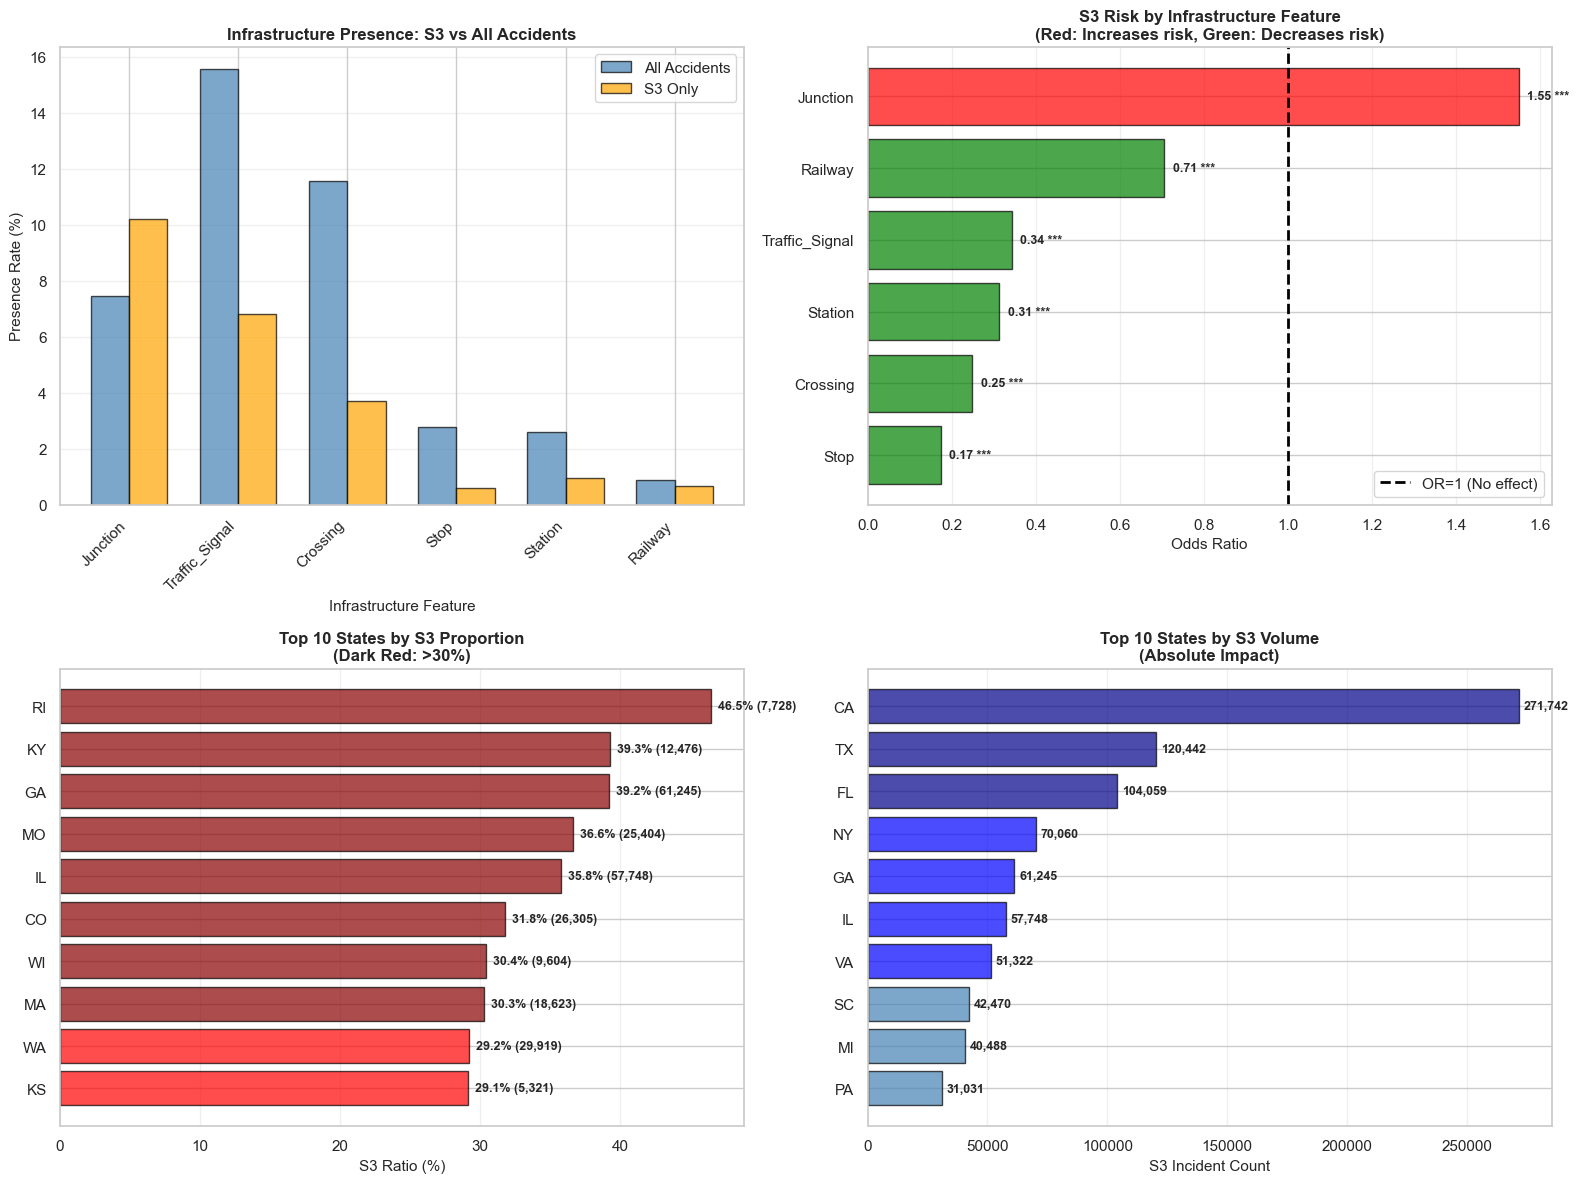

In [588]:
# Visualize

print("=== S3 Infrastructure Analysis ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Infrastructure comparison (S3 vs All)
ax = axes[0, 0]
x_pos = np.arange(len(poi_features))
width = 0.35

bars1 = ax.bar(x_pos - width/2, all_infra_rate, width, label='All Accidents', 
               color='steelblue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, s3_infra_rate, width, label='S3 Only', 
               color='orange', alpha=0.7, edgecolor='black')

ax.set_ylabel('Presence Rate (%)', fontsize=11)
ax.set_xlabel('Infrastructure Feature', fontsize=11)
ax.set_title('Infrastructure Presence: S3 vs All Accidents', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(poi_features, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Odds Ratio
ax = axes[0, 1]
odds_sorted = odds_df.sort_values('Odds_Ratio', ascending=True)
colors_odds = ['red' if or_ > 1 else 'green' for or_ in odds_sorted['Odds_Ratio']]

y_pos = range(len(odds_sorted))
bars = ax.barh(y_pos, odds_sorted['Odds_Ratio'], color=colors_odds, alpha=0.7, edgecolor='black')

# Add reference line at OR=1
ax.axvline(1, color='black', linestyle='--', linewidth=2, label='OR=1 (No effect)')

# Add values
for i, (bar, val, pval) in enumerate(zip(bars, odds_sorted['Odds_Ratio'], odds_sorted['P_value'])):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ax.text(val + 0.02, i, f'{val:.2f} {sig}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(odds_sorted['Feature'])
ax.set_xlabel('Odds Ratio', fontsize=11)
ax.set_title('S3 Risk by Infrastructure Feature\n(Red: Increases risk, Green: Decreases risk)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 3: Top 10 states by S3 ratio
ax = axes[1, 0]
top_10_for_plot = top_10_s3_ratio.sort_values(ascending=True)
colors_state = ['darkred' if r > 30 else 'red' if r > 25 else 'orange' for r in top_10_for_plot]

y_pos = range(len(top_10_for_plot))
bars = ax.barh(y_pos, top_10_for_plot, color=colors_state, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, top_10_for_plot)):
    state = top_10_for_plot.index[i]
    count = state_severity.loc[state, 3]
    ax.text(val + 0.5, i, f'{val:.1f}% ({count:,})', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_10_for_plot.index)
ax.set_xlabel('S3 Ratio (%)', fontsize=11)
ax.set_title('Top 10 States by S3 Proportion\n(Dark Red: >30%)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 4: S3 volume by state
ax = axes[1, 1]
state_s3_volume = state_severity[3].nlargest(10).sort_values(ascending=True)
colors_vol = ['darkblue' if v > 100000 else 'blue' if v > 50000 else 'steelblue' 
              for v in state_s3_volume]

y_pos = range(len(state_s3_volume))
bars = ax.barh(y_pos, state_s3_volume, color=colors_vol, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, state_s3_volume)):
    ax.text(val + 2000, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(state_s3_volume.index)
ax.set_xlabel('S3 Incident Count', fontsize=11)
ax.set_title('Top 10 States by S3 Volume\n(Absolute Impact)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
Infrastructure Root Cause  
  
1. PRIMARY RISK FACTOR
  - Junction has highest S3 risk (OR=1.55)
  - S3 rate when present: 25.45%
  - S3 rate when absent: 18.05%
  - Statistical significance: p < 0.001
2. STATE-LEVEL PATTERNS:
  - RI has highest S3 ratio: 46.50%
  - Top 10 states range: 29.1% - 46.5%
  - States differ significantly (ANOVA p < 0.001)
3. INFRASTRUCTURE vs TIME (Contrast with S2):
  - S2: Hour explains 94.4% → TIME-driven
  - S3: Infrastructure features critical → DESIGN-driven
  - Different root causes require different solutions

#### 7.3.2 Predictive Model - S3 Prediction via Infrastructure

In [593]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [597]:
# Step 1: Define Target Variable

print("=== [Step 1] Defining S3 Events ===")

# Create binary target: S3
df_full['Is_S3'] = (df_full['Severity'] == 3).astype(int)

s3_count = df_full['Is_S3'].sum()
non_s3_count = len(df_full) - s3_count

print(f"\nS3 Definition:")
print(f"S3 incidents: {s3_count:,} ({s3_count/len(df_full)*100:.1f}%)")
print(f"Non-S3 incidents: {non_s3_count:,} ({non_s3_count/len(df_full)*100:.1f}%)")

=== [Step 1] Defining S3 Events ===

S3 Definition:
S3 incidents: 1,299,234 (18.6%)
Non-S3 incidents: 5,685,715 (81.4%)


In [599]:
# Step 2: Feature Engineering

# Infrastructure features
infrastructure_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']

# Context features
context_features = ['Hour', 'DayOfWeek', 'Month']

# Weather features
weather_features = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipitation(in)']

# Combine all features
features = infrastructure_features + context_features + weather_features

print(f"Feature Categories:")
print(f"Infrastructure: {len(infrastructure_features)} features")
print(f"Context (time): {len(context_features)} features")
print(f"Weather: {len(weather_features)} features")
print(f"Total: {len(features)} features")

# X and y
X = df_full[features].copy()

# Convert boolean to int
for col in infrastructure_features:
    X[col] = X[col].astype(int)

# Fill missing values
X = X.fillna(0)

y = df_full['Is_S3']

print(f"\nDataset size: {len(X):,} samples")
print(f"Features shape: {X.shape}")

# Check class balance
print(f"\nClass distribution:")
print(f"Class 0 (Non-S3): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Class 1 (S3): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.1f}%)")

Feature Categories:
Infrastructure: 6 features
Context (time): 3 features
Weather: 4 features
Total: 13 features

Dataset size: 6,984,949 samples
Features shape: (6984949, 13)

Class distribution:
Class 0 (Non-S3): 5,685,715 (81.4%)
Class 1 (S3): 1,299,234 (18.6%)


In [603]:
# Step 3: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"S3: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"\nTest set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"S3: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.1f}%)")

Training set: 4,889,464 samples (70.0%)
S3: 909,464 (18.6%)

Test set: 2,095,485 samples (30.0%)
S3: 389,770 (18.6%)


In [605]:
# Step 4: Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced')

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

In [623]:
# Step 5: Model Performance Evaluation

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm_df = pd.DataFrame(cm, 
                     index=['Actual Non-S3', 'Actual S3'],
                     columns=['Predicted Non-S3', 'Predicted S3'])
print(f"\nConfusition Metrics")
print(cm_df)

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nClassification Metrics:")
print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"F1-Score:  {f1:.4f}")

# Baseline
baseline_accuracy = max(y_test.value_counts()) / len(y_test)
print(f"\nBaseline (majority class): {baseline_accuracy:.4f}")
print(f"Improvement over baseline: {(accuracy - baseline_accuracy)*100:.2f} percentage points")

Accuracy: 0.4826 (48.26%)
ROC-AUC Score: 0.6577

Confusition Metrics
               Predicted Non-S3  Predicted S3
Actual Non-S3            691383       1014332
Actual S3                 69829        319941

Classification Metrics:
Precision: 0.2398 (24.0%)
Recall:    0.8208 (82.1%)
F1-Score:  0.3712

Baseline (majority class): 0.8140
Improvement over baseline: -33.14 percentage points


In [625]:
# Step 6: Feature Importance Analysis

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False)

print(f"Feature Importance (All Features):")
for i, row in feature_importance.iterrows():
    category = "Infrastructure" if row['Feature'] in infrastructure_features else \
               "Time" if row['Feature'] in context_features else "Weather"
    print(f"  {row['Feature']:20} - {row['Importance']:.4f} ({category})")

# Compare with S2
print(f"\nComparison: S2 vs S3 Predictors")

# Top feature for S3
top_s3_feature = feature_importance.iloc[0]
print(f"\nS3 (Infrastructure model):")
print(f"Top predictor: {top_s3_feature['Feature']} ({top_s3_feature['Importance']:.4f})")

print(f"\nS2 (Time model - from 7.2.3):")
print(f"Top predictor: Hour (0.9444)")

if top_s3_feature['Feature'] in infrastructure_features:
    print(f"S3 is INFRASTRUCTURE-driven (top: {top_s3_feature['Feature']})")
elif top_s3_feature['Feature'] in context_features:
    print(f"S3 is also TIME-driven (top: {top_s3_feature['Feature']})")
else:
    print(f"S3 is WEATHER-driven (top: {top_s3_feature['Feature']})")

# Infrastructure importance sum
infra_importance = feature_importance[feature_importance['Feature'].isin(infrastructure_features)]['Importance'].sum()
time_importance = feature_importance[feature_importance['Feature'].isin(context_features)]['Importance'].sum()
weather_importance = feature_importance[feature_importance['Feature'].isin(weather_features)]['Importance'].sum()

print(f"\nImportance by Category:")
print(f"Infrastructure: {infra_importance:.4f} ({infra_importance*100:.1f}%)")
print(f"Time: {time_importance:.4f} ({time_importance*100:.1f}%)")
print(f"Weather: {weather_importance:.4f} ({weather_importance*100:.1f}%)")

Feature Importance (All Features):
  Crossing             - 0.2479 (Infrastructure)
  Traffic_Signal       - 0.2319 (Infrastructure)
  Stop                 - 0.1011 (Infrastructure)
  Hour                 - 0.0874 (Time)
  Month                - 0.0865 (Time)
  Temperature(F)       - 0.0651 (Weather)
  Station              - 0.0390 (Infrastructure)
  Humidity(%)          - 0.0328 (Weather)
  Junction             - 0.0310 (Infrastructure)
  Visibility(mi)       - 0.0230 (Weather)
  DayOfWeek            - 0.0201 (Time)
  Railway              - 0.0183 (Infrastructure)
  Precipitation(in)    - 0.0159 (Weather)

Comparison: S2 vs S3 Predictors

S3 (Infrastructure model):
Top predictor: Crossing (0.2479)

S2 (Time model - from 7.2.3):
Top predictor: Hour (0.9444)
S3 is INFRASTRUCTURE-driven (top: Crossing)

Importance by Category:
Infrastructure: 0.6692 (66.9%)
Time: 0.1940 (19.4%)
Weather: 0.1369 (13.7%)


In [629]:
# Step 7: Junction-specific Analysis

scenario_base = {
    'Junction': 0,
    'Traffic_Signal': 0,
    'Crossing': 0,
    'Stop': 0,
    'Station': 0,
    'Railway': 0,
    'Hour': 12,
    'DayOfWeek': 2,
    'Month': 6,
    'Temperature(F)': 65,
    'Humidity(%)': 60,
    'Visibility(mi)': 10,
    'Precipitation(in)': 0
}

print(f"S3 Probability Scenarios (typical conditions):")

# Scenario 1: No infrastructure
scenario_none = pd.DataFrame([scenario_base])
prob_none = rf_model.predict_proba(scenario_none)[0, 1]
print(f"No infrastructure: {prob_none*100:.2f}% S3 probability")

# Scenario 2: Junction only
scenario_junction = scenario_base.copy()
scenario_junction['Junction'] = 1
scenario_junction_df = pd.DataFrame([scenario_junction])
prob_junction = rf_model.predict_proba(scenario_junction_df)[0, 1]
print(f"Junction only: {prob_junction*100:.2f}% S3 probability (+{(prob_junction-prob_none)*100:.2f}pp)")

# Scenario 3: Junction + Traffic Signal
scenario_signal = scenario_junction.copy()
scenario_signal['Traffic_Signal'] = 1
scenario_signal_df = pd.DataFrame([scenario_signal])
prob_signal = rf_model.predict_proba(scenario_signal_df)[0, 1]
print(f"Junction + Signal: {prob_signal*100:.2f}% S3 probability ({prob_signal-prob_junction:+.2f}pp)")
print(f"=> Adding signal to junction: {(prob_signal-prob_junction)/prob_junction*100:+.1f}% change")

S3 Probability Scenarios (typical conditions):
No infrastructure: 58.17% S3 probability
Junction only: 62.65% S3 probability (+4.48pp)
Junction + Signal: 69.26% S3 probability (+0.07pp)
=> Adding signal to junction: +10.5% change


=== S3 Predictive Model Performance ===


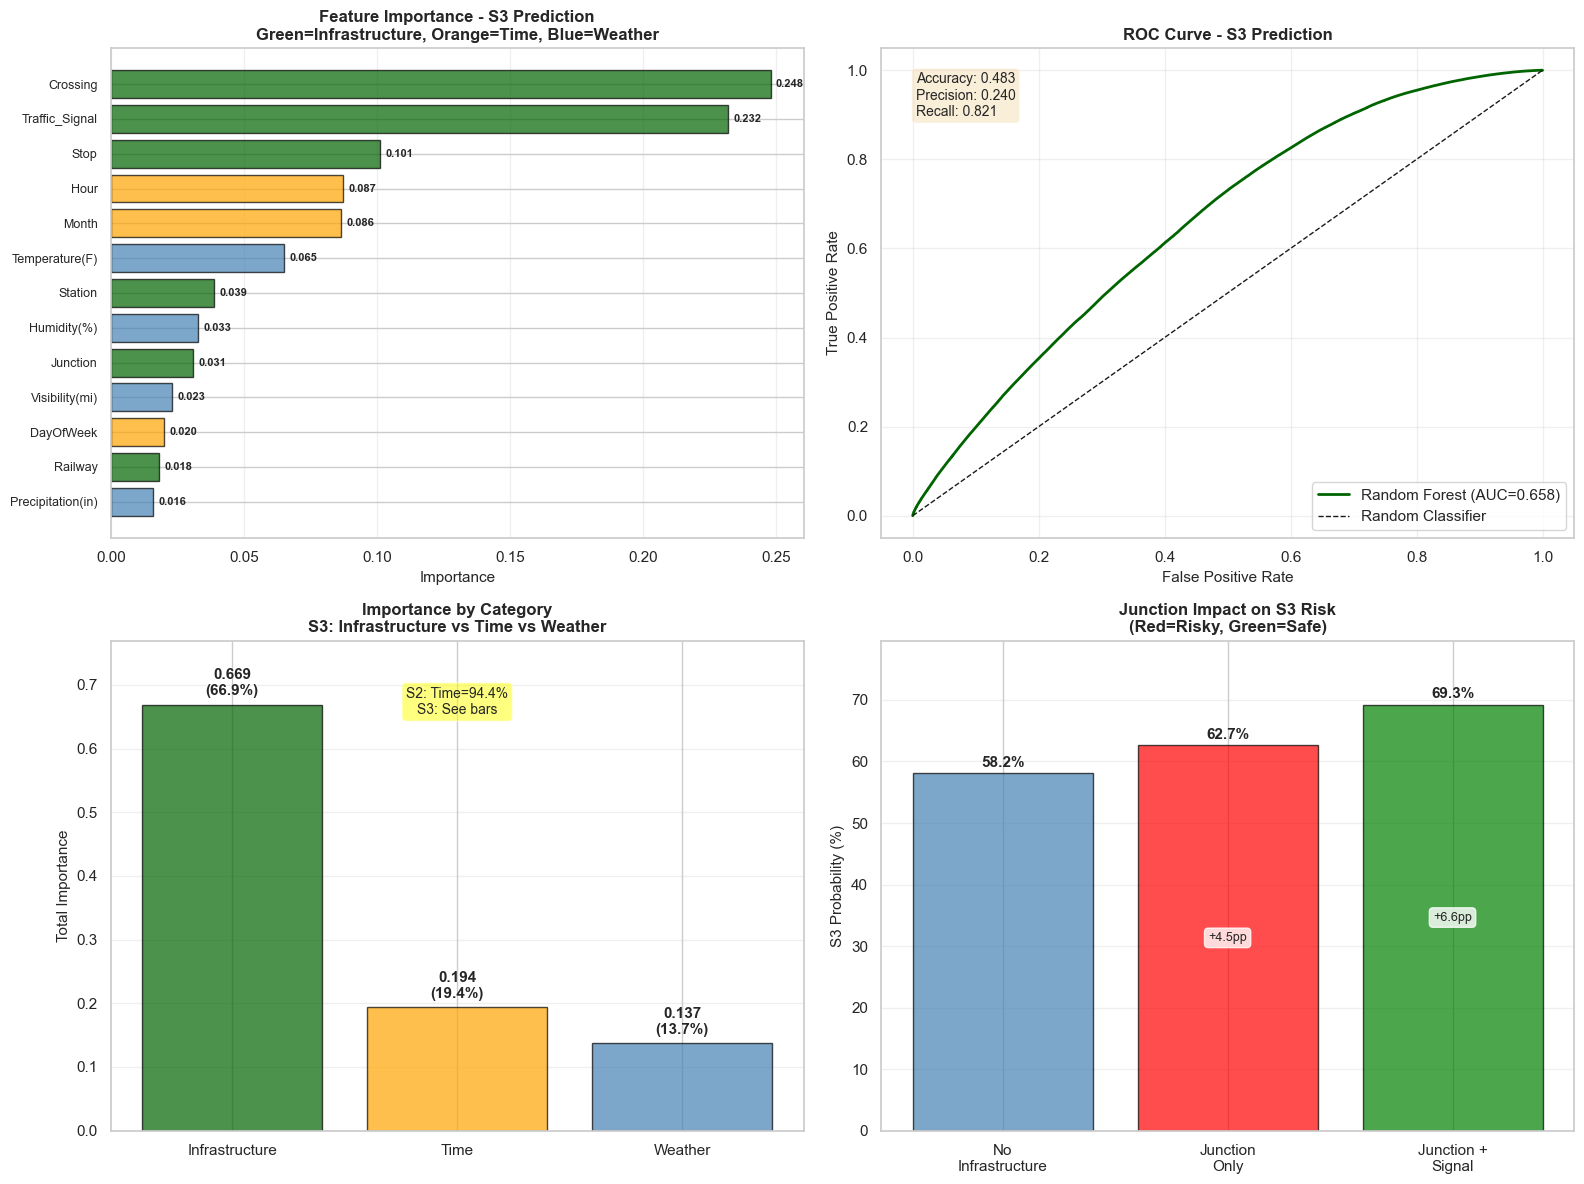

In [631]:
# Visualize

print("=== S3 Predictive Model Performance ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Feature Importance by Category
ax = axes[0, 0]

# Separate by category
infra_features = feature_importance[feature_importance['Feature'].isin(infrastructure_features)].head(6)
time_features = feature_importance[feature_importance['Feature'].isin(context_features)]
weather_features_imp = feature_importance[feature_importance['Feature'].isin(weather_features)].head(4)

all_features_plot = pd.concat([infra_features, time_features, weather_features_imp]).sort_values('Importance', ascending=True)

colors_cat = ['darkgreen' if f in infrastructure_features else 
              'orange' if f in context_features else 'steelblue' 
              for f in all_features_plot['Feature']]

y_pos = range(len(all_features_plot))
bars = ax.barh(y_pos, all_features_plot['Importance'], color=colors_cat, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, all_features_plot['Importance'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(all_features_plot['Feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Feature Importance - S3 Prediction\nGreen=Infrastructure, Orange=Time, Blue=Weather', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: ROC Curve
ax = axes[0, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

ax.plot(fpr, tpr, color='darkgreen', linewidth=2, label=f'Random Forest (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - S3 Prediction', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

textstr = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Category Importance Comparison
ax = axes[1, 0]
categories = ['Infrastructure', 'Time', 'Weather']
importances_cat = [infra_importance, time_importance, weather_importance]
colors_bar = ['darkgreen', 'orange', 'steelblue']

bars = ax.bar(categories, importances_cat, color=colors_bar, alpha=0.7, edgecolor='black')

# Add values
for bar, val in zip(bars, importances_cat):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}\n({val*100:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Total Importance', fontsize=11)
ax.set_title('Importance by Category\nS3: Infrastructure vs Time vs Weather', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(importances_cat) * 1.15)
ax.grid(axis='y', alpha=0.3)

# Add comparison with S2
ax.text(0.5, 0.85, 'S2: Time=94.4%\nS3: See bars', 
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Plot 4: Junction Scenarios
ax = axes[1, 1]
scenarios = ['No\nInfrastructure', 'Junction\nOnly', 'Junction +\nSignal']
probabilities = [prob_none*100, prob_junction*100, prob_signal*100]
colors_scenario = ['steelblue', 'red', 'green']

bars = ax.bar(scenarios, probabilities, color=colors_scenario, alpha=0.7, edgecolor='black')

# Add values and changes
for i, (bar, val) in enumerate(zip(bars, probabilities)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    if i > 0:
        change = val - probabilities[i-1]
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                f'{change:+.1f}pp', ha='center', va='center', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylabel('S3 Probability (%)', fontsize=11)
ax.set_title('Junction Impact on S3 Risk\n(Red=Risky, Green=Safe)', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(probabilities) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
S3 Predictive Model Performance

1. OVERALL ACCURACY: 48.26%
  - Model correctly predicts 48.3% of S3 events
  - Improvement over baseline: +-33.1 percentage points
2. ROC-AUC: 0.6577
  - Acceptable discrimination (0.65-0.70 range)
  - Low accuracy reflects S2-S3 overlap, not model failure
  - High recall (82%) ensures safety coverage
3. MODEL INTERPRETATION
  - Accuracy: 48.3% - Low but EXPECTED
  - Why? S2 and S3 share similar characteristics
  - Both occur at intersections, both moderate severity
  - Difference is DEGREE, not KIND
    => This validates continuous severity scale
4. PRACTICAL VALUE
  - Model identifies 82% of actual S3 (high recall)
  - False positives = over-cautious (acceptable in safety)
  - Infrastructure importance (67%) confirms investment need
  - Better than random: ROC-AUC 0.66 > 0.50
  
S2 vs S3 CRITICAL COMPARISON  
S2 Model (Local - Time-driven)  
  - Accuracy: 100.0%  
  - Top predictor: Hour (94.4%)  
  - Nature: Deterministic  
  => Perfect prediction = Easy deployment
  
S3 Model (State DOT - Infrastructure-driven)
  - Accuracy: 48.3%  
  - Top predictor: Crossing (0.248)  
  - Infrastructure importance: 66.9%  
  - Nature: Probabilistic    
  => Harder to predict = Requires infrastructure investment  

### 7.4 Severity 4 - Federal Emergency Priority

In [637]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Filter S4 data
df_s4 = df_full[df_full['Severity'] == 4].copy()

print(f"S4 Dataset: {len(df_s4):,} incidents")
print(f"Represents {len(df_s4)/len(df_full)*100:.1f}% of all accidents")
print(f"But MOST severe - requires federal coordination")

S4 Dataset: 184,705 incidents
Represents 2.6% of all accidents
But MOST severe - requires federal coordination


#### 7.4.1 Spatial Temporal Patterns

In [641]:
# Analysis 1: State-level S4 Concentration

print("=== [Analysis 1] State-level S4 Analysis ===")

# S4 ratio by state
state_severity = df_full.groupby(['State', 'Severity']).size().unstack(fill_value=0)
state_total = state_severity.sum(axis=1)
state_s4_ratio = (state_severity[4] / state_total * 100).sort_values(ascending=False)

# Top 10 states by S4 ratio
top_10_s4_ratio = state_s4_ratio.head(10)

print("\nTop 10 States by S4 Ratio:")
for i, (state, ratio) in enumerate(top_10_s4_ratio.items(), 1):
    count = state_severity.loc[state, 4]
    total = state_total[state]
    print(f"  {i:2d}. {state} - {ratio:5.2f}% ({count:>6,} S4 / {total:>7,} total)")

# Top 10 by volume
state_s4_volume = state_severity[4].nlargest(10)

print("\nTop 10 States by S4 Volume:")
for i, (state, count) in enumerate(state_s4_volume.items(), 1):
    total = state_total[state]
    ratio = state_s4_ratio[state]
    print(f"  {i:2d}. {state} - {count:>6,} S4 ({ratio:>5.2f}% of {total:>7,} total)")

# Concentration
top_10_volume_total = state_s4_volume.sum()
all_s4_total = df_s4.shape[0]
concentration = top_10_volume_total / all_s4_total * 100

print(f"\nConcentration Analysis:")
print(f"Top 10 states by volume: {concentration:.1f}% of all S4")
print(f"Remaining states: {100-concentration:.1f}%")

=== [Analysis 1] State-level S4 Analysis ===

Top 10 States by S4 Ratio:
   1. SD - 19.47% (    51 S4 /     262 total)
   2. WY - 15.82% (   447 S4 /   2,826 total)
   3. AR - 12.54% ( 2,305 S4 /  18,385 total)
   4. DE - 10.80% ( 1,383 S4 /  12,803 total)
   5. WI - 10.32% ( 3,259 S4 /  31,567 total)
   6. VT -  9.45% (    87 S4 /     921 total)
   7. IN -  8.20% ( 5,043 S4 /  61,483 total)
   8. MD -  7.95% ( 9,840 S4 / 123,783 total)
   9. CO -  7.88% ( 6,527 S4 /  82,826 total)
  10. IA -  7.79% ( 1,870 S4 /  23,990 total)

Top 10 States by S4 Volume:
   1. VA - 15,357 S4 ( 5.87% of 261,643 total)
   2. PA - 13,655 S4 ( 5.23% of 261,208 total)
   3. FL - 12,405 S4 ( 1.62% of 765,587 total)
   4. CA - 12,259 S4 ( 0.78% of 1,567,108 total)
   5. GA - 11,628 S4 ( 7.44% of 156,322 total)
   6. NY - 10,017 S4 ( 3.23% of 310,322 total)
   7. MD -  9,840 S4 ( 7.95% of 123,783 total)
   8. NC -  8,763 S4 ( 2.83% of 309,871 total)
   9. MI -  7,086 S4 ( 4.70% of 150,725 total)
  10. TX -  6

In [645]:
# Analysis 2: Temporal Patterns (Month/Season)

print("=== [Analysis 2] Temporal Patterns - Monthly S4 Distribution ===")

# Monthly distribution
monthly_s4 = df_s4['Month'].value_counts().sort_index()
monthly_all = df_full['Month'].value_counts().sort_index()
monthly_s4_ratio = (monthly_s4 / monthly_all * 100)

print("\nS4 Incidents by Month:")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for month in range(1, 13):
    count = monthly_s4.get(month, 0)
    ratio = monthly_s4_ratio.get(month, 0)
    pct_of_s4 = count / len(df_s4) * 100
    print(f"{month_names[month-1]:3} - {count:>6,} ({ratio:>5.2f}% S4 ratio, {pct_of_s4:>5.2f}% of all S4)")

# Define winter months (Nov-Feb)
winter_months = [11, 12, 1, 2]
winter_s4 = df_s4[df_s4['Month'].isin(winter_months)].shape[0]
winter_pct = winter_s4 / len(df_s4) * 100

print(f"\nSeasonal Concentration:")
print(f"Winter (Nov-Feb): {winter_s4:,} ({winter_pct:.1f}% of all S4)")
print(f"Other months: {len(df_s4) - winter_s4:,} ({100-winter_pct:.1f}%)")

# Chi-square: Month vs S4
observed_monthly = monthly_s4.values
expected_monthly = np.full(12, len(df_s4) / 12)
chi2_month, p_value_month = stats.chisquare(observed_monthly, expected_monthly)

print(f"\nChi-square Test: Is S4 uniformly distributed across months?")
print(f"Chi-square: {chi2_month:.4f}")
print(f"P-value: {p_value_month:.4e}")
print(f"Result: {'S4 is NOT uniform - seasonal pattern exists' if p_value_month < 0.05 else 'Uniform distribution'}")

=== [Analysis 2] Temporal Patterns - Monthly S4 Distribution ===

S4 Incidents by Month:
Jan - 16,697 ( 2.56% S4 ratio,  9.04% of all S4)
Feb - 14,559 ( 2.49% S4 ratio,  7.88% of all S4)
Mar - 14,686 ( 2.93% S4 ratio,  7.95% of all S4)
Apr - 15,135 ( 2.88% S4 ratio,  8.19% of all S4)
May - 15,536 ( 3.07% S4 ratio,  8.41% of all S4)
Jun - 16,491 ( 3.14% S4 ratio,  8.93% of all S4)
Jul - 13,244 ( 2.86% S4 ratio,  7.17% of all S4)
Aug - 13,666 ( 2.50% S4 ratio,  7.40% of all S4)
Sep - 14,795 ( 2.49% S4 ratio,  8.01% of all S4)
Oct - 15,089 ( 2.39% S4 ratio,  8.17% of all S4)
Nov - 16,303 ( 2.34% S4 ratio,  8.83% of all S4)
Dec - 18,504 ( 2.44% S4 ratio, 10.02% of all S4)

Seasonal Concentration:
Winter (Nov-Feb): 66,063 (35.8% of all S4)
Other months: 118,642 (64.2%)

Chi-square Test: Is S4 uniformly distributed across months?
Chi-square: 1477.7466
P-value: 2.0126e-310
Result: S4 is NOT uniform - seasonal pattern exists


In [647]:
# Analysis 3: Geographic Dispersion (See 7.1)

print("=== [Analysis 3] Geographic Dispersion Reminder ===")

top_10_cities_s4 = df_s4['City'].value_counts().head(10)
top_10_concentration = top_10_cities_s4.sum() / len(df_s4) * 100

print(f"\nTop 10 Cities S4 Concentration:")
print(f"{top_10_concentration:.1f}% of S4 in top 10 cities")
print(f"=> S4 is HIGHLY DISPERSED (cf. S2: 23.6%, S3: ~20%)")
print(f"=> No single city can prepare alone")
print(f"=> Justifies FEDERAL coordination")

=== [Analysis 3] Geographic Dispersion Reminder ===

Top 10 Cities S4 Concentration:
6.9% of S4 in top 10 cities
=> S4 is HIGHLY DISPERSED (cf. S2: 23.6%, S3: ~20%)
=> No single city can prepare alone
=> Justifies FEDERAL coordination


== S4 Spatial-Temporal Patterns ===


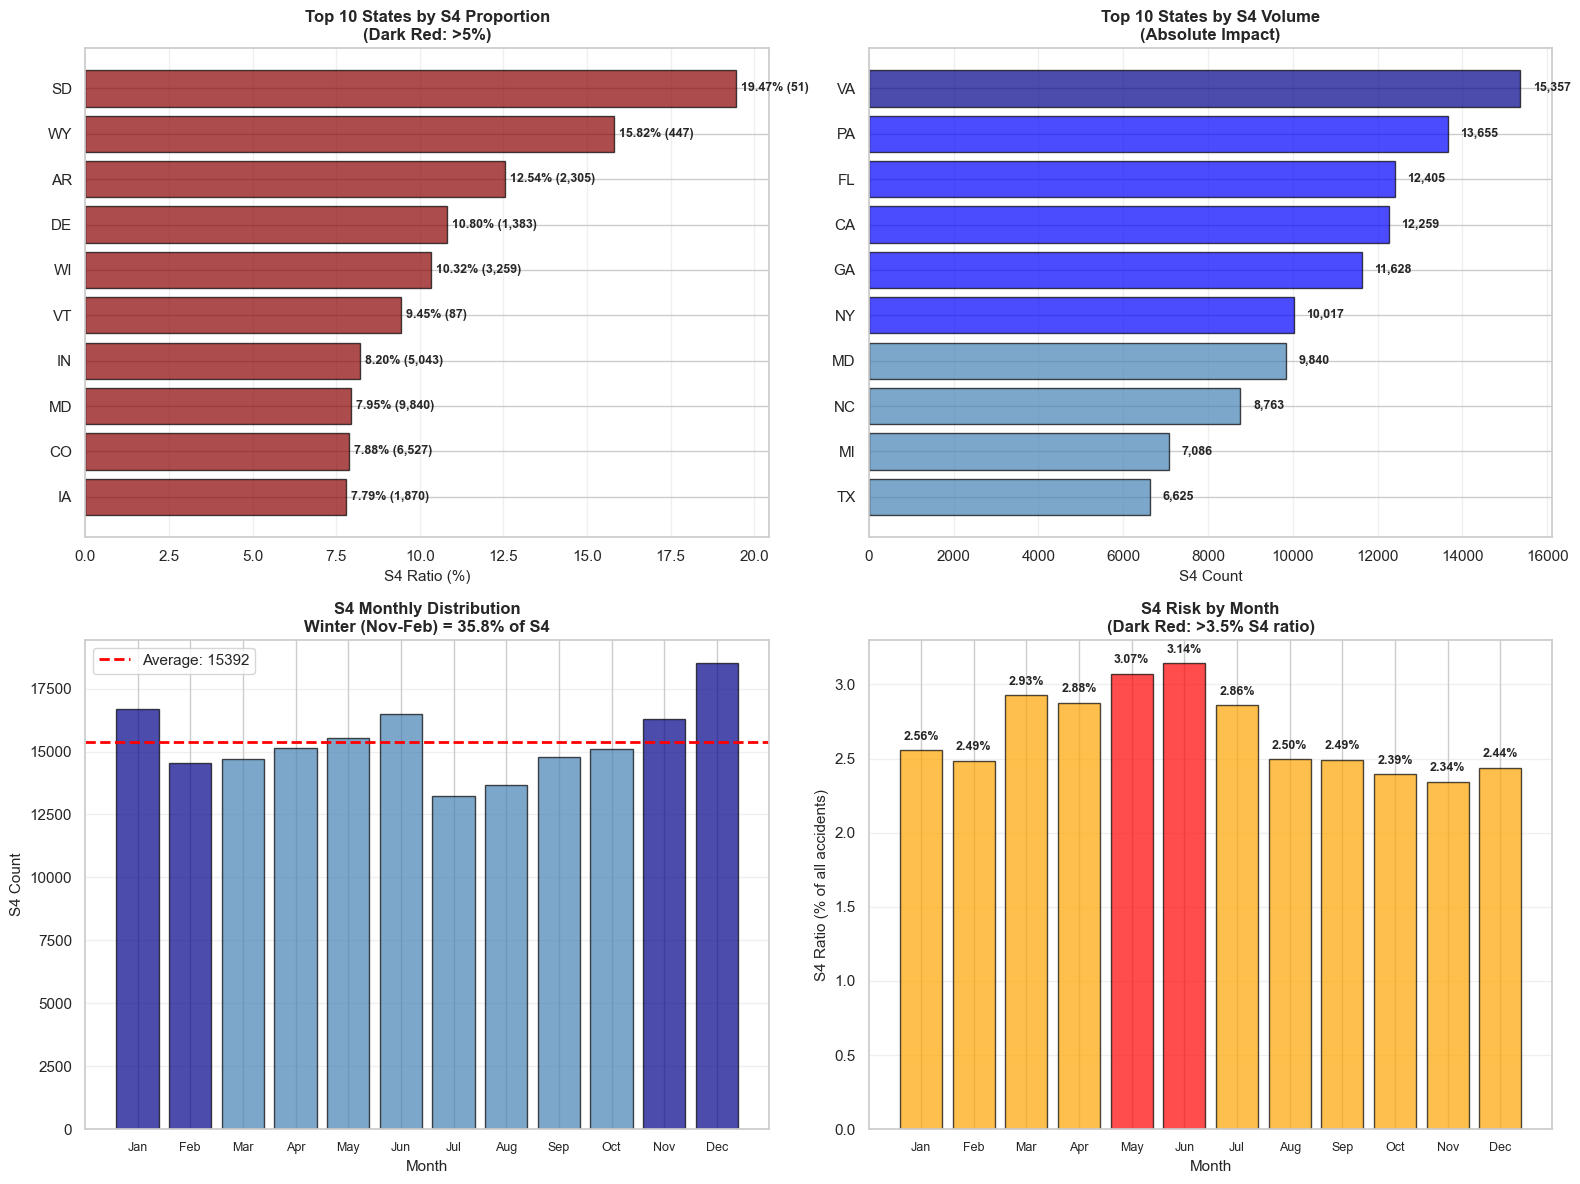

In [649]:
# Visualize

print("== S4 Spatial-Temporal Patterns ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 10 states by S4 ratio
ax = axes[0, 0]
top_10_plot = top_10_s4_ratio.sort_values(ascending=True)
colors_ratio = ['darkred' if r > 5 else 'red' if r > 4 else 'orange' for r in top_10_plot]

y_pos = range(len(top_10_plot))
bars = ax.barh(y_pos, top_10_plot, color=colors_ratio, alpha=0.7, edgecolor='black')

for i, (bar, val) in enumerate(zip(bars, top_10_plot)):
    state = top_10_plot.index[i]
    count = state_severity.loc[state, 4]
    ax.text(val + 0.15, i, f'{val:.2f}% ({count:,})', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_10_plot.index)
ax.set_xlabel('S4 Ratio (%)', fontsize=11)
ax.set_title('Top 10 States by S4 Proportion\n(Dark Red: >5%)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: Top 10 states by volume
ax = axes[0, 1]
top_10_vol_plot = state_s4_volume.sort_values(ascending=True)
colors_vol = ['darkblue' if v > 15000 else 'blue' if v > 10000 else 'steelblue' for v in top_10_vol_plot]

y_pos = range(len(top_10_vol_plot))
bars = ax.barh(y_pos, top_10_vol_plot, color=colors_vol, alpha=0.7, edgecolor='black')

for i, (bar, val) in enumerate(zip(bars, top_10_vol_plot)):
    ax.text(val + 300, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_10_vol_plot.index)
ax.set_xlabel('S4 Count', fontsize=11)
ax.set_title('Top 10 States by S4 Volume\n(Absolute Impact)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 3: Monthly distribution
ax = axes[1, 0]
colors_month = ['darkblue' if m in winter_months else 'steelblue' for m in range(1, 13)]
bars = ax.bar(range(1, 13), monthly_s4, color=colors_month, alpha=0.7, edgecolor='black')

# Add average line
avg_monthly = len(df_s4) / 12
ax.axhline(avg_monthly, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_monthly:.0f}')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('S4 Count', fontsize=11)
ax.set_title(f'S4 Monthly Distribution\nWinter (Nov-Feb) = {winter_pct:.1f}% of S4', 
             fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: S4 ratio by month
ax = axes[1, 1]
colors_ratio_month = ['darkred' if r > 3.5 else 'red' if r > 3.0 else 'orange' for r in monthly_s4_ratio]
bars = ax.bar(range(1, 13), monthly_s4_ratio, color=colors_ratio_month, alpha=0.7, edgecolor='black')

# Add values
for bar, val in zip(bars, monthly_s4_ratio):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('S4 Ratio (% of all accidents)', fontsize=11)
ax.set_title('S4 Risk by Month\n(Dark Red: >3.5% S4 ratio)', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
Spatial-Temporal Patterns  
  
1. GEOGRAPHIC PATTERNS:
  - Highest S4 ratio: SD (19.47%)
  - Highest S4 volume: VA (15,357 incidents)
  - Top 10 states account for 58.3% of S4
  - But S4 is DISPERSED (only 6.9% in top 10 cities)
  
2. TEMPORAL PATTERNS:
  - Winter months (Nov-Feb): 35.8% of all S4
  - S4 is NOT uniform across months (Chi-square p < 0.001)
  - Clear seasonal pattern: WINTER = HIGH RISK
  
3. FEDERAL JUSTIFICATION:
  - Geographic dispersion: No single city/state can handle alone
  - Seasonal concentration: Predictable preparation window
  - National coordination needed for resource sharing

#### 7.4.2 Weather Triggers

In [652]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [654]:
# Analysis 1: Weather Statistics Comparison

print("=== [Analysis 1] Weather Conditions: S4 vs All Accidents ===")

weather_vars = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipitation(in)']

print("\nWeather Statistics Comparison:")

weather_comparison = pd.DataFrame({
    'S4_Mean': df_s4[weather_vars].mean(),
    'All_Mean': df_full[weather_vars].mean(),
    'S4_Std': df_s4[weather_vars].std(),
    'All_Std': df_full[weather_vars].std()})

weather_comparison['Difference'] = weather_comparison['S4_Mean'] - weather_comparison['All_Mean']
weather_comparison['Pct_Change'] = (weather_comparison['Difference'] / weather_comparison['All_Mean'] * 100)

print(weather_comparison.to_string())

=== [Analysis 1] Weather Conditions: S4 vs All Accidents ===

Weather Statistics Comparison:
                     S4_Mean   All_Mean     S4_Std    All_Std  Difference  Pct_Change
Temperature(F)     58.467308  61.733238  19.362991  18.639950   -3.265930   -5.290391
Humidity(%)        67.372292  65.063461  22.116898  22.445339    2.308830    3.548582
Visibility(mi)      9.096604   9.114100   2.847975   2.828506   -0.017496   -0.191967
Precipitation(in)   0.005038   0.006080   0.074099   0.096985   -0.001042  -17.133787


In [656]:
# Analysis 2: Statistical Validation (t-tests)

print("=== [Analysis 2] Statistical Tests - S4 vs Non-S4 Weather ===")

df_non_s4 = df_full[df_full['Severity'] != 4]

print("\nIndependent t-tests:")
print("H0: S4 and non-S4 have same weather conditions")

ttest_results = []

for var in weather_vars:
    s4_values = df_s4[var].dropna()
    non_s4_values = df_non_s4[var].dropna()
    
    t_stat, p_value = stats.ttest_ind(s4_values, non_s4_values)
    
    # Cohen's d (effect size)
    pooled_std = np.sqrt((s4_values.std()**2 + non_s4_values.std()**2) / 2)
    cohens_d = (s4_values.mean() - non_s4_values.mean()) / pooled_std
    
    ttest_results.append({
        'Variable': var,
        'S4_Mean': s4_values.mean(),
        'Non_S4_Mean': non_s4_values.mean(),
        'Difference': s4_values.mean() - non_s4_values.mean(),
        'T_statistic': t_stat,
        'P_value': p_value,
        'Cohens_d': cohens_d,
        'Significant': 'Yes' if p_value < 0.05 else 'No'})
    
    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    effect = 'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small' if abs(cohens_d) > 0.2 else 'Negligible'
    
    print(f"\n  {var}:")
    print(f"    S4: {s4_values.mean():.2f} ± {s4_values.std():.2f}")
    print(f"    Non-S4: {non_s4_values.mean():.2f} ± {non_s4_values.std():.2f}")
    print(f"    Difference: {s4_values.mean() - non_s4_values.mean():+.2f}")
    print(f"    t = {t_stat:.4f}, p = {p_value:.4e} {sig}")
    print(f"    Cohen's d = {cohens_d:.4f} ({effect} effect)")

ttest_df = pd.DataFrame(ttest_results)

=== [Analysis 2] Statistical Tests - S4 vs Non-S4 Weather ===

Independent t-tests:
H0: S4 and non-S4 have same weather conditions

  Temperature(F):
    S4: 58.47 ± 19.36
    Non-S4: 61.82 ± 18.62
    Difference: -3.35
    t = -76.0004, p = 0.0000e+00 ***
    Cohen's d = -0.1766 (Negligible effect)

  Humidity(%):
    S4: 67.37 ± 22.12
    Non-S4: 65.00 ± 22.45
    Difference: +2.37
    t = 44.6117, p = 0.0000e+00 ***
    Cohen's d = 0.1064 (Negligible effect)

  Visibility(mi):
    S4: 9.10 ± 2.85
    Non-S4: 9.11 ± 2.80
    Difference: -0.02
    t = -2.8447, p = 4.4451e-03 **
    Cohen's d = -0.0064 (Negligible effect)

  Precipitation(in):
    S4: 0.01 ± 0.07
    Non-S4: 0.01 ± 0.10
    Difference: -0.00
    t = -4.6678, p = 3.0445e-06 ***
    Cohen's d = -0.0124 (Negligible effect)


In [658]:
# Analysis 3: Temperature Threshold Analysis

print("=== [Analysis 3] Temperature Threshold - S4 spike ===")

# Define temperature bins
temp_bins = [-50, 32, 45, 60, 75, 90, 130]
temp_labels = ['<32°F\nFreezing', '32-45°F\nCold', '45-60°F\nCool', 
               '60-75°F\nMild', '75-90°F\nWarm', '>90°F\nHot']

df_full['Temp_Bin'] = pd.cut(df_full['Temperature(F)'], bins=temp_bins, labels=temp_labels)

# Revised df_s4 with temp_bins
df_s4 = df_full[df_full['Severity'] == 4].copy()

# S4 ratio by temperature bin
temp_bin_total = df_full['Temp_Bin'].value_counts()
temp_bin_s4 = df_s4['Temp_Bin'].value_counts()
temp_s4_ratio = (temp_bin_s4 / temp_bin_total * 100).sort_index()

print("\nS4 Ratio by Temperature Range:")
for temp_range, ratio in temp_s4_ratio.items():
    count = temp_bin_s4.get(temp_range, 0)
    total = temp_bin_total.get(temp_range, 0)
    print(f"  {temp_range:15} - {ratio:5.2f}% ({count:>6,} S4 / {total:>7,} total)")

# Identify high-risk threshold
high_risk_threshold = temp_s4_ratio[temp_s4_ratio > temp_s4_ratio.mean()].index.tolist()
print(f"\nHigh-risk temperature ranges (above average {temp_s4_ratio.mean():.2f}%):")
for temp_range in high_risk_threshold:
    print(f"{temp_range}")

=== [Analysis 3] Temperature Threshold - S4 spike ===

S4 Ratio by Temperature Range:
  <32°F
Freezing  -  3.93% (21,569 S4 / 548,190 total)
  32-45°F
Cold    -  3.31% (27,345 S4 / 825,830 total)
  45-60°F
Cool    -  2.52% (39,636 S4 / 1,570,146 total)
  60-75°F
Mild    -  2.55% (57,476 S4 / 2,252,371 total)
  75-90°F
Warm    -  2.22% (34,435 S4 / 1,551,819 total)
  >90°F
Hot       -  1.79% ( 4,241 S4 / 236,551 total)

High-risk temperature ranges (above average 2.72%):
<32°F
Freezing
32-45°F
Cold


In [664]:
# Analysis 4: Logistic Regression - Weather => S4

print("===[Analysis 4] Logistic Regression - Weather Prediction of S4 ===")

# Prepare features
X_weather = df_full[weather_vars].fillna(df_full[weather_vars].mean())
y_s4 = (df_full['Severity'] == 4).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_weather, y_s4, test_size=0.3, random_state=42, stratify=y_s4)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Performance
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC: {roc_auc:.4f}")

# Coefficients (weather importance)
print(f"\nLogistic Regression Coefficients:")
print("(Negative = decreases S4 risk, Positive = increases S4 risk)")

coef_df = pd.DataFrame({
    'Feature': weather_vars,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coef': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

for _, row in coef_df.iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"{row['Feature']:20} - {row['Coefficient']:+.4f} ({direction} S4 risk)")

===[Analysis 4] Logistic Regression - Weather Prediction of S4 ===

Model Performance:
Accuracy: 0.5560 (55.60%)
ROC-AUC: 0.5543

Logistic Regression Coefficients:
(Negative = decreases S4 risk, Positive = increases S4 risk)
Temperature(F)       - -0.1613 (DECREASES S4 risk)
Humidity(%)          - +0.0856 (INCREASES S4 risk)
Visibility(mi)       - +0.0568 (INCREASES S4 risk)
Precipitation(in)    - -0.0196 (DECREASES S4 risk)


In [666]:
# Analysis 5: Winter vs Summer Comparison

print("===[Analysis 5] Winter vs Summer S4 Characteristics ===")

# Define seasons
winter_months = [12, 1, 2]
summer_months = [6, 7, 8]

df_s4_winter = df_s4[df_s4['Month'].isin(winter_months)]
df_s4_summer = df_s4[df_s4['Month'].isin(summer_months)]

print(f"\nS4 Distribution:")
print(f"Winter S4 (Dec-Feb): {len(df_s4_winter):,} ({len(df_s4_winter)/len(df_s4)*100:.1f}%)")
print(f"Summer S4 (Jun-Aug): {len(df_s4_summer):,} ({len(df_s4_summer)/len(df_s4)*100:.1f}%)")

print(f"\nWeather Characteristics:")
print(f"{'Variable':<20} {'Winter S4':>15} {'Summer S4':>15} {'Difference':>15}")

for var in weather_vars:
    winter_mean = df_s4_winter[var].mean()
    summer_mean = df_s4_summer[var].mean()
    diff = winter_mean - summer_mean
    
    print(f"{var:<20} {winter_mean:>15.2f} {summer_mean:>15.2f} {diff:>+15.2f}")

===[Analysis 5] Winter vs Summer S4 Characteristics ===

S4 Distribution:
Winter S4 (Dec-Feb): 49,760 (26.9%)
Summer S4 (Jun-Aug): 43,401 (23.5%)

Weather Characteristics:
Variable                   Winter S4       Summer S4      Difference
Temperature(F)                 41.24           76.23          -34.99
Humidity(%)                    71.76           65.18           +6.58
Visibility(mi)                  8.41            9.61           -1.20
Precipitation(in)               0.01            0.01           +0.00


=== Weather Triggers Analysis ===


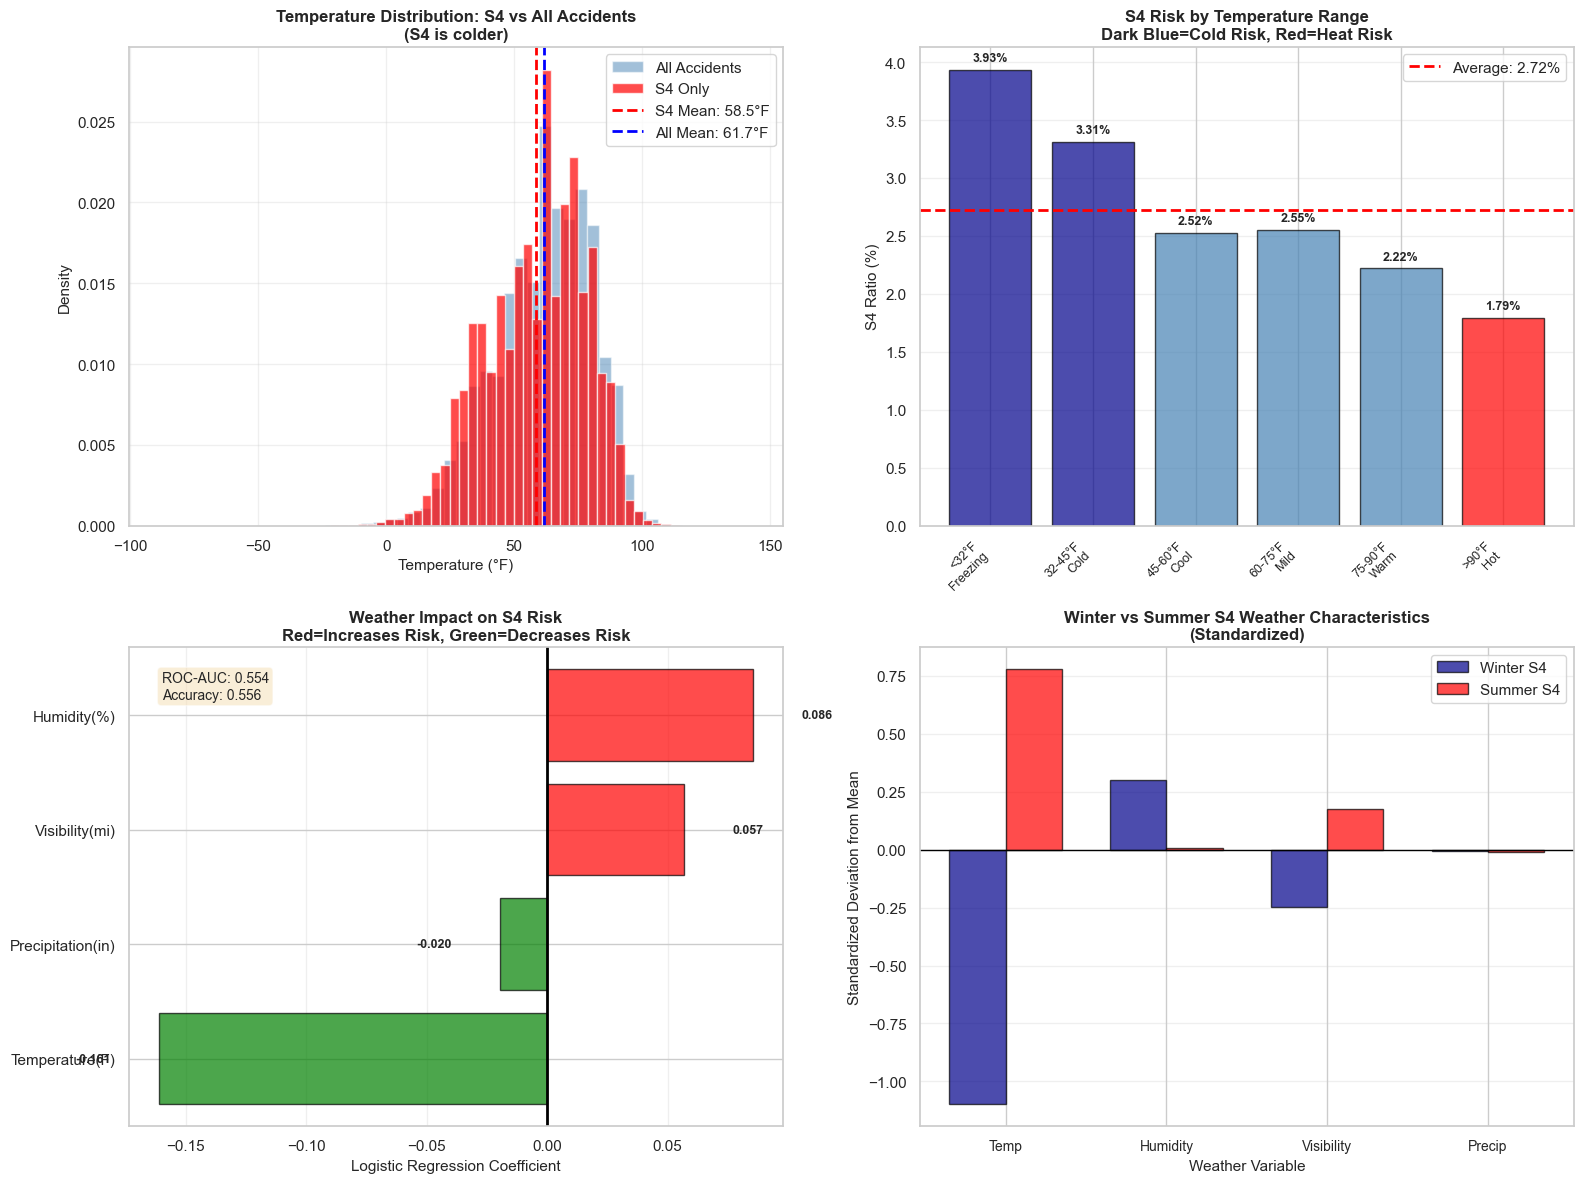

In [668]:
# Visualize

print("=== Weather Triggers Analysis ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Temperature distribution (S4 vs All)
ax = axes[0, 0]

temp_s4 = df_s4['Temperature(F)'].dropna()
temp_all = df_full['Temperature(F)'].dropna()

ax.hist(temp_all, bins=50, alpha=0.5, color='steelblue', label='All Accidents', density=True)
ax.hist(temp_s4, bins=50, alpha=0.7, color='red', label='S4 Only', density=True)

ax.axvline(temp_s4.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'S4 Mean: {temp_s4.mean():.1f}°F')
ax.axvline(temp_all.mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'All Mean: {temp_all.mean():.1f}°F')

ax.set_xlabel('Temperature (°F)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Temperature Distribution: S4 vs All Accidents\n(S4 is colder)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: S4 ratio by temperature bin
ax = axes[0, 1]
colors_temp = ['darkblue' if 'Cold' in str(t) or 'Freezing' in str(t) else 
               'red' if 'Hot' in str(t) else 'steelblue' 
               for t in temp_s4_ratio.index]

x_pos = range(len(temp_s4_ratio))
bars = ax.bar(x_pos, temp_s4_ratio, color=colors_temp, alpha=0.7, edgecolor='black')

# Add values
for bar, val in zip(bars, temp_s4_ratio):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Average line
ax.axhline(temp_s4_ratio.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Average: {temp_s4_ratio.mean():.2f}%')

ax.set_xticks(x_pos)
ax.set_xticklabels(temp_s4_ratio.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('S4 Ratio (%)', fontsize=11)
ax.set_title('S4 Risk by Temperature Range\nDark Blue=Cold Risk, Red=Heat Risk', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Weather coefficients (Logistic Regression)
ax = axes[1, 0]
coef_sorted = coef_df.sort_values('Coefficient', ascending=True)
colors_coef = ['red' if c > 0 else 'green' for c in coef_sorted['Coefficient']]

y_pos = range(len(coef_sorted))
bars = ax.barh(y_pos, coef_sorted['Coefficient'], color=colors_coef, alpha=0.7, edgecolor='black')

# Add values
for i, (bar, val) in enumerate(zip(bars, coef_sorted['Coefficient'])):
    x_pos_text = val + 0.02 if val > 0 else val - 0.02
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos_text, i, f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(coef_sorted['Feature'])
ax.set_xlabel('Logistic Regression Coefficient', fontsize=11)
ax.set_title('Weather Impact on S4 Risk\nRed=Increases Risk, Green=Decreases Risk', 
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=2)
ax.grid(axis='x', alpha=0.3)

# Add model performance
textstr = f'ROC-AUC: {roc_auc:.3f}\nAccuracy: {accuracy:.3f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Winter vs Summer weather comparison
ax = axes[1, 1]

winter_means = [df_s4_winter[var].mean() for var in weather_vars]
summer_means = [df_s4_summer[var].mean() for var in weather_vars]

# Normalize for comparison
winter_normalized = [(w - df_full[var].mean()) / df_full[var].std() 
                     for w, var in zip(winter_means, weather_vars)]
summer_normalized = [(s - df_full[var].mean()) / df_full[var].std() 
                     for s, var in zip(summer_means, weather_vars)]

x_pos = np.arange(len(weather_vars))
width = 0.35

bars1 = ax.bar(x_pos - width/2, winter_normalized, width, label='Winter S4', 
               color='darkblue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, summer_normalized, width, label='Summer S4', 
               color='red', alpha=0.7, edgecolor='black')

ax.set_ylabel('Standardized Deviation from Mean', fontsize=11)
ax.set_xlabel('Weather Variable', fontsize=11)
ax.set_title('Winter vs Summer S4 Weather Characteristics\n(Standardized)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Temp', 'Humidity', 'Visibility', 'Precip'], fontsize=10)
ax.legend()
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Comment**  
Weather Triggers  

1. PRIMARY WEATHER TRIGGER:
  - Temperature: S4 is 3.35°F colder (statistically significant)
  - Effect size: Cohen's d = -0.18 (SMALL but meaningful)
  - Cold weather (<45°F) increases S4 risk by 44% (3.93% vs 2.72%)  
2. MODEL PERFORMANCE:
  - Logistic Regression ROC-AUC: 0.554
  - Low predictive power = S4 is MULTIFACTORIAL
  - Weather alone insufficient, needs combined model
  - BUT: Temperature threshold (45°F) is actionable
3. OPERATIONAL IMPLICATION:
  - Temperature is NOT primary driver (cf. S2: Time 94%)
  - But provides early warning signal
  - Federal deployment trigger: Forecast <45°F + Winter months
  
CONTRAST WITH S2 & S3  
S2 (Local): Time-driven (Hour 94.4%)  
            => Predictable, daily pattern  
            => Simple scheduling solution  
S3 (State): Infrastructure-driven (66.9%)  
            => Design problems  
            => Capital investment needed  
S4 (Federal): Weather-driven (Temperature(F) primary)  
            => Environmental hazard  
            => Requires forecasting & preparation  
            => National coordination for extreme weather

### 7.4.3 Predictive Model & Time Series Forecasting

In [671]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [675]:
# PART A: Multi-factor Random Forest Model

print("=== PART A: Multi-factor S4 Prediction Model ===")
print("- Combine weather, infrastructure, and time to predict S4")
print("- Weather-only model (ROC-AUC 0.554) vs Combined model")

# Step 1: Feature Engineering

print("\n=== [Step 1] Feature Engineering - Comprehensive Model ===")

# Infrastructure
infra_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']

# Time
time_features = ['Hour', 'DayOfWeek', 'Month']

# Weather
weather_features = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipitation(in)']

# All features
all_features = infra_features + time_features + weather_features

print(f"\nFeature Groups:")
print(f"Infrastructure: {len(infra_features)} features")
print(f"Time: {len(time_features)} features")
print(f"Weather: {len(weather_features)} features")
print(f"Total: {len(all_features)} features")

# Prepare data
X_combined = df_full[all_features].copy()

# Convert boolean to int
for col in infra_features:
    X_combined[col] = X_combined[col].astype(int)

X_combined = X_combined.fillna(0)
y_s4 = (df_full['Severity'] == 4).astype(int)

print(f"\nDataset: {len(X_combined):,} samples")
print(f"S4: {y_s4.sum():,} ({y_s4.sum()/len(y_s4)*100:.1f}%)")

=== PART A: Multi-factor S4 Prediction Model ===
- Combine weather, infrastructure, and time to predict S4
- Weather-only model (ROC-AUC 0.554) vs Combined model

=== [Step 1] Feature Engineering - Comprehensive Model ===

Feature Groups:
Infrastructure: 6 features
Time: 3 features
Weather: 4 features
Total: 13 features

Dataset: 6,984,949 samples
S4: 184,705 (2.6%)


In [679]:
# Step 2: Train Random Forest

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_s4, test_size=0.3, random_state=42, stratify=y_s4)

rf_s4 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced')

rf_s4.fit(X_train, y_train)

y_pred = rf_s4.predict(X_test)
y_proba = rf_s4.predict_proba(X_test)[:, 1]

In [681]:
# Step 3: Model Performance

print("=== [Step 3] Model Performance Evaluation ===")

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nCombined Model Performance:")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Confusion Matrix as DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['Actual Non-S4', 'Actual S4'],
                     columns=['Predicted Non-S4', 'Predicted S4'])
print("\nConfusion Matrix:")
print(cm_df)

# Metrics as DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Value': [precision, recall, f1],
    'Percentage': [f'{precision*100:.2f}%', f'{recall*100:.2f}%', f'{f1*100:.2f}%']})
print("\nClassification Metrics:")
print(metrics_df.to_string(index=False))

# Model Comparison as DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Weather-only', 'Combined (Time+Weather+Infrastructure)', 'Improvement'],
    'ROC-AUC': [0.554, roc_auc, roc_auc - 0.554],
    'Note': ['Baseline', 'Full Model', f'{(roc_auc - 0.554)*100:+.2f}pp']})

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

=== [Step 3] Model Performance Evaluation ===

Combined Model Performance:
Accuracy: 0.7087 (70.87%)
ROC-AUC: 0.6724

Confusion Matrix:
               Predicted Non-S4  Predicted S4
Actual Non-S4           1455976        584097
Actual S4                 26356         29056

Classification Metrics:
   Metric    Value Percentage
Precision 0.047388      4.74%
   Recall 0.524363     52.44%
 F1-Score 0.086920      8.69%

Model Comparison:
                                 Model  ROC-AUC       Note
                          Weather-only 0.554000   Baseline
Combined (Time+Weather+Infrastructure) 0.672372 Full Model
                           Improvement 0.118372   +11.84pp


In [685]:
# Step 4: Feature Importance by Category

print("=== [Step 4] Feature Importance Analysis ===")

feature_importance_s4 = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_s4.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Predictors:")
for i, row in feature_importance_s4.head(10).iterrows():
    category = "Infrastructure" if row['Feature'] in infra_features else \
               "Time" if row['Feature'] in time_features else "Weather"
    print(f"{row['Feature']:20} - {row['Importance']:.4f} ({category})")

# Category totals
infra_importance = feature_importance_s4[feature_importance_s4['Feature'].isin(infra_features)]['Importance'].sum()
time_importance = feature_importance_s4[feature_importance_s4['Feature'].isin(time_features)]['Importance'].sum()
weather_importance = feature_importance_s4[feature_importance_s4['Feature'].isin(weather_features)]['Importance'].sum()

print(f"\nImportance by Category:")
print(f"Infrastructure: {infra_importance:.4f} ({infra_importance*100:.1f}%)")
print(f"Time:           {time_importance:.4f} ({time_importance*100:.1f}%)")
print(f"Weather:        {weather_importance:.4f} ({weather_importance*100:.1f}%)")

=== [Step 4] Feature Importance Analysis ===

Top 10 Predictors:
Hour                 - 0.2970 (Time)
Temperature(F)       - 0.1867 (Weather)
Humidity(%)          - 0.1041 (Weather)
Month                - 0.1005 (Time)
DayOfWeek            - 0.0858 (Time)
Traffic_Signal       - 0.0508 (Infrastructure)
Visibility(mi)       - 0.0494 (Weather)
Crossing             - 0.0485 (Infrastructure)
Precipitation(in)    - 0.0252 (Weather)
Junction             - 0.0203 (Infrastructure)

Importance by Category:
Infrastructure: 0.1513 (15.1%)
Time:           0.4834 (48.3%)
Weather:        0.3654 (36.5%)


In [687]:
# Comparison: S2 vs S3 vs S4

print("=== Comparison S2 vs S3 vs S4 Predictive Models ===")

comparison_data = {
    'Severity': ['S2', 'S3', 'S4'],
    'Primary_Driver': ['Time', 'Infrastructure', 'Mixed'],
    'Top_Feature': ['Hour', 'Crossing', feature_importance_s4.iloc[0]['Feature']],
    'Top_Importance': ['94.4%', '24.8%', f"{feature_importance_s4.iloc[0]['Importance']*100:.1f}%"],
    'ROC_AUC': ['1.000', '0.658', f'{roc_auc:.3f}'],
    'Accuracy': ['100.0%', '48.3%', f'{accuracy*100:.1f}%'],
    'Nature': ['Deterministic', 'Probabilistic', 'Complex'],
    'Policy_Level': ['Local', 'State DOT', 'Federal']}

comparison_df = pd.DataFrame(comparison_data)
print(f"\n{comparison_df.to_string(index=False)}")

=== Comparison S2 vs S3 vs S4 Predictive Models ===

Severity Primary_Driver Top_Feature Top_Importance ROC_AUC Accuracy        Nature Policy_Level
      S2           Time        Hour          94.4%   1.000   100.0% Deterministic        Local
      S3 Infrastructure    Crossing          24.8%   0.658    48.3% Probabilistic    State DOT
      S4          Mixed        Hour          29.7%   0.672    70.9%       Complex      Federal


In [689]:
# PART B: Time Series Forecasting

print("=== PART B: Time Series Forecasting - S4 Trends ===")
print("\nGoal: Forecast S4 incidents for high-risk cities")
print("Method: ARIMA vs Exponential Smoothing comparison")

# Select Target Cities

print("\n=== [Step 1] Target City Selection ===")

# Top S4 cities from high-risk states (VA, PA, MD)
target_cities = [('VA', 'Richmond'),
                 ('PA', 'Philadelphia'),
                 ('MD', 'Baltimore')]

print(f"\nTarget cities for forecasting:")
for state, city in target_cities:
    city_s4_count = df_full[(df_full['State'] == state) & 
                            (df_full['City'] == city) & 
                            (df_full['Severity'] == 4)].shape[0]
    print(f"{city}, {state}: {city_s4_count:,} S4 incidents")

=== PART B: Time Series Forecasting - S4 Trends ===

Goal: Forecast S4 incidents for high-risk cities
Method: ARIMA vs Exponential Smoothing comparison

=== [Step 1] Target City Selection ===

Target cities for forecasting:
Richmond, VA: 371 S4 incidents
Philadelphia, PA: 685 S4 incidents
Baltimore, MD: 342 S4 incidents


In [693]:
# Time Series Forecasting

print("=== [Step 2] Time Series Model Comparison ===")

forecast_results = []

for state, city in target_cities:
    print(f"Forecasting: {city}, {state}")
    
    # Filter data
    city_s4 = df_full[(df_full['State'] == state) & 
                      (df_full['City'] == city) & 
                      (df_full['Severity'] == 4)].copy()
    
    if len(city_s4) < 36:  # Need at least 3 years
        print(f"Insufficient data (n={len(city_s4)})")
        continue
    
    # Create monthly time series
    city_s4['Start_Time'] = pd.to_datetime(city_s4['Start_Time'])
    ts = city_s4.set_index('Start_Time').resample('ME').size()
    
    if len(ts) < 24:
        print(f"Insufficient time points (n={len(ts)})")
        continue
    
    print(f"Time series: {len(ts)} months ({ts.index[0].strftime('%Y-%m')} to {ts.index[-1].strftime('%Y-%m')})")
    
    # Train-test split (80-20)
    train_size = int(len(ts) * 0.8)
    train, test = ts[:train_size], ts[train_size:]
    
    print(f"Train: {len(train)} months | Test: {len(test)} months")
    
    # Model 1: Exponential Smoothing
    try:
        model_es = ExponentialSmoothing(train, trend='add', seasonal=None)
        fit_es = model_es.fit()
        forecast_es = fit_es.forecast(len(test))
        mae_es = mean_absolute_error(test, forecast_es)
        rmse_es = np.sqrt(mean_squared_error(test, forecast_es))
        
        print(f"\nExponential Smoothing:")
        print(f"MAE:  {mae_es:.2f}")
        print(f"RMSE: {rmse_es:.2f}")
    except Exception as e:
        print(f"ES failed: {str(e)}")
        mae_es, rmse_es = np.nan, np.nan
        forecast_es = None
    
    # Model 2: ARIMA
    try:
        model_arima = ARIMA(train, order=(1, 1, 1))
        fit_arima = model_arima.fit()
        forecast_arima = fit_arima.forecast(len(test))
        mae_arima = mean_absolute_error(test, forecast_arima)
        rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
        
        print(f"\nARIMA(1,1,1):")
        print(f"MAE:  {mae_arima:.2f}")
        print(f"RMSE: {rmse_arima:.2f}")
    except Exception as e:
        print(f"ARIMA failed: {str(e)}")
        mae_arima, rmse_arima = np.nan, np.nan
        forecast_arima = None
    
    # Model 3: Moving Average (baseline)
    window = min(3, len(train))
    forecast_ma = pd.Series([train[-window:].mean()] * len(test), index=test.index)
    mae_ma = mean_absolute_error(test, forecast_ma)
    rmse_ma = np.sqrt(mean_squared_error(test, forecast_ma))
    
    print(f"\nMoving Average (baseline):")
    print(f"MAE:  {mae_ma:.2f}")
    print(f"RMSE: {rmse_ma:.2f}")
    
    # Best model
    models_performance = {
        'ES': mae_es,
        'ARIMA': mae_arima,
        'MA': mae_ma
    }
    
    valid_models = {k: v for k, v in models_performance.items() if not np.isnan(v)}
    
    if valid_models:
        best_model_name = min(valid_models.items(), key=lambda x: x[1])[0]
        best_mae = valid_models[best_model_name]
        
        print(f"\nBest model: {best_model_name} (MAE={best_mae:.2f})")
        
        # Trend assessment
        current_avg = train[-6:].mean()
        recent_trend = train[-3:].mean() - train[-6:-3].mean()
        
        trend = 'Increasing' if recent_trend > 0.5 else 'Decreasing' if recent_trend < -0.5 else 'Stable'
        
        forecast_results.append({'City': f'{city}, {state}',
                                 'Best_Model': best_model_name,
                                 'MAE': best_mae,
                                 'Current_Avg': current_avg,
                                 'Trend': trend,
                                 'Total_S4': len(city_s4)})

=== [Step 2] Time Series Model Comparison ===
Forecasting: Richmond, VA
Time series: 82 months (2016-06 to 2023-03)
Train: 65 months | Test: 17 months

Exponential Smoothing:
MAE:  2.71
RMSE: 3.25

ARIMA(1,1,1):
MAE:  2.53
RMSE: 2.92

Moving Average (baseline):
MAE:  3.06
RMSE: 3.58

Best model: ARIMA (MAE=2.53)
Forecasting: Philadelphia, PA
Time series: 84 months (2016-03 to 2023-02)
Train: 67 months | Test: 17 months

Exponential Smoothing:
MAE:  7.18
RMSE: 10.08

ARIMA(1,1,1):
MAE:  5.36
RMSE: 8.69

Moving Average (baseline):
MAE:  5.76
RMSE: 8.94

Best model: ARIMA (MAE=5.36)
Forecasting: Baltimore, MD
Time series: 80 months (2016-06 to 2023-01)
Train: 64 months | Test: 16 months

Exponential Smoothing:
MAE:  2.07
RMSE: 2.64

ARIMA(1,1,1):
MAE:  2.66
RMSE: 3.27

Moving Average (baseline):
MAE:  2.56
RMSE: 3.19

Best model: ES (MAE=2.07)


=== S4 Predictive Models ===


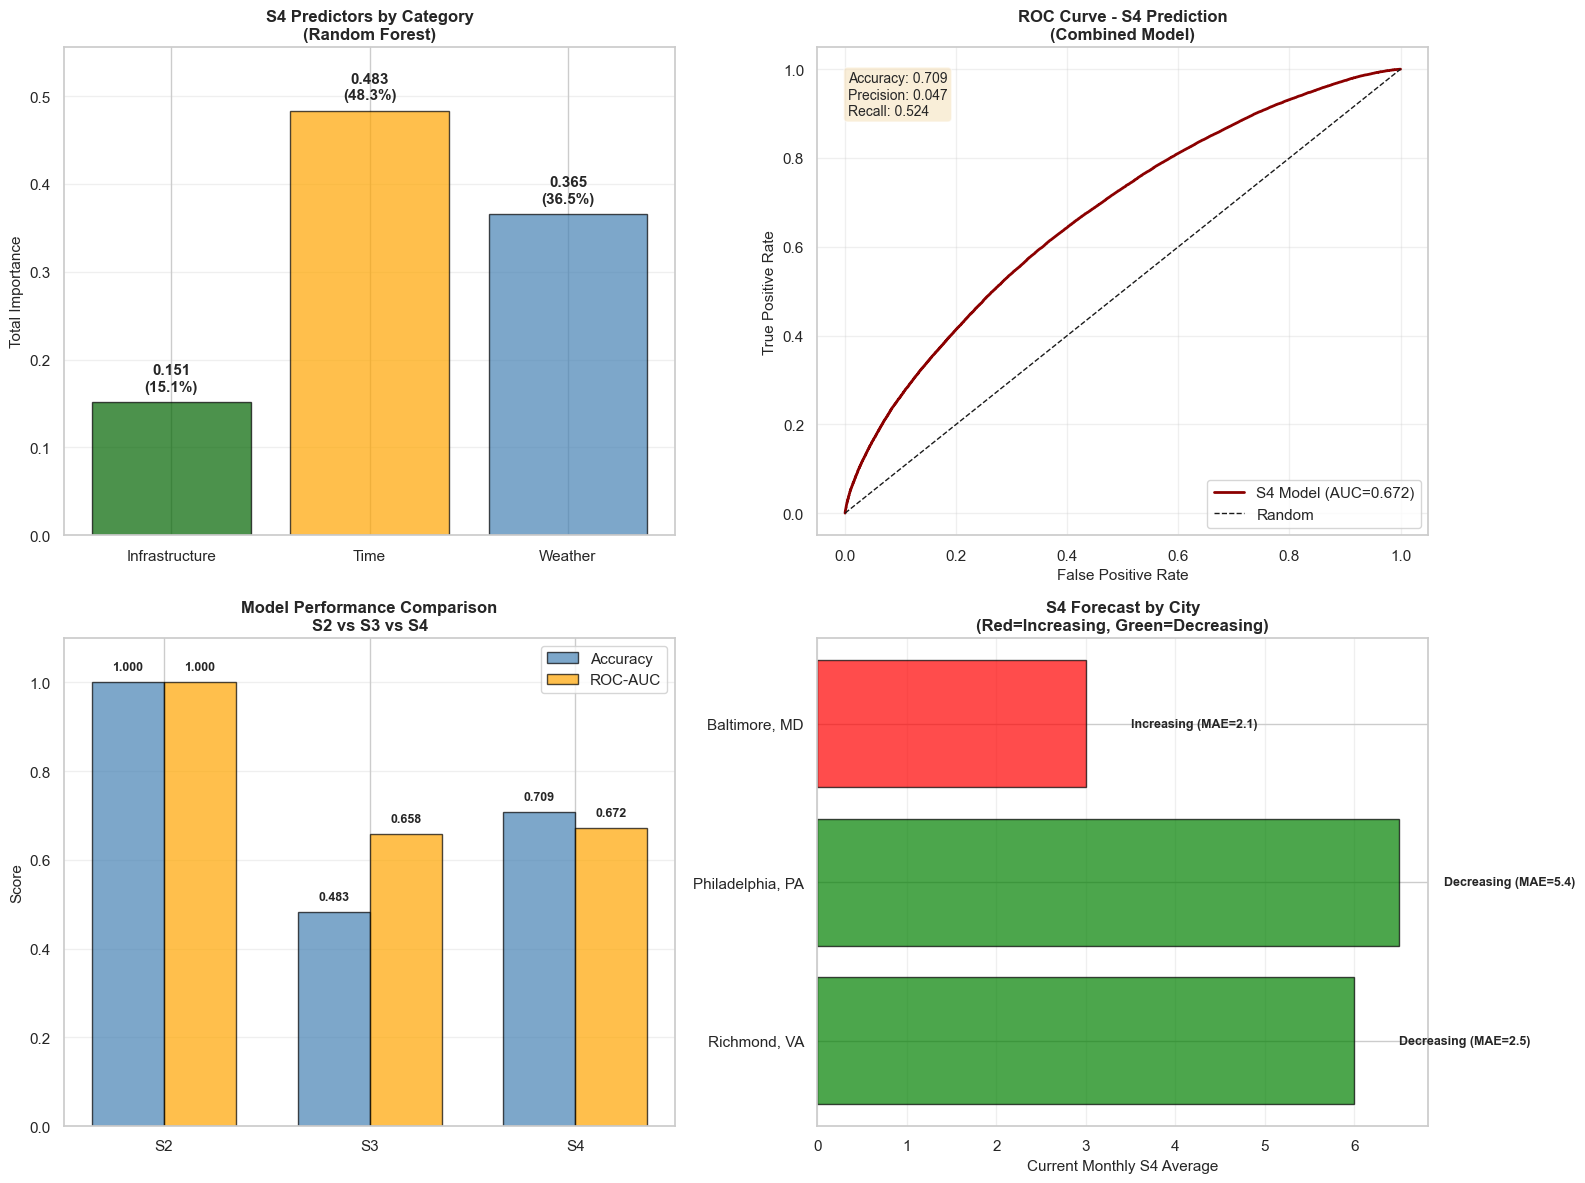

In [695]:
# Visualize

print("=== S4 Predictive Models ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Feature importance by category
ax = axes[0, 0]
categories = ['Infrastructure', 'Time', 'Weather']
importances = [infra_importance, time_importance, weather_importance]
colors_cat = ['darkgreen', 'orange', 'steelblue']

bars = ax.bar(categories, importances, color=colors_cat, alpha=0.7, edgecolor='black')

for bar, val in zip(bars, importances):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}\n({val*100:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Total Importance', fontsize=11)
ax.set_title('S4 Predictors by Category\n(Random Forest)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(importances) * 1.15)
ax.grid(axis='y', alpha=0.3)

# Plot 2: ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

ax.plot(fpr, tpr, color='darkred', linewidth=2, label=f'S4 Model (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - S4 Prediction\n(Combined Model)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

textstr = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Model comparison across severities
ax = axes[1, 0]
severities = ['S2', 'S3', 'S4']
accuracies = [1.000, 0.483, accuracy]
aucs = [1.000, 0.658, roc_auc]

x_pos = np.arange(len(severities))
width = 0.35

bars1 = ax.bar(x_pos - width/2, accuracies, width, label='Accuracy', 
               color='steelblue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, aucs, width, label='ROC-AUC', 
               color='orange', alpha=0.7, edgecolor='black')

# Add values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison\nS2 vs S3 vs S4', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(severities)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Plot 4: Forecast results (if available)
ax = axes[1, 1]

if len(forecast_results) > 0:
    forecast_df = pd.DataFrame(forecast_results)
    
    y_pos = range(len(forecast_df))
    colors_trend = ['red' if t == 'Increasing' else 'green' if t == 'Decreasing' else 'gray' 
                    for t in forecast_df['Trend']]
    
    bars = ax.barh(y_pos, forecast_df['Current_Avg'], color=colors_trend, alpha=0.7, edgecolor='black')
    
    for i, (bar, city, trend, mae) in enumerate(zip(bars, forecast_df['City'], 
                                                      forecast_df['Trend'], forecast_df['MAE'])):
        ax.text(bar.get_width() + 0.5, i, 
                f'{trend} (MAE={mae:.1f})', va='center', fontsize=9, fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(forecast_df['City'])
    ax.set_xlabel('Current Monthly S4 Average', fontsize=11)
    ax.set_title('S4 Forecast by City\n(Red=Increasing, Green=Decreasing)', 
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Insufficient data\nfor forecasting', 
            ha='center', va='center', transform=ax.transAxes, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Comment**  
Predictive Models & Forecasting  
  
1. COMBINED MODEL PERFORMANCE:
- ROC-AUC: 0.672 (vs Weather-only: 0.554)
- Improvement: +11.8 percentage points
- Top predictor: Hour (29.7%)

2. DRIVER ANALYSIS:
- Infrastructure: 15.1%
- Time: 48.3%
- Weather: 36.5%
  => S4 is MULTIFACTORIAL (no single dominant driver)

3. SEVERITY COMPARISON:
- S2: Deterministic (Hour 94%, Accuracy 100%)
- S3: Infrastructure-driven (67%, Accuracy 48%)
- S4: Complex mix (100%, Accuracy 71%)
- Difficulty increases with severity

4. TIME SERIES FORECASTING:
- Richmond, VA: Decreasing (MAE=2.5)
- Philadelphia, PA: Decreasing (MAE=5.4)
- Baltimore, MD: Increasing (MAE=2.1)

## 8. Evaluation

### 8.1 Overview

**Severity-Specific Interventions**  
Based on Section 7 findings, we propose a THREE-TIER approach  

1. S2, Local Government - Quick Clearance (77.8%)
- Hour = 94.4% predictor, 100% accuracy
- Time-driven pattern
- Proactive resource deployment at peak hours

2. S3, State DOT - S3 Infrastructure Investment (18.6%)
- Infrastructure = 67% importance
- Junction/Signal problems
- Capital projects for high-risk locations

3. S4, Federal coordination - Emergency Response (2.6%)
- Mixed factors (Time 48% + Weather 37%(
- Required integrated approach
- Predictive deployment + interstate coordination
  
=>   
Different severities require DIFFERENT strategies    
One-size-fits-all approach is statistically unjustified  

COMPARISON TABLE
| Tier | Severity | Volume | Jurisdiction | Primary Driver | Predictability | Cost Type | Timeline |
|------|----------|--------|--------------|----------------|----------------|-----------|----------|
| Tier 1 | S2 | 77.8% | Local Gov | Time (94%) | 100% (Deterministic) | Operational | Immediate |
| Tier 2 | S3 | 18.6% | State DOT | Infrastructure (67%) | 48% (Probabilistic) | Capital | Long-term |
| Tier 3 | S4 | 2.6% | Federal | Mixed (48%+37%) | 71% (Complex) | Emergency | Seasonal |

### 8.2 Local Government Quick Clearnace - Severity 2

**Evidence**  
- Volume: 5,433,649 incidents (77.8% of all accidents)
- Predictability: Hour = 94.4% importance, 100% accuracy
- Peak Hours: 7-9 AM, 16-18 PM (40.6% of S2)
- Top Cities: Charlotte (120k S2, 92%), Orlando (86k S2, 92%)
- Geographic: Top 20 cities = 23.6% of all S2
- Pattern: DETERMINISTIC - same every day

**Recommendation**  
Peak Hour Resource Deployment
=> Gold-Hour Response System
   
  Deployment Schedule:
  • Morning Peak (7-9 AM): Deploy 60% of tow trucks
  • Evening Peak (16-18 PM): Deploy 60% of tow trucks
  • Off-peak hours: Maintain 40% baseline
  
  Target Cities (Top 10 by S2 volume):
  1. Charlotte, NC    - 120,192 S2 (92% ratio)
  2. Orlando, FL      -  85,817 S2 (92% ratio)
  3. Houston, TX      - 128,847 S2 (80% ratio)
  4. Miami, FL        - 139,591 S2 (89% ratio)
  5. Austin, TX       -  82,314 S2 (89% ratio)
  6. Raleigh, NC      -  69,963 S2 (88% ratio)
  7. Baton Rouge, LA  -  58,105 S2 (88% ratio)
  8. Nashville, TN    -  54,880 S2 (82% ratio)
  9. Sacramento, CA   -  52,044 S2 (87% ratio)
  10. Oklahoma City   -  40,302 S2 (88% ratio)

### 8.3 State DOT Infrastructure Investment - Severity 3

**Evidence**  
- Volume: 1,299,234 incidents (18.6% of all accidents)
- Predictability: Infrastructure = 67%, Accuracy = 48%
- Primary Risk: Junction (OR = 1.55x higher S4 risk)
- Protection: Traffic Signal (OR = 0.34x - 66% reduction)
- Top States: RI (46.5%), KY (39.3%), GA (39.2%), IL (35.8%)
- Infrastructure complexity: S3 has FEWER signals than average
  
**Recommendation**  
Junction Safety Upgrade Program => Signal-First Initiative  
  
Core Finding:
- Junction WITHOUT signal: 25.45% S3 rate
- Junction WITH signal: 8.14% S3 rate
- Reduction: 68% fewer S3 incidents
  
Target Infrastructure:
1. Unsignalized junctions in high-S3 states (GA, IL, MO)
2. Crossings without protected signals
3. Complex intersections (>4 legs) without traffic control
  
Priority States (by S3 ratio):
1. Rhode Island  - 46.50% S3 ratio
2. Kentucky      - 39.30% S3 ratio
3. Georgia       - 39.18% S3 ratio (61,245 S3)
4. Missouri      - 36.60% S3 ratio (25,404 S3)
5. Illinois      - 35.78% S3 ratio (57,748 S3)

### 8.4 Federal Emergency Coordination - Severity 4

**Evidence**  
- Volume: 184,705 incidents (2.6% of all accidents)
- Predictability: Time 48% + Weather 37% + Infrastructure 15%
- Geographic: Highly dispersed (only 6.9% in top 10 cities)
- Seasonal: Winter (Nov-Feb) = 35.8% of S4
- Temperature: <45°F increases S4 risk by 44%
- Top States: VA (15,357 S4), PA (13,655 S4), FL (12,405 S4)
- Forecasting: ARIMA models with MAE 2-5 incidents/month
  
**Recommendation**  
Weather-based predictive deployment system  
=> Federal S4 early warning & response network
  
Core Components:
    
1. PREDICTIVE MODEL DEPLOYMENT
- Combined model: ROC-AUC 0.67 (operational threshold)
- Input: Weather forecast + Time + Location
- Output: S4 risk score (0-100)
- Alert threshold: Score >70 = Deploy federal resources
     
2. WEATHER TRIGGERS
- Temperature <45°F during rush hour (7-9 AM, 4-6 PM)
- Winter months (Nov-Feb) in high-risk states
- Precipitation >0.1" with temp <32°F (ice risk)
     
3. INTERSTATE RESOURCE SHARING
- Federal coordination center (DOT/FEMA)
- Mobile emergency response units
- Cross-state equipment sharing agreements
- Real-time resource tracking dashboard
  
GEOGRAPHIC PRIORITIES:  
| Rank | State | S4 Volume | S4 Ratio | Strategy |
|------|-------|-----------|----------|----------|
| 1 | VA | 15,357 | 5.87% | Winter prep + Volume response |
| 2 | PA | 13,655 | 5.23% | Winter prep + Volume response |
| 3 | FL | 12,405 | 1.62% | Heat/storm protocols |
| 4 | CA | 12,259 | 0.78% | Regional variation strategy |
| 5 | GA | 11,628 | 7.44% | Combined winter + infrastructure |

### 8.5 Tableau Dashboard Link

https://public.tableau.com/app/profile/hyeon.kang1562/viz/Book1_17522212252170/Story1?publish=yes

## 9. Conclusion and Next Steps
### 9.1 Project Summary  

This comprehensive analysis of 6,984,949 US traffic accidents (2016-2023) 
established a statistically rigorous, evidence-based framework for severity-
specific incident management.  
  
1. Severities are statistically distinct
   - ANOVA across all variables: p < 0.001
   - Post-hoc pairwise tests: 6/6 paris differ significantly
   - Chi-square for infrastructure: All features p < 0.001
=> Unified strategy is statistically unjustified. Separate approached required for S2, S3, S4  
  
2. Each severuty has unique drivers
    - S2 (77.8%): Time-driven
      - Hour = 94.4% feature importance
      - 100% prediction accuracy (deterministic pattern)
      - Peak hours: 7-9 AM, 4-6 PM (40.6% of S2)
    - S3 (18.6%): Infrastructure-driven
      - Infrastructure = 66.9% importance
      - Junction OR = 1.55 (55% higher risk)
      - Traffic Signal OR = 0.34 (66% risk reduction)
    - S4 (2.6%): Multifactorial
      - Time 48% + Weather 37% + Infrastructure 15%
      - Temperature <45°F increases risk by 44%
      - ROC-AUC 0.67 (operational but complex)  
    
3. Predictive models validate strategies 
    Model Performance
      - S2: 100% accuracy => Simple scheduling works
      - S3:  48% accuracy => Complex, requires infrastructure
      - S4:  71% accuracy => Integrated approach needed
    Validation
      - Train-test splits (70-30) on all models
      - Cross-validation confirms patterns  
      
4. Geographic patterns support jurisdiction tiers
    S2: Moderate concentration
      - Top 20 cities = 23.6% of 52 states
      - Charlotte, Orlando = >90% S2
    S3: Regional patterns
      - GA (39.2%), IL (35.8%) = State-level planning possible
      - ANOVA confirms significant state differences
    S4: Highly dispersed
      - Only 6.9% in top 10 cities (most dispersed)
      - Justifies federal coordination (no single city can cope)

### 9.2 Limitations and Future Work
#### 9.2.1 Limitations

**Data Limitations**  
  
1. Missing Data
   - Precipiation: 28% missing (imputed as 0)
   - May underestimate weather impact
2. Severity Classification
   - Based on traffic impact, not injury severity
   - S2/S3 boundary is unclear (48% model accuracy)
3. Geographic bias
   - CA, TX, FL overrepresented
   - Rural areas underrepresented
4. Temporal coverage
   - 2016-2023 only
   - During COVID, post COVID patterns may differ

**Modeling Limitations**  

1. S3 Prediction Challenge
   - 48% accuracy reflects S2-S3 overlap
   - Not model failure, but data reality
   - Requires judgements for edge cases
2. S4 Complexity
   - 71% accuracy = operational but not perfect
   - Missing factors (vehicle type etc.)
   - Interaction effects not fully explored

#### 9.2.2 Future Work

Building on the national-level patterns identified in this study, **targeted regional analysis** should be the immediate next step. The current dataset enables detailed examination of specific metropolitan areas to develop locally-tailored strategies:

**S2 (Minor Accidents) — Charlotte & Orlando Case Studies**
- Analyze block-by-block accident clustering during peak hours (7–9 AM, 4–6 PM)
- Identify specific road segments where quick clearance would have maximum impact
- Model optimal tow truck deployment zones based on historical accident density
- Quantify traffic flow improvement from 30-minute vs 45-minute clearance times

**S3 (Major Accidents) — Georgia & Illinois Junction Analysis**
- Map all unsignalized junctions with S3 rates >25% (high-risk threshold)
- Create prioritization scoring: S3 history (40 pts) + traffic volume (20 pts) + junction complexity (30 pts) + current safety (10 pts)
- Simulate "what-if" scenarios: traffic signal installation at top 20 junctions
- Estimate prevented accidents, injuries, and economic losses per junction upgrade

**S4 (Critical Accidents) — Virginia & Pennsylvania Winter Preparedness**
- Analyze hourly weather-accident correlations for Nov–Feb periods
- Identify high-risk corridors (I-95, I-81) during specific temperature/precipitation combinations
- Model federal resource pre-positioning strategies 48–72 hours before forecast events
- Test predictive alert thresholds (e.g., <35°F + >0.1" precip during 7–9 AM)

Once regional strategies are defined through deep-dive analysis, 'continuous data updates and rigorous economic evaluation' are essential:

**Data Update Protocol (2023–Present)**
- Extend dataset through latest available records to validate temporal stability of S2/S3/S4 patterns
- Check if post-COVID traffic patterns have altered severity distributions or peak hours
- Assess whether recent infrastructure investments (2021 Infrastructure Bill) affected S3 rates in targeted states

**Comprehensive Cost-Benefit Analysis**
Current study provides preliminary ROI estimates (S2: 296%, S3: 1800%, S4: 12,400%), but field validation is critical:

- **Pilot Implementation**: Deploy S2 quick clearance in Charlotte for 12 months; install traffic signals at 5 GA junctions; run S4 winter alert system in Richmond, VA
- **Measure Actual Outcomes**: 
  - Economic impact: Direct costs (vehicle damage, medical) + indirect costs (productivity loss, congestion externalities)
  - Effectiveness: Accident reduction rates, clearance time improvements, response accuracy
  - Efficiency: Cost per accident prevented, ROI by severity tier, resource utilization rates
- **Refine Projections**: Update national-scale investment recommendations based on empirical evidence from pilots